In [3]:
# Real Data
import os

# Change to the parent directory
os.chdir('../..')

# Verify the path using getcwd()
cwd = os.getcwd()
print("Current working directory:", cwd)


Current working directory: c:\Users\onyer\OneDrive\Desktop\Research work


CWD: c:\Users\onyer\OneDrive\Desktop\Research work\1. Projects\Battery_Analysis1
Columns: ['flags', 'Ns', 'time/s', 'control/mA', 'Ewe/V', 'I/mA', 'dQ/C', '(Q-Qo)/C', 'half cycle', 'Q charge/discharge/mA.h', 'I Range']
               I/mA     Ewe/V
time/s                       
0.000000   0.009051  0.407403
10.000000  0.010008  0.729420
19.999999  0.010006  0.746633
29.999999  0.010010  0.757071
39.999999  0.009996  0.764113


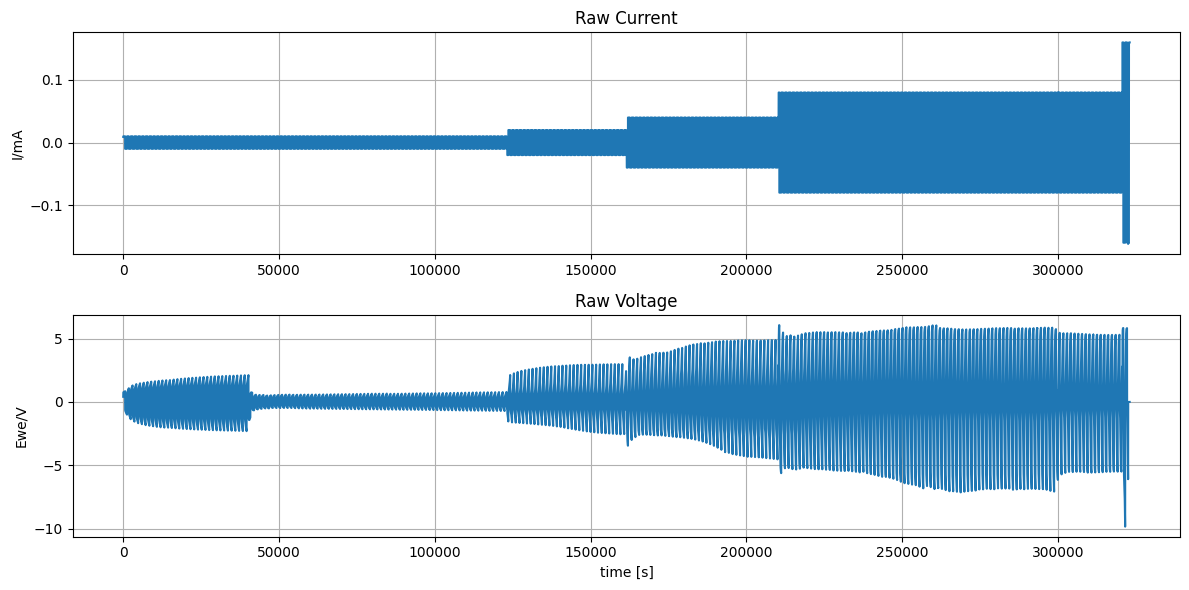

Found 267 discharge segments
Selected cycle index: 0  length: 61


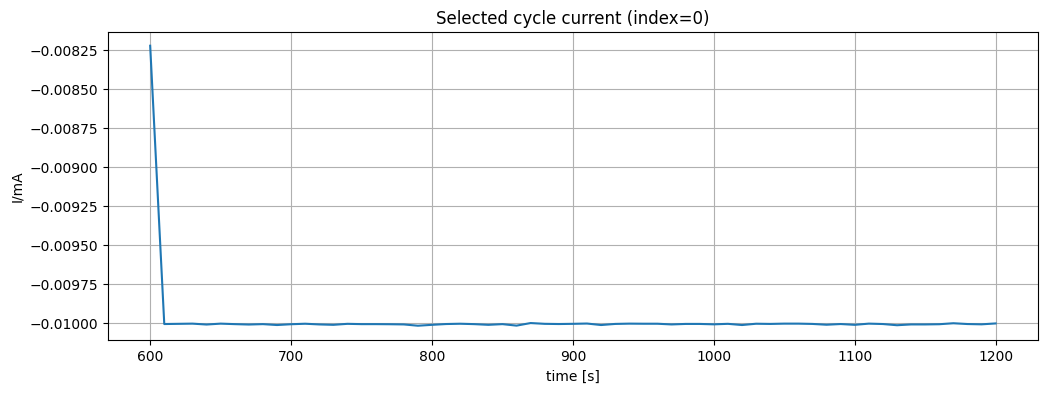

[UNIT CHECK] If column is actually A:
  range [A]: -0.01001603715121746 -0.008221372030675411  median|I|: 0.010005226358771324
[UNIT CHECK] If column is actually mA:
  range [A]: -1.0016037151217461e-05 -8.22137203067541e-06  median|I|: 1.0005226358771325e-05
auto units: ambiguous, using A (median|I|=0.0100052). If this is wrong, set FORCE_UNITS.
Discharge-only kept 61/61 points
Prepared shapes: (61,) (61, 1) (61, 1)
I range [A]: -0.01001603715121746 -0.008221372030675411  median|I| [A]: 0.010005226358771324
V range [V]: -1.0013251304626465 0.05881097540259361


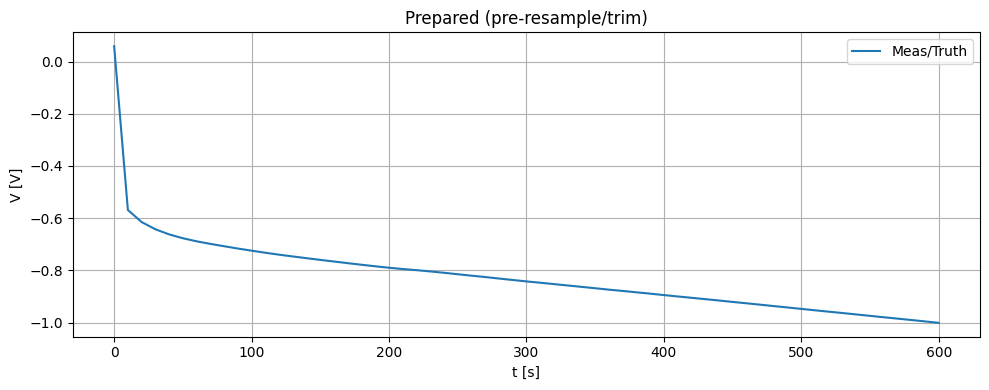

Resampled: dt_med = 9.999999747378752 len = 61


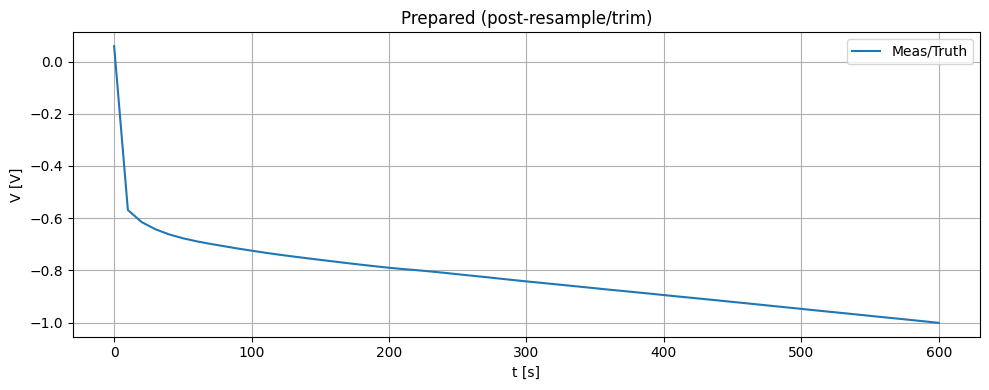

[PROXY] xp range: 0.6 0.6000523944223554  span: 5.239442235538405e-05
[PROXY] xn range: 0.5999476055778802 0.6  span: 5.2394422119794726e-05

[WARN] Proxies barely move -> model will look stiff.
Fix is almost always CURRENT UNITS or cycle selection.

Init thetaZ0: [ -200.54512339    41.78937619   -33.70410254   341.89571207
  3437.66867689 -2065.74395804   143.2076147 ]
Init R0: 1e-12
Pre-fit: max|err|=1.71209, rmse=1.54085, R2%=-9927.315, BFR%=-901.365


  0%|                        |

Solving NLP with Adam (21 optimization variables) ...


100%|████████████████████████|
    f =  16.541386, f* =  16.541386, |grad f| =  0.008131, iter = 2500


Solving NLP with L-BFGS (21 optimization variables) ...
L-BFGS-B done in 1088 iterations.
Post-fit: max|err|=0.653416, rmse=0.0851389, R2%=69.386, BFR%=44.670


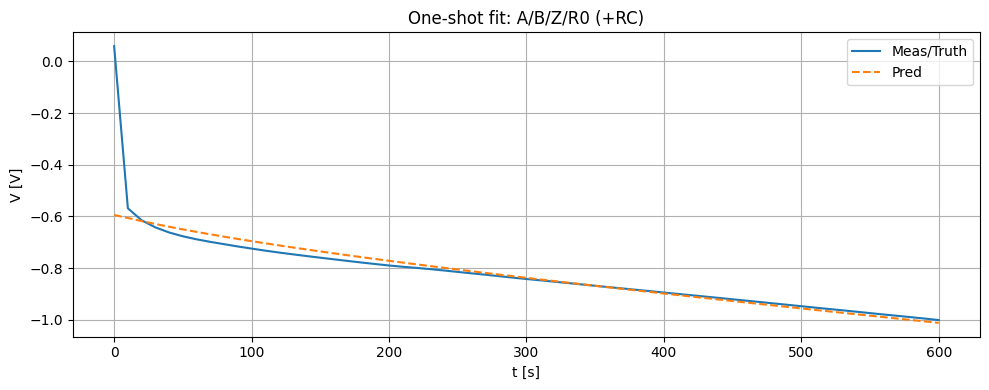

In [2]:
# =========================================================
# CELL 0 — Imports + notebook setup
# =========================================================
from __future__ import annotations

import os
from dataclasses import dataclass
from typing import Tuple, List

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

import control as ct
from scipy.linalg import block_diag
from scipy.optimize import least_squares

import jax
import jax.numpy as jnp
import diffrax
from jax_sysid.models import CTModel

# Your project modules
import src.file_loader as fl

jax.config.update("jax_platform_name", "cpu")
jax.config.update("jax_enable_x64", True)
DTYPE = jnp.float64

# =========================================================
# CELL 1 — User settings (EDIT THESE)
# =========================================================
print("CWD:", os.getcwd())

MPR_PATH = "12to1-25%CNC-3%GQDs _C01.mpr"

TIME_COL = "time/s"
I_COL    = "I/mA"        # use the column that exists in your file
V_COL    = "Ewe/V"

# Cycle selection
CYCLE_MODE  = "index"    # keep it simple
CYCLE_INDEX = 0          # your “easy” cycle

# Data prep
FORCE_UNITS = "auto"     # IMPORTANT: do not force mA unless you're sure
V_REF       = "none"     # none | first | mean
RESAMPLE    = True       # helps diffrax stability

ENFORCE_DISCHARGE_ONLY = True
RAW_DISCHARGE_SIGN     = "negative"   # typical for Biologic discharge

# Initial state guess (stoich)
XN0 = 0.60
XP0 = 0.60
CE0_DEV = 0.0

# Optional trim after selecting the cycle (seconds, after rebasing)
TMAX = -1.0

# Fit knobs
ADAM_EPOCHS  = 2500
LBFGS_EPOCHS = 1500

# Sanity thresholds
MIN_MED_ABS_I_A = 5e-3    # 5 mA in A-units
MIN_XP_RANGE    = 1e-4
MIN_XN_RANGE    = 1e-4

# Make model less "stiff": add 1 RC polarization state (recommended)
USE_RC = True
R1_INIT_OHM = 0.05
TAU_INIT_S  = 20.0


# =========================================================
# CELL 2 — Load + plot raw signals
# =========================================================
mpr_file = fl.load_mpr(MPR_PATH)
df0 = pd.DataFrame(mpr_file.data)

print("Columns:", df0.columns.tolist())
assert TIME_COL in df0.columns, f"Missing {TIME_COL}"
assert I_COL in df0.columns, f"Missing {I_COL}"
assert V_COL in df0.columns, f"Missing {V_COL}"

df = df0.set_index(TIME_COL)[[I_COL, V_COL]].copy().sort_index()
df = df.dropna()

print(df.head())

plt.figure(figsize=(12, 6))
plt.subplot(2, 1, 1)
plt.plot(df.index.values, df[I_COL].values)
plt.grid(True); plt.title("Raw Current"); plt.ylabel(I_COL)

plt.subplot(2, 1, 2)
plt.plot(df.index.values, df[V_COL].values)
plt.grid(True); plt.title("Raw Voltage"); plt.ylabel(V_COL); plt.xlabel("time [s]")
plt.tight_layout()
plt.show()


# =========================================================
# CELL 3 — Helpers: plots + scoring
# =========================================================
def plot_voltage(t, y, yhat=None, title="Voltage"):
    t = np.asarray(t).reshape(-1)
    y = np.asarray(y).reshape(-1, 1)
    plt.figure(figsize=(10, 4))
    plt.plot(t, y[:, 0], label="Meas/Truth")
    if yhat is not None:
        yhat = np.asarray(yhat).reshape(-1, 1)
        plt.plot(t, yhat[:, 0], "--", label="Pred")
    plt.grid(True); plt.legend()
    plt.xlabel("t [s]"); plt.ylabel("V [V]")
    plt.title(title)
    ax = plt.gca()
    ax.yaxis.set_major_formatter(mticker.ScalarFormatter(useOffset=False))
    ax.ticklabel_format(axis="y", style="plain", useOffset=False)
    plt.tight_layout()
    plt.show()

def vec_reshape(y):
    y = np.asarray(y)
    if y.ndim == 1:
        y = y.reshape(-1, 1)
    return y

def compute_scores(Y, Yhat, fit="R2"):
    Y = vec_reshape(Y)
    Yhat = vec_reshape(Yhat)
    y = Y[:, 0]; yh = Yhat[:, 0]
    fit = fit.lower()
    if fit == "r2":
        denom = np.sum((y - np.mean(y))**2) + 1e-12
        return 100.0 * (1.0 - np.sum((yh - y)**2)/denom)
    if fit == "rmse":
        return float(np.sqrt(np.mean((yh - y)**2)))
    if fit == "bfr":
        denom = np.sum((y - np.mean(y))**2) + 1e-12
        return 100.0 * (1.0 - np.linalg.norm(yh - y)/np.sqrt(denom))
    raise ValueError("fit must be one of: R2 | BFR | RMSE")

def report_fit(name, Y_true, Y_pred):
    Y_true = vec_reshape(Y_true)
    Y_pred = vec_reshape(Y_pred)
    err = Y_pred - Y_true
    max_abs = float(np.max(np.abs(err)))
    rmse = float(np.sqrt(np.mean(err**2)))
    r2 = float(compute_scores(Y_true, Y_pred, fit="R2"))
    bfr = float(compute_scores(Y_true, Y_pred, fit="BFR"))
    print(f"{name}: max|err|={max_abs:.6g}, rmse={rmse:.6g}, R2%={r2:.3f}, BFR%={bfr:.3f}")
    return dict(max_abs=max_abs, rmse=rmse, r2=r2, bfr=bfr)

# =========================================================
# CELL 4 — Cycle finding (simple fallback) + pick by index
# =========================================================
def find_discharging_cycles(df: pd.DataFrame, i_col: str, tol_I: float = 1e-9, min_len: int = 50):
    I = df[i_col].to_numpy(dtype=float).reshape(-1)
    mask = I < -tol_I
    cycles = []
    start = None
    for k in range(len(mask)):
        if mask[k] and start is None:
            start = k
        if (start is not None) and ((not mask[k]) or (k == len(mask) - 1)):
            end = k if (not mask[k]) else (k + 1)
            if end - start >= min_len:
                cycles.append(df.iloc[start:end].copy())
            start = None
    return cycles

cycles = find_discharging_cycles(df, i_col=I_COL, tol_I=1e-9, min_len=50)
print(f"Found {len(cycles)} discharge segments")
if len(cycles) == 0:
    raise RuntimeError("No discharge segments found. Check sign or current column.")

if CYCLE_MODE.lower() != "index":
    print("[INFO] For this cleaned notebook, we only support CYCLE_MODE='index'. For now forcing index mode.")
chosen = int(CYCLE_INDEX)
chosen = max(0, min(chosen, len(cycles)-1))

cycle_df = cycles[chosen].copy()
print("Selected cycle index:", chosen, " length:", len(cycle_df))

plt.figure(figsize=(12,4))
plt.plot(cycle_df.index.values, cycle_df[I_COL].values)
plt.grid(True); plt.title(f"Selected cycle current (index={chosen})"); plt.ylabel(I_COL); plt.xlabel("time [s]")
plt.show()

# =========================================================
# CELL 5 — Prepare (t,U,Y): units, discharge-only, resample
# =========================================================
def _sanity_report_current_units(I_raw: np.ndarray):
    I_as_A  = I_raw
    I_as_mA = I_raw * 1e-3
    print("[UNIT CHECK] If column is actually A:")
    print("  range [A]:", float(np.min(I_as_A)), float(np.max(I_as_A)),
          " median|I|:", float(np.median(np.abs(I_as_A))))
    print("[UNIT CHECK] If column is actually mA:")
    print("  range [A]:", float(np.min(I_as_mA)), float(np.max(I_as_mA)),
          " median|I|:", float(np.median(np.abs(I_as_mA))))

def _guess_I_in_amps(I_raw: np.ndarray) -> Tuple[np.ndarray, str]:
    """
    Better heuristic than "name-based":
    - if median|I| > 0.02 => likely A already
    - elif median|I| > 5  => likely mA
    - else ambiguous => assume A but warn
    """
    med = float(np.nanmedian(np.abs(I_raw)))
    if med > 0.02:
        return I_raw, f"auto units: treating as A (median|I|={med:.6g})"
    if med > 5.0:
        return I_raw * 1e-3, f"auto units: mA->A (median|I|={med:.6g} mA)"
    return I_raw, f"auto units: ambiguous, using A (median|I|={med:.6g}). If this is wrong, set FORCE_UNITS."

def resample_uniform(t: np.ndarray, u: np.ndarray, y: np.ndarray, dt: float):
    t0, t1 = float(t[0]), float(t[-1])
    tg = np.arange(t0, t1 + dt, dt, dtype=np.float64)
    u1 = np.interp(tg, t, u[:,0]).reshape(-1,1)
    y1 = np.interp(tg, t, y[:,0]).reshape(-1,1)
    return tg, u1, y1

t = cycle_df.index.to_numpy(dtype=np.float64).reshape(-1)
I_raw = cycle_df[I_COL].to_numpy(dtype=np.float64).reshape(-1)
V_raw = cycle_df[V_COL].to_numpy(dtype=np.float64).reshape(-1)

_sanity_report_current_units(I_raw)

# units
if str(FORCE_UNITS).lower() == "auto":
    I_A, note = _guess_I_in_amps(I_raw)
    print(note)
elif str(FORCE_UNITS).lower() == "ma":
    I_A = I_raw * 1e-3
    print("FORCE_UNITS=mA => converting to A")
elif str(FORCE_UNITS).lower() == "a":
    I_A = I_raw
    print("FORCE_UNITS=A => using as A")
else:
    raise ValueError("FORCE_UNITS must be 'auto'|'mA'|'A'")

# make time strictly increasing
keep = np.ones_like(t, dtype=bool)
keep[1:] = t[1:] > t[:-1]
t, I_A, V_raw = t[keep], I_A[keep], V_raw[keep]

# rebase time
t = t - t[0]

# optional discharge-only (recommended to keep, but now uses A-units)
if ENFORCE_DISCHARGE_ONLY:
    tol = 1e-12
    if RAW_DISCHARGE_SIGN == "negative":
        mask = I_A < -tol
    elif RAW_DISCHARGE_SIGN == "positive":
        mask = I_A > +tol
    else:
        raise ValueError("RAW_DISCHARGE_SIGN must be 'negative' or 'positive'")
    before = len(t)
    t, I_A, V_raw = t[mask], I_A[mask], V_raw[mask]
    if len(t) < 5:
        raise RuntimeError("After discharge-only filter, not enough points.")
    t = t - t[0]
    print(f"Discharge-only kept {len(t)}/{before} points")

# voltage reference
if V_REF == "none":
    V = V_raw
elif V_REF == "first":
    V = V_raw - float(V_raw[0])
elif V_REF == "mean":
    V = V_raw - float(np.mean(V_raw))
else:
    raise ValueError("V_REF must be none|first|mean")

t_np = t.reshape(-1)
U_np = I_A.reshape(-1,1)
Y_np = V.reshape(-1,1)

print("Prepared shapes:", t_np.shape, U_np.shape, Y_np.shape)
print("I range [A]:", float(U_np.min()), float(U_np.max()),
      " median|I| [A]:", float(np.median(np.abs(U_np[:,0]))))
print("V range [V]:", float(Y_np.min()), float(Y_np.max()))
plot_voltage(t_np, Y_np, title="Prepared (pre-resample/trim)")

med_abs_I = float(np.median(np.abs(U_np[:,0])))
if med_abs_I < float(MIN_MED_ABS_I_A):
    print("\n[TEST FAIL] Current magnitude too small -> model will look stiff/flat.")
    print("  Fix: set FORCE_UNITS='A' if you believe the file already stores A.\n")

if RESAMPLE and len(t_np) > 2:
    dt_med = float(np.median(np.diff(t_np)))
    if not (np.isfinite(dt_med) and dt_med > 0):
        raise RuntimeError("Bad dt_med; cannot resample.")
    t_np, U_np, Y_np = resample_uniform(t_np, U_np, Y_np, dt=dt_med)
    print("Resampled: dt_med =", dt_med, "len =", len(t_np))

if TMAX > 0:
    m = t_np <= float(TMAX)
    t_np, U_np, Y_np = t_np[m], U_np[m], Y_np[m]
    print("Trimmed to TMAX:", TMAX, "len =", len(t_np))

plot_voltage(t_np, Y_np, title="Prepared (post-resample/trim)")

# =========================================================
# CELL 6 — Nominal 14-state model + proxies xp/xn
# =========================================================
IDX = {
    "cn": slice(0, 4),
    "cp": slice(4, 8),
    "ce": slice(8, 14),
    "cn_surf": 3,
    "cp_surf": 7,
}

@dataclass
class Config:
    R: float = 8.314462618
    F: float = 96485.33212
    T: float = 298.15
    L1: float = 25e-6
    L2: float = 20e-6
    L3: float = 25e-6
    Rn: float = 5e-6
    Rp: float = 5e-6
    A: float = 1.0
    Dn: float = 1e-14
    Dp: float = 1e-14
    De: float = 7.23e-10
    eps: float = 0.30
    a_s_n: float = 1.0e6
    a_s_p: float = 1.0e6
    csn_max: float = 3.1e4
    csp_max: float = 3.1e4
    t_plus: float = 0.38
    discharge_positive: bool = False
    N_series: int = 1

def build_An(cfg: Config) -> np.ndarray:
    s = cfg.Dn / (cfg.Rn ** 2)
    A = np.zeros((4,4))
    A[0,0],A[0,1] = -24*s, 24*s
    A[1,0],A[1,1],A[1,2] = 16*s, -40*s, 24*s
    A[2,1],A[2,2],A[2,3] = 16*s, -40*s, 24*s
    A[3,2],A[3,3] = 16*s, -16*s
    return A

def build_Bn(cfg: Config) -> np.ndarray:
    sign = -1.0 if cfg.discharge_positive else +1.0
    b = np.zeros((4,1))
    b[-1,0] = sign*(6.0/cfg.Rn)*(1.0/(cfg.F*cfg.a_s_n*cfg.A*cfg.L1))
    return b

def build_Ap(cfg: Config) -> np.ndarray:
    s = cfg.Dp / (cfg.Rp ** 2)
    A = np.zeros((4,4))
    A[0,0],A[0,1] = -24*s, 24*s
    A[1,0],A[1,1],A[1,2] = 16*s, -40*s, 24*s
    A[2,1],A[2,2],A[2,3] = 16*s, -40*s, 24*s
    A[3,2],A[3,3] = 16*s, -16*s
    return A

def build_Bp(cfg: Config) -> np.ndarray:
    sign = +1.0 if cfg.discharge_positive else -1.0
    b = np.zeros((4,1))
    b[-1,0] = sign*(6.0/cfg.Rp)*(1.0/(cfg.F*cfg.a_s_p*cfg.A*cfg.L3))
    return b

def build_Ae(cfg: Config) -> np.ndarray:
    K = cfg.De / cfg.eps
    Ae = np.zeros((6,6))
    w_in = lambda L: K*4.0/(L**2)
    w_intf = lambda La,Lb: K*16.0/((La+Lb)**2)
    w11 = w_in(cfg.L1); w12 = w_intf(cfg.L1,cfg.L2)
    w23 = w_in(cfg.L2); w34 = w_intf(cfg.L2,cfg.L3)
    w45 = w_in(cfg.L3)
    Ae[0,0]=-(w11); Ae[0,1]=+(w11)
    Ae[1,0]=+(w11); Ae[1,1]=-(w11+w12); Ae[1,2]=+(w12)
    Ae[2,1]=+(w12); Ae[2,2]=-(w12+w23); Ae[2,3]=+(w23)
    Ae[3,2]=+(w23); Ae[3,3]=-(w23+w34); Ae[3,4]=+(w34)
    Ae[4,3]=+(w34); Ae[4,4]=-(w34+w45); Ae[4,5]=+(w45)
    Ae[5,4]=+(w45); Ae[5,5]=-(w45)
    return Ae

def build_Be(cfg: Config) -> np.ndarray:
    b = np.zeros((6,1))
    sign_left  = -1.0 if cfg.discharge_positive else +1.0
    sign_right = +1.0 if cfg.discharge_positive else -1.0
    s1 = sign_left  * (1.0 - cfg.t_plus) / (cfg.F*cfg.A*cfg.L1*cfg.eps)
    s3 = sign_right * (1.0 - cfg.t_plus) / (cfg.F*cfg.A*cfg.L3*cfg.eps)
    b[0,0]=s1; b[1,0]=s1
    b[4,0]=s3; b[5,0]=s3
    return b

def assemble_system(cfg: Config):
    An,Ap,Ae = build_An(cfg), build_Ap(cfg), build_Ae(cfg)
    Bn,Bp,Be = build_Bn(cfg), build_Bp(cfg), build_Be(cfg)
    Aglob = block_diag(An,Ap,Ae)
    Bglob = np.vstack([Bn,Bp,Be])
    S = ct.ss(Aglob, Bglob, np.eye(14), np.zeros((14,1)))
    return S, Aglob, Bglob

def make_x0(cfg: Config, theta_n0=0.6, theta_p0=0.6, ce0=0.0):
    x0 = np.zeros(14, dtype=np.float64)
    x0[IDX["cn"]] = float(theta_n0) * cfg.csn_max
    x0[IDX["cp"]] = float(theta_p0) * cfg.csp_max
    x0[IDX["ce"]] = float(ce0)
    return x0

CFG = Config()
CFG.discharge_positive = False

Sx, A_np, B_np = assemble_system(CFG)
x0 = make_x0(CFG, theta_n0=XN0, theta_p0=XP0, ce0=CE0_DEV)

resp = ct.forced_response(Sx, T=t_np, U=U_np[:,0], X0=x0)
X_proxy = np.asarray(resp.states).T  # (N,14)

xp_sig = (X_proxy[:, IDX["cp_surf"]] / CFG.csp_max).astype(np.float64)
xn_sig = (X_proxy[:, IDX["cn_surf"]] / CFG.csn_max).astype(np.float64)

xp_rng = float(xp_sig.max() - xp_sig.min())
xn_rng = float(xn_sig.max() - xn_sig.min())

print("[PROXY] xp range:", float(xp_sig.min()), float(xp_sig.max()), " span:", xp_rng)
print("[PROXY] xn range:", float(xn_sig.min()), float(xn_sig.max()), " span:", xn_rng)

if xp_rng < MIN_XP_RANGE or xn_rng < MIN_XN_RANGE:
    print("\n[WARN] Proxies barely move -> model will look stiff.")
    print("Fix is almost always CURRENT UNITS or cycle selection.\n")
    
# =========================================================
# CELL 7 — One-shot full fit (estimate everything)
# =========================================================
def softplus(x):
    return jnp.log1p(jnp.exp(-jnp.abs(x))) + jnp.maximum(x, 0)

def pos(x, floor=1e-12):
    return softplus(x) + floor

def softplus_inv(y):
    y = float(max(y, 1e-12))
    if y > 20:
        return y
    return np.log(np.expm1(y))

def raw_from_pos(val, floor=1e-12):
    val = float(max(val, floor + 1e-12))
    return softplus_inv(val - floor)

# --- quick init for thetaZ and R0 (NOT a full Stage 2 training) ---
def init_thetaZ_R0_scipy(xp, xn, V, I_t, Ns, R0_guess=1e-2):
    xp = np.asarray(xp).reshape(-1)
    xn = np.asarray(xn).reshape(-1)
    V  = np.asarray(V).reshape(-1)
    I_t = np.asarray(I_t).reshape(-1)

    vmin, vmax, vmean = float(np.min(V)), float(np.max(V)), float(np.mean(V))
    amp = 0.25 * (vmax - vmin + 1e-12)
    theta0 = np.array([amp, 3.0, -1.5, amp, 3.0, -1.5, vmean], dtype=float)

    p0 = np.hstack([theta0, np.array([R0_guess], dtype=float)])

    def model(p):
        a,b,c,d,e,f,g,R0 = p
        Z = a*np.tanh(b*xp+c) + d*np.tanh(e*xn+f) + g
        return Z - float(Ns) * I_t * float(R0)

    def resid(p):
        return model(p) - V

    res = least_squares(resid, p0, loss="linear", max_nfev=20_000)
    a,b,c,d,e,f,g,R0 = res.x
    R0 = float(max(R0, 1e-12))
    return np.array([a,b,c,d,e,f,g], dtype=np.float64), R0

thetaZ0, R0_0 = init_thetaZ_R0_scipy(xp_sig, xn_sig, Y_np[:,0], U_np[:,0], CFG.N_series, R0_guess=1e-2)
print("Init thetaZ0:", thetaZ0)
print("Init R0:", R0_0)

# ---- parameterized A,B (thetaA 7, thetaB 4) ----
@jax.jit
def build_A_from_thetaA(thetaA: jnp.ndarray) -> jnp.ndarray:
    th1, th2, th3, th4, th5, th6, th7 = thetaA
    An = jnp.array([
        [-24*th1,  24*th1,   0.0,    0.0],
        [ 16*th1, -40*th1, 24*th1,   0.0],
        [  0.0,   16*th1, -40*th1, 24*th1],
        [  0.0,     0.0,  16*th1, -16*th1],
    ], dtype=DTYPE)
    Ap = jnp.array([
        [-24*th2,  24*th2,   0.0,    0.0],
        [ 16*th2, -40*th2, 24*th2,   0.0],
        [  0.0,   16*th2, -40*th2, 24*th2],
        [  0.0,     0.0,  16*th2, -16*th2],
    ], dtype=DTYPE)
    Ae = jnp.array([
        [-4*th3,              4*th3,              0.0,              0.0,              0.0,     0.0],
        [ 4*th3, -(4*th3+16*th4),             16*th4,              0.0,              0.0,     0.0],
        [ 0.0,             16*th4, -(16*th4+4*th5),              4*th5,              0.0,     0.0],
        [ 0.0,               0.0,              4*th5, -(4*th5+16*th6),             16*th6,    0.0],
        [ 0.0,               0.0,               0.0,             16*th6, -(16*th6+4*th7),  4*th7],
        [ 0.0,               0.0,               0.0,              0.0,              4*th7, -4*th7],
    ], dtype=DTYPE)

    A = jnp.zeros((14,14), dtype=DTYPE)
    A = A.at[0:4,0:4].set(An)
    A = A.at[4:8,4:8].set(Ap)
    A = A.at[8:14,8:14].set(Ae)
    return A

@jax.jit
def build_B_from_thetaB(thetaB: jnp.ndarray) -> jnp.ndarray:
    th8, th9, th10, th11 = thetaB
    B = jnp.zeros((14,1), dtype=DTYPE)
    B = B.at[3,0].set(6.0*th8)
    B = B.at[7,0].set(6.0*th9)
    B = B.at[8,0].set(th10)
    B = B.at[9,0].set(th10)
    B = B.at[12,0].set(th11)
    B = B.at[13,0].set(th11)
    return B

def thetaA_nom_from_cfg(cfg: Config) -> np.ndarray:
    th1 = cfg.Dn/(cfg.Rn**2)
    th2 = cfg.Dp/(cfg.Rp**2)
    K = cfg.De/cfg.eps
    th3 = K/(cfg.L1**2)
    th4 = K/((cfg.L1+cfg.L2)**2)
    th5 = K/(cfg.L2**2)
    th6 = K/((cfg.L2+cfg.L3)**2)
    th7 = K/(cfg.L3**2)
    return np.array([th1,th2,th3,th4,th5,th6,th7], dtype=np.float64)

def thetaB_nom_from_cfg(cfg: Config) -> np.ndarray:
    sign_n = -1.0 if cfg.discharge_positive else +1.0
    sign_p = +1.0 if cfg.discharge_positive else -1.0
    th8 = sign_n*(1.0/cfg.Rn)*(1.0/(cfg.F*cfg.a_s_n*cfg.A*cfg.L1))
    th9 = sign_p*(1.0/cfg.Rp)*(1.0/(cfg.F*cfg.a_s_p*cfg.A*cfg.L3))
    sign_left  = -1.0 if cfg.discharge_positive else +1.0
    sign_right = +1.0 if cfg.discharge_positive else -1.0
    th10 = sign_left *(1.0-cfg.t_plus)/(cfg.F*cfg.A*cfg.L1*cfg.eps)
    th11 = sign_right*(1.0-cfg.t_plus)/(cfg.F*cfg.A*cfg.L3*cfg.eps)
    return np.array([th8,th9,th10,th11], dtype=np.float64)

thetaA_nom = jnp.array(thetaA_nom_from_cfg(CFG), dtype=DTYPE)
thetaB_nom = jnp.array(thetaB_nom_from_cfg(CFG), dtype=DTYPE)

@jax.jit
def zhat_from_thetaZ(x14: jnp.ndarray, thetaZ: jnp.ndarray) -> jnp.ndarray:
    a,b,c,d,e,f,g = thetaZ
    xp = jnp.clip(x14[IDX["cp_surf"]] / DTYPE(CFG.csp_max), 1e-9, 1-1e-9)
    xn = jnp.clip(x14[IDX["cn_surf"]] / DTYPE(CFG.csn_max), 1e-9, 1-1e-9)
    return a*jnp.tanh(b*xp+c) + d*jnp.tanh(e*xn+f) + g

def unpack_raw(raw: jnp.ndarray):
    raw = raw.reshape(-1)

    dA = raw[0:7]
    dB = raw[7:11]
    thetaZ = raw[11:18]
    rawR0 = raw[18]

    thetaA = thetaA_nom * jnp.exp(dA)
    thetaB = thetaB_nom + dB

    if USE_RC:
        rawR1  = raw[19]
        rawTau = raw[20]
        return thetaA, thetaB, thetaZ, rawR0, rawR1, rawTau
    else:
        return thetaA, thetaB, thetaZ, rawR0

@jax.jit
def state_fcn(x, u, t, params):
    (raw_theta,) = params
    I = u[0]

    if USE_RC:
        x14 = x[:14]
        vrc = x[14]
        thetaA, thetaB, _, _, rawR1, rawTau = unpack_raw(raw_theta)

        A = build_A_from_thetaA(thetaA)
        B = build_B_from_thetaB(thetaB)

        R1  = pos(jnp.asarray(rawR1).reshape(()), 1e-12)
        tau = pos(jnp.asarray(rawTau).reshape(()), 1e-6)

        dx14 = A @ x14 + (B[:,0] * I)
        dvrc = (-vrc / tau) + (R1 / tau) * I
        return jnp.concatenate([dx14, jnp.array([dvrc], dtype=DTYPE)], axis=0)

    else:
        thetaA, thetaB, _, _ = unpack_raw(raw_theta)
        A = build_A_from_thetaA(thetaA)
        B = build_B_from_thetaB(thetaB)
        return A @ x + (B[:,0] * I)

@jax.jit
def output_fcn(x, u, t, params):
    (raw_theta,) = params
    I = u[0]

    if USE_RC:
        x14 = x[:14]
        vrc = x[14]
        _, _, thetaZ, rawR0, _, _ = unpack_raw(raw_theta)
        R0 = pos(rawR0, 1e-12)
        Z = zhat_from_thetaZ(x14, thetaZ)
        Vhat = Z - DTYPE(CFG.N_series)*I*R0 - vrc
        return jnp.array([Vhat], dtype=DTYPE)

    else:
        _, _, thetaZ, rawR0 = unpack_raw(raw_theta)
        R0 = pos(rawR0, 1e-12)
        Z = zhat_from_thetaZ(x, thetaZ)
        Vhat = Z - DTYPE(CFG.N_series)*I*R0
        return jnp.array([Vhat], dtype=DTYPE)

# ---- init around nominal ----
dA0 = np.zeros(7, dtype=np.float64)
dB0 = np.zeros(4, dtype=np.float64)
thetaZ_init = thetaZ0.astype(np.float64)
rawR0_init = raw_from_pos(R0_0, floor=1e-12)

eps = 0.02
dA0 += eps*np.linspace(-1.0, 1.0, 7)
dB0 += eps*np.linspace(-1.0, 1.0, 4)
thetaZ_init *= (1.0 + eps*np.linspace(-1.0, 1.0, 7))

if USE_RC:
    rawR1_init  = raw_from_pos(R1_INIT_OHM, floor=1e-12)
    rawTau_init = raw_from_pos(TAU_INIT_S,  floor=1e-6)
    raw_init = np.concatenate([dA0, dB0, thetaZ_init, np.array([rawR0_init, rawR1_init, rawTau_init])])
    nx = 15
    x0_aug = np.concatenate([x0.astype(np.float64), np.array([0.0], dtype=np.float64)])
else:
    raw_init = np.concatenate([dA0, dB0, thetaZ_init, np.array([rawR0_init])])
    nx = 14
    x0_aug = x0.astype(np.float64)

model = CTModel(nx, 1, 1, state_fcn=state_fcn, output_fcn=output_fcn)
model.init(params=[raw_init.astype(np.float64)], x0=x0_aug)

try:
    model.loss(rho_x0=0.0, rho_th=1e-6, train_x0=False, xsat=1e9)
except TypeError:
    model.loss(rho_x0=0.0, rho_th=1e-6)

model.optimization(adam_epochs=ADAM_EPOCHS, lbfgs_epochs=LBFGS_EPOCHS, adam_eta=5e-4)
model.integration_options(
    ode_solver=diffrax.Tsit5(),
    dt0=float(t_np[1]-t_np[0]) / 50.0,
    max_steps=5_000_000,
    stepsize_controller=diffrax.PIDController(rtol=1e-6, atol=1e-9),
)

Y0, _ = model.predict(model.x0, U_np, t_np)
report_fit("Pre-fit", Y_np, Y0)

model.fit(Y_np, U_np, t_np)

Yhat, _ = model.predict(model.x0, U_np, t_np)
report_fit("Post-fit", Y_np, Yhat)

plot_voltage(t_np, Y_np, Yhat, title="One-shot fit: A/B/Z/R0 (+RC)")

In [ ]:
# =========================================================
# CELL 0 — Imports + notebook setup
# =========================================================
from __future__ import annotations

import os
from dataclasses import dataclass
from typing import Tuple, Dict, List, Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

import control as ct
from scipy.linalg import block_diag
from scipy.optimize import least_squares

import jax
import jax.numpy as jnp
import diffrax
from jax_sysid.models import CTModel

# Your project modules
import src.file_loader as fl

try:
    import src.data_processing as dp
    HAS_DP = True
except Exception:
    HAS_DP = False

jax.config.update("jax_platform_name", "cpu")
jax.config.update("jax_enable_x64", True)
DTYPE = jnp.float64

# =========================================================
# CELL 1 — User settings (EDIT THESE)
# =========================================================
print("CWD:", os.getcwd())

MPR_PATH = "12to1-25%CNC-3%GQDs _C01.mpr"

TIME_COL = "time/s"
I_COL    = "I/mA"
V_COL    = "Ewe/V"

# # Cycle selection (recommended while debugging)
# CYCLE_MODE   = "index"     # "auto" | "index" | "longest" | "best_cc"
# CYCLE_INDEX  = 0

# Cycle selection (NEW)
CYCLE_MODE = "halfcycle"   # "halfcycle" (recommended) | "fallback_sign"
HALF_CYCLE_MODE = "auto"   # "auto" | "index" | "value"
HALF_CYCLE_INDEX = 0       # used if HALF_CYCLE_MODE="index"
HALF_CYCLE_VALUE = None    # used if HALF_CYCLE_MODE="value"

# half-cycle filters
MIN_HALF_POINTS = 300
MIN_HALF_DUR_S  = 60.0
PREFER_DISCHARGE = True    # prefer half-cycles with mostly negative current

# For scoring: require some minimum median current (in mA, since I_COL is I/mA)
MIN_HALF_MED_ABS_I_mA = 0.02   # tune: 0.01–0.10 based on your dataset

# Data prep
FORCE_UNITS  = "auto"     # keep auto until you're 100% sure
V_REF        = "none"
RESAMPLE     = True
ENFORCE_DISCHARGE_ONLY = True
RAW_DISCHARGE_SIGN = "negative"

# Initial state guess (stoich)
XN0 = 0.60
XP0 = 0.60
CE0_DEV = 0.0

# Optional trim
TMAX = -1.0

# Optimization knobs
STAGE2_ADAM_EPOCHS  = 300
STAGE2_LBFGS_EPOCHS = 700
STAGE3_ADAM_EPOCHS  = 2000
STAGE3_LBFGS_EPOCHS = 1000

# ---------------------------
# Sanity thresholds (tests)
# ---------------------------
MIN_MED_ABS_I_A = 5e-3     # 5 mA
MIN_XP_RANGE    = 1e-4
MIN_XN_RANGE    = 1e-4

# ---------------------------
# NEW: add a fast RC polarization state to capture "bend"
# ---------------------------
USE_RC = True

# RC initial guesses (only used if USE_RC=True)
R1_INIT_OHM  = 0.05     # polarization resistance
TAU_INIT_S   = 15.0     # time constant (seconds)




# # =========================================================
# # CELL 2 — Quick load + plot raw signals
# # =========================================================
# mpr_file = fl.load_mpr(MPR_PATH)
# df0 = pd.DataFrame(mpr_file.data)

# print("Columns:", df0.columns.tolist())
# assert TIME_COL in df0.columns, f"Missing {TIME_COL}"
# assert I_COL in df0.columns, f"Missing {I_COL}"
# assert V_COL in df0.columns, f"Missing {V_COL}"

# df = df0.set_index(TIME_COL)[[I_COL, V_COL]].copy().sort_index()
# df = df.dropna()

# # --- dp in your project expects 'control/mA', so we provide an alias ---
# if "control/mA" not in df.columns:
#     df["control/mA"] = df[I_COL]

# print(df.head())

# plt.figure(figsize=(12, 6))
# plt.subplot(2, 1, 1)
# plt.plot(df.index.values, df[I_COL].values)
# plt.grid(True); plt.title("Raw Current"); plt.ylabel(I_COL)

# plt.subplot(2, 1, 2)
# plt.plot(df.index.values, df[V_COL].values)
# plt.grid(True); plt.title("Raw Voltage"); plt.ylabel(V_COL); plt.xlabel("time [s]")
# plt.tight_layout()
# plt.show()


# =========================================================
# CELL 2 — Quick load + plot raw signals (keep df0 intact)
# =========================================================
mpr_file = fl.load_mpr(MPR_PATH)
df0 = pd.DataFrame(mpr_file.data)

print("Columns:", df0.columns.tolist())
assert TIME_COL in df0.columns, f"Missing {TIME_COL}"
assert I_COL in df0.columns, f"Missing {I_COL}"
assert V_COL in df0.columns, f"Missing {V_COL}"

# Keep a minimal df for quick plotting, but DON'T delete df0 columns
df = df0[[TIME_COL, I_COL, V_COL]].copy().dropna()
df = df.sort_values(TIME_COL).set_index(TIME_COL)

# dp expects 'control/mA' sometimes; provide alias for compatibility (optional)
if "control/mA" not in df0.columns:
    df0["control/mA"] = df0[I_COL]

print(df.head())

plt.figure(figsize=(12, 6))
plt.subplot(2, 1, 1)
plt.plot(df.index.values, df[I_COL].values)
plt.grid(True); plt.title("Raw Current"); plt.ylabel(I_COL)

plt.subplot(2, 1, 2)
plt.plot(df.index.values, df[V_COL].values)
plt.grid(True); plt.title("Raw Voltage"); plt.ylabel(V_COL); plt.xlabel("time [s]")
plt.tight_layout()
plt.show()

# =========================================================
# CELL 3 — Helpers: plots + scoring
# =========================================================
def plot_voltage(t, y, yhat=None, title="Voltage"):
    t = np.asarray(t).reshape(-1)
    y = np.asarray(y).reshape(-1, 1)
    plt.figure(figsize=(10, 4))
    plt.plot(t, y[:, 0], label="Meas/Truth")
    if yhat is not None:
        yhat = np.asarray(yhat).reshape(-1, 1)
        plt.plot(t, yhat[:, 0], "--", label="Pred")
    plt.grid(True); plt.legend()
    plt.xlabel("t [s]"); plt.ylabel("V [V]")
    plt.title(title)
    ax = plt.gca()
    ax.yaxis.set_major_formatter(mticker.ScalarFormatter(useOffset=False))
    ax.ticklabel_format(axis="y", style="plain", useOffset=False)
    plt.tight_layout()
    plt.show()

def vec_reshape(y):
    y = np.asarray(y)
    if y.ndim == 1:
        y = y.reshape(-1, 1)
    return y

def compute_scores(Y, Yhat, fit="R2"):
    Y = vec_reshape(Y)
    Yhat = vec_reshape(Yhat)
    ny = Y.shape[1]
    score = np.zeros(ny)
    fit = fit.lower()
    for i in range(ny):
        y = Y[:, i]; yh = Yhat[:, i]
        if fit == "r2":
            denom = np.sum((y - np.mean(y))**2) + 1e-12
            score[i] = 100.0 * (1.0 - np.sum((yh - y)**2)/denom)
        elif fit == "bfr":
            denom = np.sum((y - np.mean(y))**2) + 1e-12
            score[i] = 100.0 * (1.0 - np.linalg.norm(yh - y)/np.sqrt(denom))
        elif fit == "rmse":
            score[i] = np.sqrt(np.mean((yh - y)**2))
        else:
            raise ValueError("fit must be one of: R2 | BFR | RMSE")
    return score

def report_fit(name, Y_true, Y_pred):
    Y_true = vec_reshape(Y_true)
    Y_pred = vec_reshape(Y_pred)
    err = Y_pred - Y_true
    max_abs = float(np.max(np.abs(err)))
    rmse = float(np.sqrt(np.mean(err**2)))
    r2 = float(compute_scores(Y_true, Y_pred, fit="R2")[0])
    bfr = float(compute_scores(Y_true, Y_pred, fit="BFR")[0])
    print(f"{name}: max|err|={max_abs:.6g}, rmse={rmse:.6g}, R2%={r2:.3f}, BFR%={bfr:.3f}")
    return dict(max_abs=max_abs, rmse=rmse, r2=r2, bfr=bfr)


# # =========================================================
# # CELL 4 — Cycle finding (FORCED fallback; avoids dp hard-coded column names)
# # =========================================================
# def _fallback_find_discharging_cycles(df: pd.DataFrame, i_col: str, tol_I: float = 1e-6, min_len: int = 50):
#     I = df[i_col].to_numpy(dtype=float).reshape(-1)
#     mask = I < -tol_I
#     cycles = []
#     start = None
#     for k in range(len(mask)):
#         if mask[k] and start is None:
#             start = k
#         if (start is not None) and ((not mask[k]) or (k == len(mask) - 1)):
#             end = k if (not mask[k]) else (k + 1)
#             if end - start >= min_len:
#                 cycles.append(df.iloc[start:end].copy())
#             start = None
#     return cycles

# def cycle_stats(cy: pd.DataFrame, i_col: str, v_col: str, tol_I: float = 1e-6):
#     t = cy.index.to_numpy(dtype=float).reshape(-1)
#     I = cy[i_col].to_numpy(dtype=float).reshape(-1)
#     V = cy[v_col].to_numpy(dtype=float).reshape(-1)
#     dur = float(t[-1] - t[0]) if len(t) >= 2 else 0.0
#     frac_neg = float(np.mean(I < -tol_I)) if len(I) else 0.0
#     frac_pos = float(np.mean(I > +tol_I)) if len(I) else 0.0
#     Icc = float(np.nanstd(I) / (np.nanmedian(np.abs(I)) + 1e-12)) if len(I) else np.inf
#     Iabs_med = float(np.nanmedian(np.abs(I))) if len(I) else 0.0
#     Vrng = float(np.nanmax(V) - np.nanmin(V)) if len(V) else 0.0
#     return dict(k=None, n=len(t), dur=dur, frac_neg=frac_neg, frac_pos=frac_pos,
#                 Icc_score=Icc, Vrng=Vrng, Iabs_med=Iabs_med)

# def pick_discharge_cycle(cycles: List[pd.DataFrame], i_col: str, v_col: str,
#                         mode: str="auto", index: int=0, min_points: int=200, min_dur_s: float=60.0,
#                         prefer_negative_current: bool=True, tol_I: float=1e-6,
#                         min_abs_I: float = 10.0):
#     rows = []
#     for k, cy in enumerate(cycles):
#         st = cycle_stats(cy, i_col, v_col, tol_I=tol_I)
#         st["k"] = k
#         rows.append(st)
#     stats_df = pd.DataFrame(rows)
#     stats_df["ok_points"] = stats_df["n"] >= min_points
#     stats_df["ok_dur"] = stats_df["dur"] >= min_dur_s
#     stats_df["ok_I"] = stats_df["Iabs_med"] >= float(min_abs_I)

#     if prefer_negative_current:
#         stats_df["sign_score"] = stats_df["frac_neg"] - stats_df["frac_pos"]
#     else:
#         stats_df["sign_score"] = stats_df["frac_pos"] - stats_df["frac_neg"]

#     stats_df["auto_score"] = (
#         5.0 * stats_df["sign_score"]
#         - 2.0 * stats_df["Icc_score"]
#         + 0.5 * np.log1p(stats_df["Vrng"])
#         + 0.1 * np.log1p(stats_df["dur"])
#     )

#     cand = stats_df[stats_df["ok_points"] & stats_df["ok_dur"] & stats_df["ok_I"]].copy()
#     if cand.empty:
#         # fall back: at least ensure non-trivial current
#         cand = stats_df[stats_df["ok_I"]].copy()
#     if cand.empty:
#         cand = stats_df.copy()

#     mode = (mode or "auto").lower()
#     if mode == "index":
#         chosen_k = int(index)
#     elif mode == "longest":
#         chosen_k = int(cand.sort_values(["dur","n"], ascending=False).iloc[0]["k"])
#     elif mode == "best_cc":
#         chosen_k = int(cand.sort_values(["Icc_score","dur"], ascending=[True, False]).iloc[0]["k"])
#     elif mode == "auto":
#         chosen_k = int(cand.sort_values(["auto_score"], ascending=False).iloc[0]["k"])
#     else:
#         raise ValueError("mode must be one of: auto|index|longest|best_cc")

#     stats_sorted = stats_df.sort_values(["auto_score"], ascending=False).reset_index(drop=True)
#     return cycles[chosen_k].copy(), stats_sorted


# # --- FORCE fallback (dp is hard-coded to 'control/mA' in your project) ---
# cycles = _fallback_find_discharging_cycles(df, i_col=I_COL)
# print(f"fallback cycle finder found {len(cycles)} cycles")

# if len(cycles) == 0:
#     raise RuntimeError("No discharge cycles found. Check sign/unit settings and current column.")

# cycle_df, stats_df = pick_discharge_cycle(
#     cycles, i_col=I_COL, v_col=V_COL,
#     mode=CYCLE_MODE, index=CYCLE_INDEX,
#     min_points=200, min_dur_s=60.0,
#     prefer_negative_current=True,
#     min_abs_I=10.0  # mA threshold (tune: 5, 10, 20 mA)
# )

# print("Cycle ranking (top 10):")
# print(stats_df.head(10).to_string(index=False))
# print("Selected cycle length:", len(cycle_df))

# plt.figure(figsize=(12,4))
# plt.plot(cycle_df.index.values, cycle_df[I_COL].values)
# plt.grid(True); plt.title(f"Selected cycle current ({I_COL})")
# plt.show()

# =========================================================
# CELL 4 — Cycle finding using BioLogic "half cycle" (preferred)
# Falls back to sign-based segmentation if half cycle missing.
# =========================================================

HALF_COL = "half cycle"
Q_COL    = "Q charge/discharge/mA.h"   # optional but helpful

def summarize_halfcycles(df0: pd.DataFrame,
                         time_col: str,
                         i_col: str,
                         v_col: str,
                         half_col: str = "half cycle",
                         q_col: str = "Q charge/discharge/mA.h",
                         min_points: int = 300,
                         min_dur_s: float = 60.0):
    req = [time_col, i_col, v_col, half_col]
    for c in req:
        if c not in df0.columns:
            raise KeyError(f"Missing column: {c}")

    cols = [time_col, i_col, v_col, half_col]
    if q_col in df0.columns:
        cols.append(q_col)

    dfh = df0[cols].copy()
    dfh = dfh.dropna(subset=[time_col, i_col, v_col, half_col])
    dfh = dfh.sort_values(time_col)

    rows = []
    for hc, g in dfh.groupby(half_col):
        t = g[time_col].to_numpy(dtype=float)
        I = g[i_col].to_numpy(dtype=float)
        V = g[v_col].to_numpy(dtype=float)

        n = len(g)
        if n < 5:
            continue

        dur = float(t[-1] - t[0])
        med_abs_I_mA = float(np.nanmedian(np.abs(I)))
        frac_neg = float(np.mean(I < 0))
        frac_pos = float(np.mean(I > 0))
        Vrng = float(np.nanmax(V) - np.nanmin(V))

        q_mono = np.nan
        q_span = np.nan
        if q_col in g.columns:
            Q = g[q_col].to_numpy(dtype=float)
            if len(Q) > 2:
                dQ = np.diff(Q)
                q_mono = float(np.mean(dQ >= 0))
                q_span = float(np.nanmax(Q) - np.nanmin(Q))

        rows.append(dict(
            half_cycle=hc,
            n=n,
            dur_s=dur,
            med_abs_I_mA=med_abs_I_mA,
            frac_neg=frac_neg,
            frac_pos=frac_pos,
            Vrng_V=Vrng,
            q_mono_frac=q_mono,
            q_span_mAh=q_span,
        ))

    stats = pd.DataFrame(rows)
    if stats.empty:
        return stats

    stats["ok_points"] = stats["n"] >= int(min_points)
    stats["ok_dur"]    = stats["dur_s"] >= float(min_dur_s)
    stats["is_discharge_like"] = stats["frac_neg"] > 0.8

    # score: prioritize |I| and duration and Vrng, plus monotonic Q if available
    score = (
        2.0 * np.log1p(stats["med_abs_I_mA"].clip(lower=0))
        + 0.2 * np.log1p(stats["dur_s"].clip(lower=0))
        + 0.2 * np.log1p(stats["Vrng_V"].clip(lower=0))
    )
    if stats["q_mono_frac"].notna().any():
        score = score + 0.5 * stats["q_mono_frac"].fillna(0.0)

    stats["score"] = score
    stats = stats.sort_values(["is_discharge_like", "score"], ascending=[False, False]).reset_index(drop=True)
    return stats


def extract_halfcycle(df0: pd.DataFrame,
                      half_value,
                      time_col: str,
                      i_col: str,
                      v_col: str,
                      half_col: str = "half cycle") -> pd.DataFrame:
    g = df0[df0[half_col] == half_value].copy()
    g = g.dropna(subset=[time_col, i_col, v_col])
    g = g.sort_values(time_col)
    g = g.set_index(time_col)[[i_col, v_col]].copy()
    return g


def _fallback_find_discharging_cycles(df: pd.DataFrame, i_col: str, tol_I: float = 1e-6, min_len: int = 50):
    I = df[i_col].to_numpy(dtype=float).reshape(-1)
    mask = I < -tol_I
    cycles = []
    start = None
    for k in range(len(mask)):
        if mask[k] and start is None:
            start = k
        if (start is not None) and ((not mask[k]) or (k == len(mask) - 1)):
            end = k if (not mask[k]) else (k + 1)
            if end - start >= min_len:
                cycles.append(df.iloc[start:end].copy())
            start = None
    return cycles


# -------------------------------
# Choose cycle_df using half-cycle
# -------------------------------
if (CYCLE_MODE.lower() == "halfcycle") and (HALF_COL in df0.columns):
    hc_stats = summarize_halfcycles(
        df0,
        time_col=TIME_COL,
        i_col=I_COL,
        v_col=V_COL,
        half_col=HALF_COL,
        q_col=Q_COL,
        min_points=MIN_HALF_POINTS,
        min_dur_s=MIN_HALF_DUR_S,
    )

    if hc_stats.empty:
        raise RuntimeError("half cycle exists but summary returned empty. Check NaNs / formatting.")

    print("Top half-cycles (ranked):")
    print(hc_stats.head(15).to_string(index=False))

    # apply an extra filter on minimum excitation (median|I|)
    cand = hc_stats[(hc_stats["ok_points"]) & (hc_stats["ok_dur"]) & (hc_stats["med_abs_I_mA"] >= MIN_HALF_MED_ABS_I_mA)].copy()
    if PREFER_DISCHARGE:
        cand = cand[cand["is_discharge_like"]].copy()

    if cand.empty:
        print("\n[WARN] No half-cycle passed the excitation filters. Using best-ranked half-cycle anyway.")
        cand = hc_stats.copy()

    if HALF_CYCLE_MODE.lower() == "auto":
        chosen_half = cand.iloc[0]["half_cycle"]
    elif HALF_CYCLE_MODE.lower() == "index":
        chosen_half = hc_stats.iloc[int(HALF_CYCLE_INDEX)]["half_cycle"]
    elif HALF_CYCLE_MODE.lower() == "value":
        if HALF_CYCLE_VALUE is None:
            raise ValueError("HALF_CYCLE_VALUE must be set when HALF_CYCLE_MODE='value'")
        chosen_half = HALF_CYCLE_VALUE
    else:
        raise ValueError("HALF_CYCLE_MODE must be auto|index|value")

    print("\nSelected half cycle:", chosen_half)
    cycle_df = extract_halfcycle(df0, chosen_half, time_col=TIME_COL, i_col=I_COL, v_col=V_COL, half_col=HALF_COL)

else:
    print("[INFO] Using fallback sign-based cycle finder.")
    cycles = _fallback_find_discharging_cycles(df, i_col=I_COL)
    print(f"fallback cycle finder found {len(cycles)} cycles")
    if len(cycles) == 0:
        raise RuntimeError("No discharge cycles found. Check sign/unit settings and current column.")
    cycle_df = cycles[int(CYCLE_INDEX)].copy()

print("Selected segment length:", len(cycle_df))

plt.figure(figsize=(12,4))
plt.plot(cycle_df.index.values, cycle_df[I_COL].values)
plt.grid(True); plt.title(f"Selected segment current ({I_COL})")
plt.show()

# =========================================================
# CELL 5 — Prepare (t,U,Y): units, discharge-only, time rebasing, optional resample
#         + TESTS to catch "near-zero current" and "unit mistakes"
# =========================================================
# def _guess_I_in_amps(I_raw: np.ndarray) -> Tuple[np.ndarray, str]:
#     """
#     Heuristic:
#       - If median|I| > 5, interpret as mA -> convert to A.
#       - Else interpret as already A.
#     """
#     med = float(np.nanmedian(np.abs(I_raw)))
#     if med > 5.0:
#         return I_raw * 1e-3, f"auto units: mA->A (median|I|={med:.6g})"
#     return I_raw, f"auto units: already A (median|I|={med:.6g})"

def _guess_I_in_amps(I_raw: np.ndarray) -> Tuple[np.ndarray, str]:
    """
    Safer heuristic for BioLogic columns:
    - If column name contains '/mA' OR median|I| looks like mA-scale, treat as mA.
    - Otherwise treat as A.

    Given your column is literally 'I/mA', default to mA->A.
    """
    med = float(np.nanmedian(np.abs(I_raw)))

    # Most reliable: column name is I/mA, so it is mA
    if str(I_COL).lower().endswith("/ma") or "/ma" in str(I_COL).lower():
        return I_raw * 1e-3, f"units: using column name {I_COL} => mA->A (median|I|={med:.6g} mA)"

    # fallback magnitude heuristic
    if med > 1.0:   # 1 mA and above: likely mA
        return I_raw * 1e-3, f"units: magnitude suggests mA->A (median|I|={med:.6g})"

    return I_raw, f"units: magnitude suggests already A (median|I|={med:.6g})"

def resample_uniform(t: np.ndarray, u: np.ndarray, y: np.ndarray, dt: float):
    t0, t1 = float(t[0]), float(t[-1])
    tg = np.arange(t0, t1 + dt, dt, dtype=np.float64)
    u1 = np.interp(tg, t, u[:,0]).reshape(-1,1)
    y1 = np.interp(tg, t, y[:,0]).reshape(-1,1)
    return tg, u1, y1

def _sanity_report_current_units(I_raw: np.ndarray):
    I_as_A  = I_raw
    I_as_mA = I_raw * 1e-3
    print("[UNIT CHECK] If column is actually A:")
    print("  range [A]:", float(np.min(I_as_A)), float(np.max(I_as_A)),
          " median|I|:", float(np.median(np.abs(I_as_A))))
    print("[UNIT CHECK] If column is actually mA:")
    print("  range [A]:", float(np.min(I_as_mA)), float(np.max(I_as_mA)),
          " median|I|:", float(np.median(np.abs(I_as_mA))))

# extract raw
t = cycle_df.index.to_numpy(dtype=np.float64).reshape(-1)
I_raw = cycle_df[I_COL].to_numpy(dtype=np.float64).reshape(-1)
V_raw = cycle_df[V_COL].to_numpy(dtype=np.float64).reshape(-1)

# show unit interpretations BEFORE applying FORCE_UNITS
_sanity_report_current_units(I_raw)

# units
if FORCE_UNITS is None or str(FORCE_UNITS).lower() == "auto":
    I_A, note = _guess_I_in_amps(I_raw)
    print(note)
elif str(FORCE_UNITS).lower() == "ma":
    I_A = I_raw * 1e-3
elif str(FORCE_UNITS).lower() == "a":
    I_A = I_raw
else:
    raise ValueError("FORCE_UNITS must be 'mA'|'A'|'auto'")

# strict increasing time
keep = np.ones_like(t, dtype=bool)
keep[1:] = t[1:] > t[:-1]
t, I_A, V_raw = t[keep], I_A[keep], V_raw[keep]

# rebase time
t = t - t[0]

# discharge-only
if ENFORCE_DISCHARGE_ONLY:
    tol = 1e-12
    if RAW_DISCHARGE_SIGN == "negative":
        mask = I_A < -tol
    elif RAW_DISCHARGE_SIGN == "positive":
        mask = I_A > +tol
    else:
        raise ValueError("RAW_DISCHARGE_SIGN must be 'negative' or 'positive'")
    before = len(t)
    t, I_A, V_raw = t[mask], I_A[mask], V_raw[mask]
    if len(t) < 5:
        raise RuntimeError("After discharge-only filter, not enough points. Check sign/unit settings.")
    t = t - t[0]
    print(f"Discharge-only filter kept {len(t)}/{before} points")

# voltage reference
if V_REF == "none":
    V = V_raw
elif V_REF == "first":
    V = V_raw - float(V_raw[0])
elif V_REF == "mean":
    V = V_raw - float(np.mean(V_raw))
else:
    raise ValueError("V_REF must be none|first|mean")

t_np = t.reshape(-1)
U_np = I_A.reshape(-1,1)
Y_np = V.reshape(-1,1)

print("Prepared shapes:", t_np.shape, U_np.shape, Y_np.shape)
print("I range [A]:", float(U_np.min()), float(U_np.max()),
      " median|I| [A]:", float(np.median(np.abs(U_np[:,0]))))
print("V range [V]:", float(Y_np.min()), float(Y_np.max()))
plot_voltage(t_np, Y_np, title=f"Prepared cycle (V_REF={V_REF}, FORCE_UNITS={FORCE_UNITS})")

# -----------------------
# TEST 1: current magnitude
# -----------------------
med_abs_I = float(np.median(np.abs(U_np[:,0])))
if med_abs_I < float(MIN_MED_ABS_I_A):
    print("\n[TEST FAIL] Current magnitude is too small for useful dynamics.")
    print(f"  median|I| = {med_abs_I:.3e} A < MIN_MED_ABS_I_A = {MIN_MED_ABS_I_A:.3e} A")
    print("  Next actions:")
    print("   1) Your current column may already be in A. Keep FORCE_UNITS='auto' (recommended).")
    print("   2) Pick a different cycle with larger current (try CYCLE_MODE='auto').")
    print("   3) If you EXPECT 100mA–1A discharge, your selection is wrong or units are mislabeled.\n")

if RESAMPLE:
    dt_med = float(np.median(np.diff(t_np)))
    if not (np.isfinite(dt_med) and dt_med > 0):
        raise RuntimeError("Bad dt_med; cannot resample.")
    t_np, U_np, Y_np = resample_uniform(t_np, U_np, Y_np, dt=dt_med)
    print("Resampled: dt_med =", dt_med, "len =", len(t_np))

if TMAX > 0:
    m = t_np <= float(TMAX)
    t_np, U_np, Y_np = t_np[m], U_np[m], Y_np[m]
    print("Trimmed to TMAX:", TMAX, "len =", len(t_np))

plot_voltage(t_np, Y_np, title="Prepared (post-resample/trim)")


# =========================================================
# CELL 6 — 14-state nominal model (A,B) driven by REAL current
#         to generate INTERNAL state proxies xp(t), xn(t).
#         NOTE: These xp/xn are NOT measured; they are proxies.
#         The identification target Y_np is ALWAYS real voltage.
# =========================================================
IDX = {
    "cn": slice(0, 4),
    "cp": slice(4, 8),
    "ce": slice(8, 14),
    "cn_surf": 3,
    "cp_surf": 7,
    "ce_left": 8,
    "ce_right": 13,
}

# --- sanity: confirm we're using real measured signals here ---
assert isinstance(U_np, np.ndarray) and isinstance(Y_np, np.ndarray)
assert U_np.shape[0] == Y_np.shape[0] == t_np.shape[0]
print("[CHECK] Using REAL data for identification:")
print("  U_np (measured current)   range [A]:", float(U_np.min()), float(U_np.max()))
print("  Y_np (measured voltage)   range [V]:", float(Y_np.min()), float(Y_np.max()))

# ----------------------------
# Config + A,B builders (same as you had)
# ----------------------------
from dataclasses import dataclass

@dataclass
class Config:
    R: float = 8.314462618
    F: float = 96485.33212
    T: float = 298.15
    L1: float = 25e-6
    L2: float = 20e-6
    L3: float = 25e-6
    Rn: float = 5e-6
    Rp: float = 5e-6
    A: float = 1.0
    Dn: float = 1e-14
    Dp: float = 1e-14
    De: float = 7.23e-10
    eps: float = 0.30
    a_s_n: float = 1.0e6
    a_s_p: float = 1.0e6
    csn_max: float = 3.1e4
    csp_max: float = 3.1e4
    ce0: float = 1000.0
    t_plus: float = 0.38
    ce_is_deviation: bool = True
    discharge_positive: bool = False
    N_series: int = 1

def build_An(cfg: Config) -> np.ndarray:
    s = cfg.Dn / (cfg.Rn ** 2)
    A = np.zeros((4,4))
    A[0,0],A[0,1] = -24*s, 24*s
    A[1,0],A[1,1],A[1,2] = 16*s, -40*s, 24*s
    A[2,1],A[2,2],A[2,3] = 16*s, -40*s, 24*s
    A[3,2],A[3,3] = 16*s, -16*s
    return A

def build_Bn(cfg: Config) -> np.ndarray:
    sign = -1.0 if cfg.discharge_positive else +1.0
    b = np.zeros((4,1))
    b[-1,0] = sign*(6.0/cfg.Rn)*(1.0/(cfg.F*cfg.a_s_n*cfg.A*cfg.L1))
    return b

def build_Ap(cfg: Config) -> np.ndarray:
    s = cfg.Dp / (cfg.Rp ** 2)
    A = np.zeros((4,4))
    A[0,0],A[0,1] = -24*s, 24*s
    A[1,0],A[1,1],A[1,2] = 16*s, -40*s, 24*s
    A[2,1],A[2,2],A[2,3] = 16*s, -40*s, 24*s
    A[3,2],A[3,3] = 16*s, -16*s
    return A

def build_Bp(cfg: Config) -> np.ndarray:
    sign = +1.0 if cfg.discharge_positive else -1.0
    b = np.zeros((4,1))
    b[-1,0] = sign*(6.0/cfg.Rp)*(1.0/(cfg.F*cfg.a_s_p*cfg.A*cfg.L3))
    return b

def build_Ae(cfg: Config) -> np.ndarray:
    K = cfg.De / cfg.eps
    Ae = np.zeros((6,6))
    w_in = lambda L: K*4.0/(L**2)
    w_intf = lambda La,Lb: K*16.0/((La+Lb)**2)
    w11 = w_in(cfg.L1); w12 = w_intf(cfg.L1,cfg.L2)
    w23 = w_in(cfg.L2); w34 = w_intf(cfg.L2,cfg.L3)
    w45 = w_in(cfg.L3)
    Ae[0,0]=-(w11); Ae[0,1]=+(w11)
    Ae[1,0]=+(w11); Ae[1,1]=-(w11+w12); Ae[1,2]=+(w12)
    Ae[2,1]=+(w12); Ae[2,2]=-(w12+w23); Ae[2,3]=+(w23)
    Ae[3,2]=+(w23); Ae[3,3]=-(w23+w34); Ae[3,4]=+(w34)
    Ae[4,3]=+(w34); Ae[4,4]=-(w34+w45); Ae[4,5]=+(w45)
    Ae[5,4]=+(w45); Ae[5,5]=-(w45)
    return Ae

def build_Be(cfg: Config) -> np.ndarray:
    b = np.zeros((6,1))
    sign_left  = -1.0 if cfg.discharge_positive else +1.0
    sign_right = +1.0 if cfg.discharge_positive else -1.0
    s1 = sign_left  * (1.0 - cfg.t_plus) / (cfg.F*cfg.A*cfg.L1*cfg.eps)
    s3 = sign_right * (1.0 - cfg.t_plus) / (cfg.F*cfg.A*cfg.L3*cfg.eps)
    b[0,0]=s1; b[1,0]=s1
    b[4,0]=s3; b[5,0]=s3
    return b

def assemble_system(cfg: Config):
    An,Ap,Ae = build_An(cfg), build_Ap(cfg), build_Ae(cfg)
    Bn,Bp,Be = build_Bn(cfg), build_Bp(cfg), build_Be(cfg)
    Aglob = block_diag(An,Ap,Ae)
    Bglob = np.vstack([Bn,Bp,Be])
    S = ct.ss(Aglob, Bglob, np.eye(14), np.zeros((14,1)))
    return S, Aglob, Bglob

def make_x0(cfg: Config, theta_n0=0.6, theta_p0=0.6, ce0=0.0):
    x0 = np.zeros(14, dtype=np.float64)
    x0[IDX["cn"]] = float(theta_n0) * cfg.csn_max
    x0[IDX["cp"]] = float(theta_p0) * cfg.csp_max
    x0[IDX["ce"]] = float(ce0)
    return x0

CFG = Config()
CFG.N_series = 1
CFG.discharge_positive = False  # since U_np is negative during discharge

Sx, A_np, B_np = assemble_system(CFG)
x0 = make_x0(CFG, theta_n0=XN0, theta_p0=XP0, ce0=CE0_DEV)

# --- PROXY generation: simulate internal states driven by REAL measured current ---
resp = ct.forced_response(Sx, T=t_np, U=U_np[:,0], X0=x0)
X_proxy = np.asarray(resp.states).T  # (N,14)

xp_sig = (X_proxy[:, IDX["cp_surf"]] / CFG.csp_max).astype(np.float64)
xn_sig = (X_proxy[:, IDX["cn_surf"]] / CFG.csn_max).astype(np.float64)

print("[CHECK] xp/xn are PROXIES from nominal model (not measured):")
print("  xp range:", float(xp_sig.min()), float(xp_sig.max()))
print("  xn range:", float(xn_sig.min()), float(xn_sig.max()))

# -----------------------
# TEST 2: proxy movement
# -----------------------
xp_rng = float(xp_sig.max() - xp_sig.min())
xn_rng = float(xn_sig.max() - xn_sig.min())
print(f"[PROXY RANGE] xp range span = {xp_rng:.3e}, xn range span = {xn_rng:.3e}")

if xp_rng < float(MIN_XP_RANGE) or xn_rng < float(MIN_XN_RANGE):
    print("\n[TEST FAIL] xp/xn proxies are nearly constant -> surrogate cannot learn bending dynamics.")
    print("  Likely causes:")
    print("   - Current too small (near zero), so state model barely moves.")
    print("   - Wrong units scaling (e.g., treating A as mA).")
    print("   - Wrong segment selected (rest segment not a real discharge).")
    print("  Next action: fix current magnitude / cycle selection before running Stage 2/3.\n")

# =========================================================
# CELL 7 — Stage 2 init (SciPy) + fit Stage 2 in JAX-SysID
#          Stage 2: A/B frozen. Fit thetaZ + R0 (+ optional RC: R1,tau)
# =========================================================
def softplus(x):
    return jnp.log1p(jnp.exp(-jnp.abs(x))) + jnp.maximum(x, 0)

def pos(x, floor=1e-12):
    return softplus(x) + floor

def softplus_inv(y):
    y = float(max(y, 1e-12))
    if y > 20:
        return y
    return np.log(np.expm1(y))

def raw_from_pos(val, floor=1e-12):
    val = float(max(val, floor + 1e-12))
    return softplus_inv(val - floor)

def fit_thetaZ_R_scipy(xp, xn, V, I_t, Ns, theta0=None, R0=1e-2):
    xp = np.asarray(xp, dtype=float).reshape(-1)
    xn = np.asarray(xn, dtype=float).reshape(-1)
    V  = np.asarray(V,  dtype=float).reshape(-1)
    I_t = np.asarray(I_t, dtype=float).reshape(-1)
    assert xp.shape == xn.shape == V.shape == I_t.shape

    if theta0 is None:
        vmin, vmax, vmean = float(np.min(V)), float(np.max(V)), float(np.mean(V))
        amp = 0.25 * (vmax - vmin + 1e-12)
        b0 = 3.0; e0 = 3.0
        c0 = -0.5*b0; f0 = -0.5*e0
        g0 = vmean
        theta0 = np.array([amp, b0, c0, amp, e0, f0, g0], dtype=float)

    p0 = np.hstack([theta0, np.array([R0], dtype=float)])

    def model(p):
        a,b,c,d,e,f,g,R = p
        Z = a*np.tanh(b*xp+c) + d*np.tanh(e*xn+f) + g
        return Z - float(Ns) * I_t * float(R)

    def resid(p):
        return model(p) - V

    res = least_squares(resid, p0, loss="linear", max_nfev=50_000)
    phat = res.x
    thetaZ_hat = phat[:7].astype(np.float64)
    R_hat = float(max(phat[7], 1e-12))
    metrics = {
        "success": bool(res.success),
        "nfev": int(res.nfev),
        "rmse": float(np.sqrt(np.mean(resid(phat)**2))),
        "max_abs": float(np.max(np.abs(resid(phat)))),
    }
    return thetaZ_hat, R_hat, metrics

# --- IMPORTANT: Stage 2 fits REAL voltage Y_np using REAL current U_np.
assert Y_np.shape[0] == U_np.shape[0] == xp_sig.shape[0] == xn_sig.shape[0]
thetaZ0, R0, met = fit_thetaZ_R_scipy(
    xp_sig, xn_sig, Y_np[:,0], U_np[:,0], Ns=CFG.N_series, R0=1e-2
)
print("SciPy init thetaZ0:", thetaZ0)
print("SciPy init R0:", R0)
print("SciPy init metrics:", met)

A_fix14 = jnp.array(A_np, dtype=DTYPE)
B_fix14 = jnp.array(B_np, dtype=DTYPE)

@jax.jit
def zhat_pack_from_thetaZ(x14: jnp.ndarray, thetaZ: jnp.ndarray) -> jnp.ndarray:
    a,b,c,d,e,f,g = thetaZ
    xp = jnp.clip(x14[IDX["cp_surf"]] / DTYPE(CFG.csp_max), 1e-9, 1-1e-9)
    xn = jnp.clip(x14[IDX["cn_surf"]] / DTYPE(CFG.csn_max), 1e-9, 1-1e-9)
    return a*jnp.tanh(b*xp+c) + d*jnp.tanh(e*xn+f) + g

@jax.jit
def stage2_state_fcn(x, u, t, params):
    I = u[0]
    if USE_RC:
        x14 = x[:14]
        vrc = x[14]  # scalar (0-d)

        thetaZ, rawR0, rawR1, rawTau = params
        R1  = pos(jnp.asarray(rawR1).reshape(()), 1e-12)
        tau = pos(jnp.asarray(rawTau).reshape(()), 1e-6)

        dx14 = A_fix14 @ x14 + (B_fix14[:, 0] * I)

        vrc = jnp.asarray(vrc).reshape(())
        I   = jnp.asarray(I).reshape(())
        dvrc = (-vrc / tau) + (R1 / tau) * I   # scalar (0-d)

        return jnp.concatenate([dx14, jnp.array([dvrc], dtype=DTYPE)], axis=0)
    else:
        x14 = x
        thetaZ, rawR0 = params
        return A_fix14 @ x14 + (B_fix14[:,0] * I)

@jax.jit
def stage2_output_fcn(x, u, t, params):
    I = u[0]
    if USE_RC:
        x14 = x[:14]
        vrc = x[14]
        thetaZ, rawR0, rawR1, rawTau = params
        R0 = pos(rawR0, 1e-12)
        Zhat = zhat_pack_from_thetaZ(x14, thetaZ)
        Vhat = Zhat - DTYPE(CFG.N_series)*I*R0 - vrc
        return jnp.array([Vhat], dtype=DTYPE)
    else:
        x14 = x
        thetaZ, rawR0 = params
        R0 = pos(rawR0, 1e-12)
        Zhat = zhat_pack_from_thetaZ(x14, thetaZ)
        Vhat = Zhat - DTYPE(CFG.N_series)*I*R0
        return jnp.array([Vhat], dtype=DTYPE)

# --- init params ---
thetaZ_init = thetaZ0.astype(np.float64)

if USE_RC:
    rawR0_init  = np.array([raw_from_pos(R0, floor=1e-12)], dtype=np.float64)
    rawR1_init  = np.array([raw_from_pos(R1_INIT_OHM, floor=1e-12)], dtype=np.float64)
    rawTau_init = np.array([raw_from_pos(TAU_INIT_S, floor=1e-6)], dtype=np.float64)

    nx = 15
    x0_aug = np.concatenate([x0.astype(np.float64), np.array([0.0], dtype=np.float64)])
    params0 = [thetaZ_init, rawR0_init, rawR1_init, rawTau_init]
else:
    rawR0_init = np.array([raw_from_pos(R0, floor=1e-12)], dtype=np.float64)
    nx = 14
    x0_aug = x0.astype(np.float64)
    params0 = [thetaZ_init, rawR0_init]

modelZ = CTModel(nx, 1, 1, state_fcn=stage2_state_fcn, output_fcn=stage2_output_fcn)
modelZ.init(params=params0, x0=x0_aug)

try:
    modelZ.loss(rho_x0=0.0, rho_th=1e-8, train_x0=False, xsat=1e9)
except TypeError:
    modelZ.loss(rho_x0=0.0, rho_th=1e-8)

modelZ.optimization(adam_epochs=STAGE2_ADAM_EPOCHS, lbfgs_epochs=STAGE2_LBFGS_EPOCHS, adam_eta=2e-4)

dt0 = float(t_np[1]-t_np[0]) / 50.0
modelZ.integration_options(
    ode_solver=diffrax.Tsit5(),
    dt0=dt0,
    max_steps=5_000_000,
    stepsize_controller=diffrax.PIDController(rtol=1e-6, atol=1e-9),
)

Y0, _ = modelZ.predict(modelZ.x0, U_np, t_np)
pre2 = report_fit("Stage 2 pre-fit", Y_np, Y0)

ckpt = [np.array(p, copy=True) for p in modelZ.params]
ok = True
try:
    modelZ.fit(Y_np, U_np, t_np)
except Exception as e:
    ok = False
    print("Stage2 fit crashed, using init params. Error:", repr(e))
    modelZ.params = ckpt

Yhat2, _ = modelZ.predict(modelZ.x0, U_np, t_np)
post2 = report_fit("Stage 2 post-fit", Y_np, Yhat2)

plot_voltage(t_np, Y_np, Yhat2, title="Stage 2 (REAL): thetaZ + R0 (+RC), A/B frozen")

# --- unpack learned ---
thetaZ_hat2 = np.asarray(modelZ.params[0]).reshape(-1)

if USE_RC:
    rawR0_hat2  = float(np.asarray(modelZ.params[1]).reshape(-1)[0])
    rawR1_hat2  = float(np.asarray(modelZ.params[2]).reshape(-1)[0])
    rawTau_hat2 = float(np.asarray(modelZ.params[3]).reshape(-1)[0])
    R0_hat2  = float(np.asarray(pos(jnp.array(rawR0_hat2, dtype=DTYPE), 1e-12)))
    R1_hat2  = float(np.asarray(pos(jnp.array(rawR1_hat2, dtype=DTYPE), 1e-12)))
    tau_hat2 = float(np.asarray(pos(jnp.array(rawTau_hat2, dtype=DTYPE), 1e-6)))
    print("Stage2 thetaZ_hat2:", thetaZ_hat2)
    print("Stage2 R0_hat2:", R0_hat2)
    print("Stage2 R1_hat2:", R1_hat2)
    print("Stage2 tau_hat2 [s]:", tau_hat2)
else:
    rawR0_hat2 = float(np.asarray(modelZ.params[1]).reshape(-1)[0])
    R0_hat2 = float(np.asarray(pos(jnp.array(rawR0_hat2, dtype=DTYPE), 1e-12)))
    print("Stage2 thetaZ_hat2:", thetaZ_hat2)
    print("Stage2 R0_hat2:", R0_hat2)


# =========================================================
# CELL 8 — Stage 3: unfreeze A/B + surrogate
#          base: 19 params (dA7,dB4,thetaZ7,R0)
#          + optional RC: R1,tau -> 21 params
# =========================================================
@jax.jit
def build_A_from_thetaA(thetaA: jnp.ndarray) -> jnp.ndarray:
    th1, th2, th3, th4, th5, th6, th7 = thetaA
    An = jnp.array([
        [-24*th1,  24*th1,   0.0,    0.0],
        [ 16*th1, -40*th1, 24*th1,   0.0],
        [  0.0,   16*th1, -40*th1, 24*th1],
        [  0.0,     0.0,  16*th1, -16*th1],
    ], dtype=DTYPE)
    Ap = jnp.array([
        [-24*th2,  24*th2,   0.0,    0.0],
        [ 16*th2, -40*th2, 24*th2,   0.0],
        [  0.0,   16*th2, -40*th2, 24*th2],
        [  0.0,     0.0,  16*th2, -16*th2],
    ], dtype=DTYPE)
    Ae = jnp.array([
        [-4*th3,              4*th3,              0.0,              0.0,              0.0,     0.0],
        [ 4*th3, -(4*th3+16*th4),             16*th4,              0.0,              0.0,     0.0],
        [ 0.0,             16*th4, -(16*th4+4*th5),              4*th5,              0.0,     0.0],
        [ 0.0,               0.0,              4*th5, -(4*th5+16*th6),             16*th6,    0.0],
        [ 0.0,               0.0,               0.0,             16*th6, -(16*th6+4*th7),  4*th7],
        [ 0.0,               0.0,               0.0,              0.0,              4*th7, -4*th7],
    ], dtype=DTYPE)

    A = jnp.zeros((14,14), dtype=DTYPE)
    A = A.at[0:4,0:4].set(An)
    A = A.at[4:8,4:8].set(Ap)
    A = A.at[8:14,8:14].set(Ae)
    return A

@jax.jit
def build_B_from_thetaB(thetaB: jnp.ndarray) -> jnp.ndarray:
    th8, th9, th10, th11 = thetaB
    B = jnp.zeros((14,1), dtype=DTYPE)
    B = B.at[3,0].set(6.0*th8)
    B = B.at[7,0].set(6.0*th9)
    B = B.at[8,0].set(th10)
    B = B.at[9,0].set(th10)
    B = B.at[12,0].set(th11)
    B = B.at[13,0].set(th11)
    return B

def thetaA_nom_from_cfg(cfg: Config) -> np.ndarray:
    th1 = cfg.Dn/(cfg.Rn**2)
    th2 = cfg.Dp/(cfg.Rp**2)
    K = cfg.De/cfg.eps
    th3 = K/(cfg.L1**2)
    th4 = K/((cfg.L1+cfg.L2)**2)
    th5 = K/(cfg.L2**2)
    th6 = K/((cfg.L2+cfg.L3)**2)
    th7 = K/(cfg.L3**2)
    return np.array([th1,th2,th3,th4,th5,th6,th7], dtype=np.float64)

def thetaB_nom_from_cfg(cfg: Config) -> np.ndarray:
    sign_n = -1.0 if cfg.discharge_positive else +1.0
    sign_p = +1.0 if cfg.discharge_positive else -1.0
    th8 = sign_n*(1.0/cfg.Rn)*(1.0/(cfg.F*cfg.a_s_n*cfg.A*cfg.L1))
    th9 = sign_p*(1.0/cfg.Rp)*(1.0/(cfg.F*cfg.a_s_p*cfg.A*cfg.L3))
    sign_left  = -1.0 if cfg.discharge_positive else +1.0
    sign_right = +1.0 if cfg.discharge_positive else -1.0
    th10 = sign_left *(1.0-cfg.t_plus)/(cfg.F*cfg.A*cfg.L1*cfg.eps)
    th11 = sign_right*(1.0-cfg.t_plus)/(cfg.F*cfg.A*cfg.L3*cfg.eps)
    return np.array([th8,th9,th10,th11], dtype=np.float64)

thetaA_nom = jnp.array(thetaA_nom_from_cfg(CFG), dtype=DTYPE)
thetaB_nom = jnp.array(thetaB_nom_from_cfg(CFG), dtype=DTYPE)

def unpack_theta(raw_theta: jnp.ndarray):
    raw_theta = raw_theta.reshape(-1)

    dA = raw_theta[0:7]
    dB = raw_theta[7:11]
    thetaZ = raw_theta[11:18]
    rawR0 = raw_theta[18]

    if USE_RC:
        rawR1 = raw_theta[19]
        rawTau = raw_theta[20]
        thetaA = thetaA_nom * jnp.exp(dA)
        thetaB = thetaB_nom + dB
        return thetaA, thetaB, thetaZ, rawR0, rawR1, rawTau
    else:
        thetaA = thetaA_nom * jnp.exp(dA)
        thetaB = thetaB_nom + dB
        return thetaA, thetaB, thetaZ, rawR0

@jax.jit
def stage3_state_fcn(x, u, t, params):
    (raw_theta,) = params
    I = u[0]

    if USE_RC:
        thetaA, thetaB, _, _, rawR1, rawTau = unpack_theta(raw_theta)
        A = build_A_from_thetaA(thetaA)
        B = build_B_from_thetaB(thetaB)

        x14 = x[:14]
        vrc = x[14]  # scalar

        R1  = pos(jnp.asarray(rawR1).reshape(()), 1e-12)
        tau = pos(jnp.asarray(rawTau).reshape(()), 1e-6)

        dx14 = A @ x14 + (B[:, 0] * I)

        vrc = jnp.asarray(vrc).reshape(())
        I   = jnp.asarray(I).reshape(())
        dvrc = (-vrc / tau) + (R1 / tau) * I   # scalar

        return jnp.concatenate([dx14, jnp.array([dvrc], dtype=DTYPE)], axis=0)
    else:
        thetaA, thetaB, _, _ = unpack_theta(raw_theta)
        A = build_A_from_thetaA(thetaA)
        B = build_B_from_thetaB(thetaB)
        return A @ x + (B[:,0] * I)

@jax.jit
def stage3_output_fcn(x, u, t, params):
    (raw_theta,) = params
    I = u[0]

    if USE_RC:
        x14 = x[:14]
        vrc = x[14]
        _, _, thetaZ, rawR0, _, _ = unpack_theta(raw_theta)
        R0 = pos(rawR0, 1e-12)
        Zhat = zhat_pack_from_thetaZ(x14, thetaZ)
        Vhat = Zhat - DTYPE(CFG.N_series)*I*R0 - vrc
        return jnp.array([Vhat], dtype=DTYPE)
    else:
        _, _, thetaZ, rawR0 = unpack_theta(raw_theta)
        R0 = pos(rawR0, 1e-12)
        Zhat = zhat_pack_from_thetaZ(x, thetaZ)
        Vhat = Zhat - DTYPE(CFG.N_series)*I*R0
        return jnp.array([Vhat], dtype=DTYPE)

# ---- init around nominal + Stage2 ----
dA0 = np.zeros(7, dtype=np.float64)
dB0 = np.zeros(4, dtype=np.float64)
rawZ0 = thetaZ_hat2.astype(np.float64).copy()

# From Stage2
if USE_RC:
    rawR0_0  = raw_from_pos(R0_hat2, floor=1e-12)
    rawR1_0  = raw_from_pos(R1_hat2, floor=1e-12)
    rawTau_0 = raw_from_pos(tau_hat2, floor=1e-6)
else:
    rawR0_0  = raw_from_pos(R0_hat2, floor=1e-12)

eps = 0.02
dA0 += eps*np.linspace(-1.0, 1.0, 7)
dB0 += eps*np.linspace(-1.0, 1.0, 4)
rawZ0 *= (1.0 + eps*np.linspace(-1.0, 1.0, 7))

if USE_RC:
    raw_init = np.concatenate([dA0, dB0, rawZ0, np.array([rawR0_0, rawR1_0, rawTau_0], dtype=np.float64)])
    nx = 15
    x0_aug = np.concatenate([x0.astype(np.float64), np.array([0.0], dtype=np.float64)])
else:
    raw_init = np.concatenate([dA0, dB0, rawZ0, np.array([rawR0_0], dtype=np.float64)])
    nx = 14
    x0_aug = x0.astype(np.float64)

model = CTModel(nx, 1, 1, state_fcn=stage3_state_fcn, output_fcn=stage3_output_fcn)
model.init(params=[raw_init], x0=x0_aug)

try:
    model.loss(rho_x0=0.0, rho_th=1e-6, train_x0=False, xsat=1e9)
except TypeError:
    model.loss(rho_x0=0.0, rho_th=1e-6)

model.optimization(adam_epochs=STAGE3_ADAM_EPOCHS, lbfgs_epochs=STAGE3_LBFGS_EPOCHS, adam_eta=5e-4)
model.integration_options(
    ode_solver=diffrax.Tsit5(),
    dt0=float(t_np[1]-t_np[0]) / 50.0,
    max_steps=5_000_000,
    stepsize_controller=diffrax.PIDController(rtol=1e-6, atol=1e-9),
)

Y0_3, _ = model.predict(model.x0, U_np, t_np)
pre3 = report_fit("Stage 3 pre-fit", Y_np, Y0_3)

model.fit(Y_np, U_np, t_np)

Yhat3, _ = model.predict(model.x0, U_np, t_np)
post3 = report_fit("Stage 3 post-fit", Y_np, Yhat3)

plot_voltage(t_np, Y_np, Yhat3, title="Stage 3 (REAL): A/B/Z/R0 (+RC)")

raw_hat = np.asarray(model.params[0]).reshape(-1)
dA_hat = raw_hat[0:7]
dB_hat = raw_hat[7:11]
thetaZ_hat3 = raw_hat[11:18]
rawR0_hat3 = float(raw_hat[18])
R0_hat3 = float(np.asarray(pos(jnp.array(rawR0_hat3, dtype=DTYPE), 1e-12)))

thetaA_hat3 = np.asarray(thetaA_nom) * np.exp(dA_hat)
thetaB_hat3 = np.asarray(thetaB_nom) + dB_hat

print("\nStage 3 learned:")
print("thetaA_hat3:", thetaA_hat3)
print("thetaB_hat3:", thetaB_hat3)
print("thetaZ_hat3:", thetaZ_hat3)
print("R0_hat3     :", R0_hat3)

if USE_RC:
    rawR1_hat3 = float(raw_hat[19])
    rawTau_hat3 = float(raw_hat[20])
    R1_hat3 = float(np.asarray(pos(jnp.array(rawR1_hat3, dtype=DTYPE), 1e-12)))
    tau_hat3 = float(np.asarray(pos(jnp.array(rawTau_hat3, dtype=DTYPE), 1e-6)))
    print("R1_hat3     :", R1_hat3)
    print("tau_hat3 [s]:", tau_hat3)

In [3]:
# =========================================================
# CELL 0 — Imports + notebook setup
# =========================================================
from __future__ import annotations

import os
from dataclasses import dataclass
from typing import Tuple, Dict, List, Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

import control as ct
from scipy.linalg import block_diag
from scipy.optimize import least_squares

import jax
import jax.numpy as jnp
import diffrax
from jax_sysid.models import CTModel

# Your project modules
import src.file_loader as fl

try:
    import src.data_processing as dp
    HAS_DP = True
except Exception:
    HAS_DP = False

jax.config.update("jax_platform_name", "cpu")
jax.config.update("jax_enable_x64", True)
DTYPE = jnp.float64

# =========================================================
# CELL 1 — User settings (EDIT THESE)
# =========================================================
print("CWD:", os.getcwd())

MPR_PATH = "12to1-25%CNC-3%GQDs _C01.mpr"

TIME_COL = "time/s"
I_COL    = "I/mA"    # may be mislabeled in the file; we'll infer units by magnitude
V_COL    = "Ewe/V"

# ---------------------------
# Cycle selection modes
# ---------------------------
# "half_cycle"   -> use df['half cycle'] grouping (best if available)
# "time_window"  -> you explicitly pick [T_START, T_END] in seconds (most control)
# "fallback_I"   -> old fallback (I<0) if half_cycle missing
CYCLE_MODE   = "half_cycle"     # "half_cycle" | "time_window" | "fallback_I"
CYCLE_INDEX  = 0                # which half-cycle (ranked list index) to take if mode="half_cycle"

# Only used if CYCLE_MODE="time_window"
T_START = 0.0
T_END   = 650.0

# Data prep
FORCE_UNITS  = "auto"   # "auto" | "A" | "mA"  (AUTO uses magnitude heuristic, not column name)
V_REF        = "none"
RESAMPLE     = True
ENFORCE_DISCHARGE_ONLY = False   # IMPORTANT: if you use half_cycle, don’t throw away points by sign
RAW_DISCHARGE_SIGN = "negative"  # only used if ENFORCE_DISCHARGE_ONLY=True

# Initial state guess (stoich)
XN0 = 0.60
XP0 = 0.60
CE0_DEV = 0.0

# Optional trim after selection (seconds, after time rebase)
TMAX = -1.0

# Optimization knobs
STAGE2_ADAM_EPOCHS  = 300
STAGE2_LBFGS_EPOCHS = 700
STAGE3_ADAM_EPOCHS  = 2000
STAGE3_LBFGS_EPOCHS = 1000

# ---------------------------
# Sanity thresholds (tests)
# ---------------------------
MIN_MED_ABS_I_A = 2e-2     # 20 mA in A-units (0.02 A). Tune if needed.
MIN_XP_RANGE    = 1e-4
MIN_XN_RANGE    = 1e-4

# ---------------------------
# RC polarization state (optional)
# ---------------------------
USE_RC = True
R1_INIT_OHM  = 0.05
TAU_INIT_S   = 15.0


# =========================================================
# CELL 2 — Quick load + plot raw signals (keep half-cycle cols)
# =========================================================
mpr_file = fl.load_mpr(MPR_PATH)
df0 = pd.DataFrame(mpr_file.data)

print("Columns:", df0.columns.tolist())
for c in [TIME_COL, I_COL, V_COL]:
    assert c in df0.columns, f"Missing {c}"

# Keep useful columns if they exist
KEEP_COLS = [I_COL, V_COL]
for extra in ["half cycle", "Q charge/discharge/mA.h", "control/mA", "I Range", "dQ/C", "(Q-Qo)/C"]:
    if extra in df0.columns and extra not in KEEP_COLS:
        KEEP_COLS.append(extra)

df = df0.set_index(TIME_COL)[KEEP_COLS].copy().sort_index()
df = df.dropna(subset=[I_COL, V_COL])

# Provide alias for legacy dp code if needed
if "control/mA" not in df.columns:
    df["control/mA"] = df[I_COL]

print(df.head())

plt.figure(figsize=(12, 6))
plt.subplot(2, 1, 1)
plt.plot(df.index.values, df[I_COL].values)
plt.grid(True); plt.title("Raw Current"); plt.ylabel(I_COL)

plt.subplot(2, 1, 2)
plt.plot(df.index.values, df[V_COL].values)
plt.grid(True); plt.title("Raw Voltage"); plt.ylabel(V_COL); plt.xlabel("time [s]")
plt.tight_layout()
plt.show()



# =========================================================
# CELL 3 — Helpers: plots + scoring
# =========================================================
def plot_voltage(t, y, yhat=None, title="Voltage"):
    t = np.asarray(t).reshape(-1)
    y = np.asarray(y).reshape(-1, 1)
    plt.figure(figsize=(10, 4))
    plt.plot(t, y[:, 0], label="Meas/Truth")
    if yhat is not None:
        yhat = np.asarray(yhat).reshape(-1, 1)
        plt.plot(t, yhat[:, 0], "--", label="Pred")
    plt.grid(True); plt.legend()
    plt.xlabel("t [s]"); plt.ylabel("V [V]")
    plt.title(title)
    ax = plt.gca()
    ax.yaxis.set_major_formatter(mticker.ScalarFormatter(useOffset=False))
    ax.ticklabel_format(axis="y", style="plain", useOffset=False)
    plt.tight_layout()
    plt.show()

def vec_reshape(y):
    y = np.asarray(y)
    if y.ndim == 1:
        y = y.reshape(-1, 1)
    return y

def compute_scores(Y, Yhat, fit="R2"):
    Y = vec_reshape(Y)
    Yhat = vec_reshape(Yhat)
    ny = Y.shape[1]
    score = np.zeros(ny)
    fit = fit.lower()
    for i in range(ny):
        y = Y[:, i]; yh = Yhat[:, i]
        if fit == "r2":
            denom = np.sum((y - np.mean(y))**2) + 1e-12
            score[i] = 100.0 * (1.0 - np.sum((yh - y)**2)/denom)
        elif fit == "bfr":
            denom = np.sum((y - np.mean(y))**2) + 1e-12
            score[i] = 100.0 * (1.0 - np.linalg.norm(yh - y)/np.sqrt(denom))
        elif fit == "rmse":
            score[i] = np.sqrt(np.mean((yh - y)**2))
        else:
            raise ValueError("fit must be one of: R2 | BFR | RMSE")
    return score

def report_fit(name, Y_true, Y_pred):
    Y_true = vec_reshape(Y_true)
    Y_pred = vec_reshape(Y_pred)
    err = Y_pred - Y_true
    max_abs = float(np.max(np.abs(err)))
    rmse = float(np.sqrt(np.mean(err**2)))
    r2 = float(compute_scores(Y_true, Y_pred, fit="R2")[0])
    bfr = float(compute_scores(Y_true, Y_pred, fit="BFR")[0])
    print(f"{name}: max|err|={max_abs:.6g}, rmse={rmse:.6g}, R2%={r2:.3f}, BFR%={bfr:.3f}")
    return dict(max_abs=max_abs, rmse=rmse, r2=r2, bfr=bfr)


# =========================================================
# CELL 4 — Cycle finding using half-cycle (preferred) + time_window + fallback
# =========================================================
def _infer_current_units_by_magnitude(I_raw: np.ndarray) -> Tuple[np.ndarray, str]:
    """
    Infer whether I_raw is in A or mA using magnitude.
    Typical battery currents won't have median|I| ~ 1e-4 A unless it's truly tiny.
    """
    med = float(np.nanmedian(np.abs(I_raw)))
    # Heuristic thresholds (tune if your dataset is weird):
    # - if med > 0.02 -> very likely already A
    # - if med > 5.0  -> very likely mA
    if med > 0.02:
        return I_raw, f"auto units (magnitude): treating as A (median|I|={med:.6g})"
    if med > 5.0:
        return I_raw * 1e-3, f"auto units (magnitude): mA->A (median|I|={med:.6g} mA)"
    # ambiguous tiny currents: default to A, but warn
    return I_raw, f"auto units (magnitude): ambiguous but using A (median|I|={med:.6g})"

def _segment_stats(seg: pd.DataFrame, i_col: str, v_col: str) -> dict:
    t = seg.index.to_numpy(dtype=float)
    I = seg[i_col].to_numpy(dtype=float)
    V = seg[v_col].to_numpy(dtype=float)

    dur = float(t[-1] - t[0]) if len(t) > 1 else 0.0
    med_abs_I = float(np.nanmedian(np.abs(I))) if len(I) else 0.0
    frac_neg = float(np.mean(I < 0)) if len(I) else 0.0
    frac_pos = float(np.mean(I > 0)) if len(I) else 0.0
    Vrng = float(np.nanmax(V) - np.nanmin(V)) if len(V) else 0.0

    out = dict(
        n=len(seg),
        dur_s=dur,
        med_abs_I=med_abs_I,
        frac_neg=frac_neg,
        frac_pos=frac_pos,
        Vrng_V=Vrng,
    )
    return out

def find_cycles_by_half_cycle(df: pd.DataFrame, i_col: str, v_col: str) -> Tuple[List[pd.DataFrame], pd.DataFrame]:
    if "half cycle" not in df.columns:
        return [], pd.DataFrame()

    cycles = []
    rows = []

    for hc, g in df.groupby("half cycle"):
        g = g[[i_col, v_col]].dropna().sort_index()
        if len(g) < 10:
            continue
        st = _segment_stats(g, i_col, v_col)
        st["half_cycle"] = int(hc)
        cycles.append(g.copy())
        rows.append(st)

    stats = pd.DataFrame(rows)
    if stats.empty:
        return cycles, stats

    # Score: prefer segments with (a) enough points (b) duration (c) big voltage range (d) mostly one sign
    stats["sign_purity"] = np.maximum(stats["frac_neg"], stats["frac_pos"])
    stats["score"] = (
        2.0 * np.log1p(stats["Vrng_V"])
        + 0.3 * np.log1p(stats["dur_s"])
        + 1.0 * stats["sign_purity"]
        + 0.1 * np.log1p(stats["n"])
    )

    stats = stats.sort_values("score", ascending=False).reset_index(drop=True)
    return cycles, stats

def pick_cycle(df: pd.DataFrame, mode: str) -> Tuple[pd.DataFrame, pd.DataFrame]:
    mode = (mode or "").lower()

    if mode == "time_window":
        seg = df.loc[(df.index >= float(T_START)) & (df.index <= float(T_END)), [I_COL, V_COL]].copy()
        if len(seg) < 10:
            raise RuntimeError("time_window produced too few points; adjust T_START/T_END.")
        return seg, pd.DataFrame([{"mode":"time_window","T_START":T_START,"T_END":T_END,"n":len(seg)}])

    if mode == "half_cycle":
        cycles_hc, stats = find_cycles_by_half_cycle(df, I_COL, V_COL)
        if stats.empty:
            print("[WARN] half cycle mode selected but no half cycles found/usable. Falling back to fallback_I.")
            mode = "fallback_i"
        else:
            # pick ranked half-cycle
            idx = int(CYCLE_INDEX)
            idx = max(0, min(idx, len(stats)-1))
            chosen_hc = int(stats.loc[idx, "half_cycle"])

            # retrieve that exact group
            seg = df[df["half cycle"] == chosen_hc][[I_COL, V_COL]].dropna().sort_index().copy()
            print("Top half-cycles (ranked):")
            print(stats.head(15).to_string(index=False))
            print("\nSelected half cycle:", chosen_hc, " length:", len(seg))
            return seg, stats

    # fallback: original sign-based segmentation (kept as last resort)
    def _fallback_find_discharging_cycles(df: pd.DataFrame, i_col: str, tol_I: float = 1e-9, min_len: int = 50):
        I = df[i_col].to_numpy(dtype=float).reshape(-1)
        mask = I < -tol_I
        cycles = []
        start = None
        for k in range(len(mask)):
            if mask[k] and start is None:
                start = k
            if (start is not None) and ((not mask[k]) or (k == len(mask) - 1)):
                end = k if (not mask[k]) else (k + 1)
                if end - start >= min_len:
                    cycles.append(df.iloc[start:end][[i_col, v_col]].copy())
                start = None
        return cycles

    cycles = _fallback_find_discharging_cycles(df, i_col=I_COL, min_len=50)
    if len(cycles) == 0:
        raise RuntimeError("No cycles found (half_cycle missing + I-sign fallback found none).")

    # pick the longest fallback segment
    seg = max(cycles, key=len)
    stats = pd.DataFrame([{"mode":"fallback_I","n_cycles":len(cycles),"selected_len":len(seg)}])
    return seg, stats

# ---- pick segment according to mode ----
cycle_df, stats_df = pick_cycle(df, CYCLE_MODE)

plt.figure(figsize=(12,4))
plt.plot(cycle_df.index.values, cycle_df[I_COL].values)
plt.grid(True); plt.title(f"Selected segment current ({CYCLE_MODE})"); plt.ylabel(I_COL); plt.xlabel("time [s]")
plt.show()

# =========================================================
# CELL 5 — Prepare (t,U,Y): units, discharge-only, time rebasing, optional resample
#         + TESTS to catch "near-zero current" and "unit mistakes"
# =========================================================
# def _guess_I_in_amps(I_raw: np.ndarray) -> Tuple[np.ndarray, str]:
#     """
#     Heuristic:
#       - If median|I| > 5, interpret as mA -> convert to A.
#       - Else interpret as already A.
#     """
#     med = float(np.nanmedian(np.abs(I_raw)))
#     if med > 5.0:
#         return I_raw * 1e-3, f"auto units: mA->A (median|I|={med:.6g})"
#     return I_raw, f"auto units: already A (median|I|={med:.6g})"

def _guess_I_in_amps(I_raw: np.ndarray) -> Tuple[np.ndarray, str]:
    """
    Safer heuristic for BioLogic columns:
    - If column name contains '/mA' OR median|I| looks like mA-scale, treat as mA.
    - Otherwise treat as A.

    Given your column is literally 'I/mA', default to mA->A.
    """
    med = float(np.nanmedian(np.abs(I_raw)))

    # Most reliable: column name is I/mA, so it is mA
    if str(I_COL).lower().endswith("/ma") or "/ma" in str(I_COL).lower():
        return I_raw * 1e-3, f"units: using column name {I_COL} => mA->A (median|I|={med:.6g} mA)"

    # fallback magnitude heuristic
    if med > 1.0:   # 1 mA and above: likely mA
        return I_raw * 1e-3, f"units: magnitude suggests mA->A (median|I|={med:.6g})"

    return I_raw, f"units: magnitude suggests already A (median|I|={med:.6g})"

def resample_uniform(t: np.ndarray, u: np.ndarray, y: np.ndarray, dt: float):
    t0, t1 = float(t[0]), float(t[-1])
    tg = np.arange(t0, t1 + dt, dt, dtype=np.float64)
    u1 = np.interp(tg, t, u[:,0]).reshape(-1,1)
    y1 = np.interp(tg, t, y[:,0]).reshape(-1,1)
    return tg, u1, y1

def _sanity_report_current_units(I_raw: np.ndarray):
    I_as_A  = I_raw
    I_as_mA = I_raw * 1e-3
    print("[UNIT CHECK] If column is actually A:")
    print("  range [A]:", float(np.min(I_as_A)), float(np.max(I_as_A)),
          " median|I|:", float(np.median(np.abs(I_as_A))))
    print("[UNIT CHECK] If column is actually mA:")
    print("  range [A]:", float(np.min(I_as_mA)), float(np.max(I_as_mA)),
          " median|I|:", float(np.median(np.abs(I_as_mA))))

# extract raw
t = cycle_df.index.to_numpy(dtype=np.float64).reshape(-1)
I_raw = cycle_df[I_COL].to_numpy(dtype=np.float64).reshape(-1)
V_raw = cycle_df[V_COL].to_numpy(dtype=np.float64).reshape(-1)

# show unit interpretations BEFORE applying FORCE_UNITS
_sanity_report_current_units(I_raw)

# units (DO NOT trust column name like "I/mA"; infer by magnitude unless FORCE_UNITS overrides)
if FORCE_UNITS is None or str(FORCE_UNITS).lower() == "auto":
    I_A, note = _infer_current_units_by_magnitude(I_raw)
    print(note)
elif str(FORCE_UNITS).lower() == "ma":
    I_A = I_raw * 1e-3
    print("FORCE_UNITS='mA' -> converting mA->A")
elif str(FORCE_UNITS).lower() == "a":
    I_A = I_raw
    print("FORCE_UNITS='A' -> using current as A")
else:
    raise ValueError("FORCE_UNITS must be 'mA'|'A'|'auto'")

# strict increasing time
keep = np.ones_like(t, dtype=bool)
keep[1:] = t[1:] > t[:-1]
t, I_A, V_raw = t[keep], I_A[keep], V_raw[keep]

# rebase time
t = t - t[0]

# discharge-only
if ENFORCE_DISCHARGE_ONLY:
    tol = 1e-12
    if RAW_DISCHARGE_SIGN == "negative":
        mask = I_A < -tol
    elif RAW_DISCHARGE_SIGN == "positive":
        mask = I_A > +tol
    else:
        raise ValueError("RAW_DISCHARGE_SIGN must be 'negative' or 'positive'")
    before = len(t)
    t, I_A, V_raw = t[mask], I_A[mask], V_raw[mask]
    if len(t) < 5:
        raise RuntimeError("After discharge-only filter, not enough points. Check sign/unit settings.")
    t = t - t[0]
    print(f"Discharge-only filter kept {len(t)}/{before} points")

# voltage reference
if V_REF == "none":
    V = V_raw
elif V_REF == "first":
    V = V_raw - float(V_raw[0])
elif V_REF == "mean":
    V = V_raw - float(np.mean(V_raw))
else:
    raise ValueError("V_REF must be none|first|mean")

t_np = t.reshape(-1)
U_np = I_A.reshape(-1,1)
Y_np = V.reshape(-1,1)

print("Prepared shapes:", t_np.shape, U_np.shape, Y_np.shape)
print("I range [A]:", float(U_np.min()), float(U_np.max()),
      " median|I| [A]:", float(np.median(np.abs(U_np[:,0]))))
print("V range [V]:", float(Y_np.min()), float(Y_np.max()))
plot_voltage(t_np, Y_np, title=f"Prepared cycle (V_REF={V_REF}, FORCE_UNITS={FORCE_UNITS})")

# -----------------------
# TEST 1: current magnitude
# -----------------------
med_abs_I = float(np.median(np.abs(U_np[:,0])))
if med_abs_I < float(MIN_MED_ABS_I_A):
    print("\n[TEST FAIL] Current magnitude is too small for useful dynamics.")
    print(f"  median|I| = {med_abs_I:.3e} A < MIN_MED_ABS_I_A = {MIN_MED_ABS_I_A:.3e} A")
    print("  Next actions:")
    print("   1) Your current column may already be in A. Keep FORCE_UNITS='auto' (recommended).")
    print("   2) Pick a different cycle with larger current (try CYCLE_MODE='auto').")
    print("   3) If you EXPECT 100mA–1A discharge, your selection is wrong or units are mislabeled.\n")

if RESAMPLE:
    dt_med = float(np.median(np.diff(t_np)))
    if not (np.isfinite(dt_med) and dt_med > 0):
        raise RuntimeError("Bad dt_med; cannot resample.")
    t_np, U_np, Y_np = resample_uniform(t_np, U_np, Y_np, dt=dt_med)
    print("Resampled: dt_med =", dt_med, "len =", len(t_np))

if TMAX > 0:
    m = t_np <= float(TMAX)
    t_np, U_np, Y_np = t_np[m], U_np[m], Y_np[m]
    print("Trimmed to TMAX:", TMAX, "len =", len(t_np))

plot_voltage(t_np, Y_np, title="Prepared (post-resample/trim)")


# =========================================================
# CELL 6 — 14-state nominal model (A,B) driven by REAL current
#         to generate INTERNAL state proxies xp(t), xn(t).
#         NOTE: These xp/xn are NOT measured; they are proxies.
#         The identification target Y_np is ALWAYS real voltage.
# =========================================================
IDX = {
    "cn": slice(0, 4),
    "cp": slice(4, 8),
    "ce": slice(8, 14),
    "cn_surf": 3,
    "cp_surf": 7,
    "ce_left": 8,
    "ce_right": 13,
}

# --- sanity: confirm we're using real measured signals here ---
assert isinstance(U_np, np.ndarray) and isinstance(Y_np, np.ndarray)
assert U_np.shape[0] == Y_np.shape[0] == t_np.shape[0]
print("[CHECK] Using REAL data for identification:")
print("  U_np (measured current)   range [A]:", float(U_np.min()), float(U_np.max()))
print("  Y_np (measured voltage)   range [V]:", float(Y_np.min()), float(Y_np.max()))

# ----------------------------
# Config + A,B builders (same as you had)
# ----------------------------
from dataclasses import dataclass

@dataclass
class Config:
    R: float = 8.314462618
    F: float = 96485.33212
    T: float = 298.15
    L1: float = 25e-6
    L2: float = 20e-6
    L3: float = 25e-6
    Rn: float = 5e-6
    Rp: float = 5e-6
    A: float = 1.0
    Dn: float = 1e-14
    Dp: float = 1e-14
    De: float = 7.23e-10
    eps: float = 0.30
    a_s_n: float = 1.0e6
    a_s_p: float = 1.0e6
    csn_max: float = 3.1e4
    csp_max: float = 3.1e4
    ce0: float = 1000.0
    t_plus: float = 0.38
    ce_is_deviation: bool = True
    discharge_positive: bool = False
    N_series: int = 1

def build_An(cfg: Config) -> np.ndarray:
    s = cfg.Dn / (cfg.Rn ** 2)
    A = np.zeros((4,4))
    A[0,0],A[0,1] = -24*s, 24*s
    A[1,0],A[1,1],A[1,2] = 16*s, -40*s, 24*s
    A[2,1],A[2,2],A[2,3] = 16*s, -40*s, 24*s
    A[3,2],A[3,3] = 16*s, -16*s
    return A

def build_Bn(cfg: Config) -> np.ndarray:
    sign = -1.0 if cfg.discharge_positive else +1.0
    b = np.zeros((4,1))
    b[-1,0] = sign*(6.0/cfg.Rn)*(1.0/(cfg.F*cfg.a_s_n*cfg.A*cfg.L1))
    return b

def build_Ap(cfg: Config) -> np.ndarray:
    s = cfg.Dp / (cfg.Rp ** 2)
    A = np.zeros((4,4))
    A[0,0],A[0,1] = -24*s, 24*s
    A[1,0],A[1,1],A[1,2] = 16*s, -40*s, 24*s
    A[2,1],A[2,2],A[2,3] = 16*s, -40*s, 24*s
    A[3,2],A[3,3] = 16*s, -16*s
    return A

def build_Bp(cfg: Config) -> np.ndarray:
    sign = +1.0 if cfg.discharge_positive else -1.0
    b = np.zeros((4,1))
    b[-1,0] = sign*(6.0/cfg.Rp)*(1.0/(cfg.F*cfg.a_s_p*cfg.A*cfg.L3))
    return b

def build_Ae(cfg: Config) -> np.ndarray:
    K = cfg.De / cfg.eps
    Ae = np.zeros((6,6))
    w_in = lambda L: K*4.0/(L**2)
    w_intf = lambda La,Lb: K*16.0/((La+Lb)**2)
    w11 = w_in(cfg.L1); w12 = w_intf(cfg.L1,cfg.L2)
    w23 = w_in(cfg.L2); w34 = w_intf(cfg.L2,cfg.L3)
    w45 = w_in(cfg.L3)
    Ae[0,0]=-(w11); Ae[0,1]=+(w11)
    Ae[1,0]=+(w11); Ae[1,1]=-(w11+w12); Ae[1,2]=+(w12)
    Ae[2,1]=+(w12); Ae[2,2]=-(w12+w23); Ae[2,3]=+(w23)
    Ae[3,2]=+(w23); Ae[3,3]=-(w23+w34); Ae[3,4]=+(w34)
    Ae[4,3]=+(w34); Ae[4,4]=-(w34+w45); Ae[4,5]=+(w45)
    Ae[5,4]=+(w45); Ae[5,5]=-(w45)
    return Ae

def build_Be(cfg: Config) -> np.ndarray:
    b = np.zeros((6,1))
    sign_left  = -1.0 if cfg.discharge_positive else +1.0
    sign_right = +1.0 if cfg.discharge_positive else -1.0
    s1 = sign_left  * (1.0 - cfg.t_plus) / (cfg.F*cfg.A*cfg.L1*cfg.eps)
    s3 = sign_right * (1.0 - cfg.t_plus) / (cfg.F*cfg.A*cfg.L3*cfg.eps)
    b[0,0]=s1; b[1,0]=s1
    b[4,0]=s3; b[5,0]=s3
    return b

def assemble_system(cfg: Config):
    An,Ap,Ae = build_An(cfg), build_Ap(cfg), build_Ae(cfg)
    Bn,Bp,Be = build_Bn(cfg), build_Bp(cfg), build_Be(cfg)
    Aglob = block_diag(An,Ap,Ae)
    Bglob = np.vstack([Bn,Bp,Be])
    S = ct.ss(Aglob, Bglob, np.eye(14), np.zeros((14,1)))
    return S, Aglob, Bglob

def make_x0(cfg: Config, theta_n0=0.6, theta_p0=0.6, ce0=0.0):
    x0 = np.zeros(14, dtype=np.float64)
    x0[IDX["cn"]] = float(theta_n0) * cfg.csn_max
    x0[IDX["cp"]] = float(theta_p0) * cfg.csp_max
    x0[IDX["ce"]] = float(ce0)
    return x0

CFG = Config()
CFG.N_series = 1
CFG.discharge_positive = False  # since U_np is negative during discharge

Sx, A_np, B_np = assemble_system(CFG)
x0 = make_x0(CFG, theta_n0=XN0, theta_p0=XP0, ce0=CE0_DEV)

# --- PROXY generation: simulate internal states driven by REAL measured current ---
resp = ct.forced_response(Sx, T=t_np, U=U_np[:,0], X0=x0)
X_proxy = np.asarray(resp.states).T  # (N,14)

xp_sig = (X_proxy[:, IDX["cp_surf"]] / CFG.csp_max).astype(np.float64)
xn_sig = (X_proxy[:, IDX["cn_surf"]] / CFG.csn_max).astype(np.float64)

print("[CHECK] xp/xn are PROXIES from nominal model (not measured):")
print("  xp range:", float(xp_sig.min()), float(xp_sig.max()))
print("  xn range:", float(xn_sig.min()), float(xn_sig.max()))

# -----------------------
# TEST 2: proxy movement
# -----------------------
xp_rng = float(xp_sig.max() - xp_sig.min())
xn_rng = float(xn_sig.max() - xn_sig.min())
print(f"[PROXY RANGE] xp range span = {xp_rng:.3e}, xn range span = {xn_rng:.3e}")

if xp_rng < float(MIN_XP_RANGE) or xn_rng < float(MIN_XN_RANGE):
    print("\n[TEST FAIL] xp/xn proxies are nearly constant -> surrogate cannot learn bending dynamics.")
    print("  Likely causes:")
    print("   - Current too small (near zero), so state model barely moves.")
    print("   - Wrong units scaling (e.g., treating A as mA).")
    print("   - Wrong segment selected (rest segment not a real discharge).")
    print("  Next action: fix current magnitude / cycle selection before running Stage 2/3.\n")

# =========================================================
# CELL 7 — Stage 2 init (SciPy) + fit Stage 2 in JAX-SysID
#          Stage 2: A/B frozen. Fit thetaZ + R0 (+ optional RC: R1,tau)
# =========================================================
def softplus(x):
    return jnp.log1p(jnp.exp(-jnp.abs(x))) + jnp.maximum(x, 0)

def pos(x, floor=1e-12):
    return softplus(x) + floor

def softplus_inv(y):
    y = float(max(y, 1e-12))
    if y > 20:
        return y
    return np.log(np.expm1(y))

def raw_from_pos(val, floor=1e-12):
    val = float(max(val, floor + 1e-12))
    return softplus_inv(val - floor)

def fit_thetaZ_R_scipy(xp, xn, V, I_t, Ns, theta0=None, R0=1e-2):
    xp = np.asarray(xp, dtype=float).reshape(-1)
    xn = np.asarray(xn, dtype=float).reshape(-1)
    V  = np.asarray(V,  dtype=float).reshape(-1)
    I_t = np.asarray(I_t, dtype=float).reshape(-1)
    assert xp.shape == xn.shape == V.shape == I_t.shape

    if theta0 is None:
        vmin, vmax, vmean = float(np.min(V)), float(np.max(V)), float(np.mean(V))
        amp = 0.25 * (vmax - vmin + 1e-12)
        b0 = 3.0; e0 = 3.0
        c0 = -0.5*b0; f0 = -0.5*e0
        g0 = vmean
        theta0 = np.array([amp, b0, c0, amp, e0, f0, g0], dtype=float)

    p0 = np.hstack([theta0, np.array([R0], dtype=float)])

    def model(p):
        a,b,c,d,e,f,g,R = p
        Z = a*np.tanh(b*xp+c) + d*np.tanh(e*xn+f) + g
        return Z - float(Ns) * I_t * float(R)

    def resid(p):
        return model(p) - V

    res = least_squares(resid, p0, loss="linear", max_nfev=50_000)
    phat = res.x
    thetaZ_hat = phat[:7].astype(np.float64)
    R_hat = float(max(phat[7], 1e-12))
    metrics = {
        "success": bool(res.success),
        "nfev": int(res.nfev),
        "rmse": float(np.sqrt(np.mean(resid(phat)**2))),
        "max_abs": float(np.max(np.abs(resid(phat)))),
    }
    return thetaZ_hat, R_hat, metrics

# --- IMPORTANT: Stage 2 fits REAL voltage Y_np using REAL current U_np.
assert Y_np.shape[0] == U_np.shape[0] == xp_sig.shape[0] == xn_sig.shape[0]
thetaZ0, R0, met = fit_thetaZ_R_scipy(
    xp_sig, xn_sig, Y_np[:,0], U_np[:,0], Ns=CFG.N_series, R0=1e-2
)
print("SciPy init thetaZ0:", thetaZ0)
print("SciPy init R0:", R0)
print("SciPy init metrics:", met)

A_fix14 = jnp.array(A_np, dtype=DTYPE)
B_fix14 = jnp.array(B_np, dtype=DTYPE)

@jax.jit
def zhat_pack_from_thetaZ(x14: jnp.ndarray, thetaZ: jnp.ndarray) -> jnp.ndarray:
    a,b,c,d,e,f,g = thetaZ
    xp = jnp.clip(x14[IDX["cp_surf"]] / DTYPE(CFG.csp_max), 1e-9, 1-1e-9)
    xn = jnp.clip(x14[IDX["cn_surf"]] / DTYPE(CFG.csn_max), 1e-9, 1-1e-9)
    return a*jnp.tanh(b*xp+c) + d*jnp.tanh(e*xn+f) + g

@jax.jit
def stage2_state_fcn(x, u, t, params):
    I = u[0]
    if USE_RC:
        x14 = x[:14]
        vrc = x[14]  # scalar (0-d)

        thetaZ, rawR0, rawR1, rawTau = params
        R1  = pos(jnp.asarray(rawR1).reshape(()), 1e-12)
        tau = pos(jnp.asarray(rawTau).reshape(()), 1e-6)

        dx14 = A_fix14 @ x14 + (B_fix14[:, 0] * I)

        vrc = jnp.asarray(vrc).reshape(())
        I   = jnp.asarray(I).reshape(())
        dvrc = (-vrc / tau) + (R1 / tau) * I   # scalar (0-d)

        return jnp.concatenate([dx14, jnp.array([dvrc], dtype=DTYPE)], axis=0)
    else:
        x14 = x
        thetaZ, rawR0 = params
        return A_fix14 @ x14 + (B_fix14[:,0] * I)

@jax.jit
def stage2_output_fcn(x, u, t, params):
    I = u[0]
    if USE_RC:
        x14 = x[:14]
        vrc = x[14]
        thetaZ, rawR0, rawR1, rawTau = params
        R0 = pos(rawR0, 1e-12)
        Zhat = zhat_pack_from_thetaZ(x14, thetaZ)
        Vhat = Zhat - DTYPE(CFG.N_series)*I*R0 - vrc
        return jnp.array([Vhat], dtype=DTYPE)
    else:
        x14 = x
        thetaZ, rawR0 = params
        R0 = pos(rawR0, 1e-12)
        Zhat = zhat_pack_from_thetaZ(x14, thetaZ)
        Vhat = Zhat - DTYPE(CFG.N_series)*I*R0
        return jnp.array([Vhat], dtype=DTYPE)

# --- init params ---
thetaZ_init = thetaZ0.astype(np.float64)

if USE_RC:
    rawR0_init  = np.array([raw_from_pos(R0, floor=1e-12)], dtype=np.float64)
    rawR1_init  = np.array([raw_from_pos(R1_INIT_OHM, floor=1e-12)], dtype=np.float64)
    rawTau_init = np.array([raw_from_pos(TAU_INIT_S, floor=1e-6)], dtype=np.float64)

    nx = 15
    x0_aug = np.concatenate([x0.astype(np.float64), np.array([0.0], dtype=np.float64)])
    params0 = [thetaZ_init, rawR0_init, rawR1_init, rawTau_init]
else:
    rawR0_init = np.array([raw_from_pos(R0, floor=1e-12)], dtype=np.float64)
    nx = 14
    x0_aug = x0.astype(np.float64)
    params0 = [thetaZ_init, rawR0_init]

modelZ = CTModel(nx, 1, 1, state_fcn=stage2_state_fcn, output_fcn=stage2_output_fcn)
modelZ.init(params=params0, x0=x0_aug)

try:
    modelZ.loss(rho_x0=0.0, rho_th=1e-8, train_x0=False, xsat=1e9)
except TypeError:
    modelZ.loss(rho_x0=0.0, rho_th=1e-8)

modelZ.optimization(adam_epochs=STAGE2_ADAM_EPOCHS, lbfgs_epochs=STAGE2_LBFGS_EPOCHS, adam_eta=2e-4)

dt0 = float(t_np[1]-t_np[0]) / 50.0
modelZ.integration_options(
    ode_solver=diffrax.Tsit5(),
    dt0=dt0,
    max_steps=5_000_000,
    stepsize_controller=diffrax.PIDController(rtol=1e-6, atol=1e-9),
)

Y0, _ = modelZ.predict(modelZ.x0, U_np, t_np)
pre2 = report_fit("Stage 2 pre-fit", Y_np, Y0)

ckpt = [np.array(p, copy=True) for p in modelZ.params]
ok = True
try:
    modelZ.fit(Y_np, U_np, t_np)
except Exception as e:
    ok = False
    print("Stage2 fit crashed, using init params. Error:", repr(e))
    modelZ.params = ckpt

Yhat2, _ = modelZ.predict(modelZ.x0, U_np, t_np)
post2 = report_fit("Stage 2 post-fit", Y_np, Yhat2)

plot_voltage(t_np, Y_np, Yhat2, title="Stage 2 (REAL): thetaZ + R0 (+RC), A/B frozen")

# --- unpack learned ---
thetaZ_hat2 = np.asarray(modelZ.params[0]).reshape(-1)

if USE_RC:
    rawR0_hat2  = float(np.asarray(modelZ.params[1]).reshape(-1)[0])
    rawR1_hat2  = float(np.asarray(modelZ.params[2]).reshape(-1)[0])
    rawTau_hat2 = float(np.asarray(modelZ.params[3]).reshape(-1)[0])
    R0_hat2  = float(np.asarray(pos(jnp.array(rawR0_hat2, dtype=DTYPE), 1e-12)))
    R1_hat2  = float(np.asarray(pos(jnp.array(rawR1_hat2, dtype=DTYPE), 1e-12)))
    tau_hat2 = float(np.asarray(pos(jnp.array(rawTau_hat2, dtype=DTYPE), 1e-6)))
    print("Stage2 thetaZ_hat2:", thetaZ_hat2)
    print("Stage2 R0_hat2:", R0_hat2)
    print("Stage2 R1_hat2:", R1_hat2)
    print("Stage2 tau_hat2 [s]:", tau_hat2)
else:
    rawR0_hat2 = float(np.asarray(modelZ.params[1]).reshape(-1)[0])
    R0_hat2 = float(np.asarray(pos(jnp.array(rawR0_hat2, dtype=DTYPE), 1e-12)))
    print("Stage2 thetaZ_hat2:", thetaZ_hat2)
    print("Stage2 R0_hat2:", R0_hat2)


# =========================================================
# CELL 8 — Stage 3: unfreeze A/B + surrogate
#          base: 19 params (dA7,dB4,thetaZ7,R0)
#          + optional RC: R1,tau -> 21 params
# =========================================================
@jax.jit
def build_A_from_thetaA(thetaA: jnp.ndarray) -> jnp.ndarray:
    th1, th2, th3, th4, th5, th6, th7 = thetaA
    An = jnp.array([
        [-24*th1,  24*th1,   0.0,    0.0],
        [ 16*th1, -40*th1, 24*th1,   0.0],
        [  0.0,   16*th1, -40*th1, 24*th1],
        [  0.0,     0.0,  16*th1, -16*th1],
    ], dtype=DTYPE)
    Ap = jnp.array([
        [-24*th2,  24*th2,   0.0,    0.0],
        [ 16*th2, -40*th2, 24*th2,   0.0],
        [  0.0,   16*th2, -40*th2, 24*th2],
        [  0.0,     0.0,  16*th2, -16*th2],
    ], dtype=DTYPE)
    Ae = jnp.array([
        [-4*th3,              4*th3,              0.0,              0.0,              0.0,     0.0],
        [ 4*th3, -(4*th3+16*th4),             16*th4,              0.0,              0.0,     0.0],
        [ 0.0,             16*th4, -(16*th4+4*th5),              4*th5,              0.0,     0.0],
        [ 0.0,               0.0,              4*th5, -(4*th5+16*th6),             16*th6,    0.0],
        [ 0.0,               0.0,               0.0,             16*th6, -(16*th6+4*th7),  4*th7],
        [ 0.0,               0.0,               0.0,              0.0,              4*th7, -4*th7],
    ], dtype=DTYPE)

    A = jnp.zeros((14,14), dtype=DTYPE)
    A = A.at[0:4,0:4].set(An)
    A = A.at[4:8,4:8].set(Ap)
    A = A.at[8:14,8:14].set(Ae)
    return A

@jax.jit
def build_B_from_thetaB(thetaB: jnp.ndarray) -> jnp.ndarray:
    th8, th9, th10, th11 = thetaB
    B = jnp.zeros((14,1), dtype=DTYPE)
    B = B.at[3,0].set(6.0*th8)
    B = B.at[7,0].set(6.0*th9)
    B = B.at[8,0].set(th10)
    B = B.at[9,0].set(th10)
    B = B.at[12,0].set(th11)
    B = B.at[13,0].set(th11)
    return B

def thetaA_nom_from_cfg(cfg: Config) -> np.ndarray:
    th1 = cfg.Dn/(cfg.Rn**2)
    th2 = cfg.Dp/(cfg.Rp**2)
    K = cfg.De/cfg.eps
    th3 = K/(cfg.L1**2)
    th4 = K/((cfg.L1+cfg.L2)**2)
    th5 = K/(cfg.L2**2)
    th6 = K/((cfg.L2+cfg.L3)**2)
    th7 = K/(cfg.L3**2)
    return np.array([th1,th2,th3,th4,th5,th6,th7], dtype=np.float64)

def thetaB_nom_from_cfg(cfg: Config) -> np.ndarray:
    sign_n = -1.0 if cfg.discharge_positive else +1.0
    sign_p = +1.0 if cfg.discharge_positive else -1.0
    th8 = sign_n*(1.0/cfg.Rn)*(1.0/(cfg.F*cfg.a_s_n*cfg.A*cfg.L1))
    th9 = sign_p*(1.0/cfg.Rp)*(1.0/(cfg.F*cfg.a_s_p*cfg.A*cfg.L3))
    sign_left  = -1.0 if cfg.discharge_positive else +1.0
    sign_right = +1.0 if cfg.discharge_positive else -1.0
    th10 = sign_left *(1.0-cfg.t_plus)/(cfg.F*cfg.A*cfg.L1*cfg.eps)
    th11 = sign_right*(1.0-cfg.t_plus)/(cfg.F*cfg.A*cfg.L3*cfg.eps)
    return np.array([th8,th9,th10,th11], dtype=np.float64)

thetaA_nom = jnp.array(thetaA_nom_from_cfg(CFG), dtype=DTYPE)
thetaB_nom = jnp.array(thetaB_nom_from_cfg(CFG), dtype=DTYPE)

def unpack_theta(raw_theta: jnp.ndarray):
    raw_theta = raw_theta.reshape(-1)

    dA = raw_theta[0:7]
    dB = raw_theta[7:11]
    thetaZ = raw_theta[11:18]
    rawR0 = raw_theta[18]

    if USE_RC:
        rawR1 = raw_theta[19]
        rawTau = raw_theta[20]
        thetaA = thetaA_nom * jnp.exp(dA)
        thetaB = thetaB_nom + dB
        return thetaA, thetaB, thetaZ, rawR0, rawR1, rawTau
    else:
        thetaA = thetaA_nom * jnp.exp(dA)
        thetaB = thetaB_nom + dB
        return thetaA, thetaB, thetaZ, rawR0

@jax.jit
def stage3_state_fcn(x, u, t, params):
    (raw_theta,) = params
    I = u[0]

    if USE_RC:
        thetaA, thetaB, _, _, rawR1, rawTau = unpack_theta(raw_theta)
        A = build_A_from_thetaA(thetaA)
        B = build_B_from_thetaB(thetaB)

        x14 = x[:14]
        vrc = x[14]  # scalar

        R1  = pos(jnp.asarray(rawR1).reshape(()), 1e-12)
        tau = pos(jnp.asarray(rawTau).reshape(()), 1e-6)

        dx14 = A @ x14 + (B[:, 0] * I)

        vrc = jnp.asarray(vrc).reshape(())
        I   = jnp.asarray(I).reshape(())
        dvrc = (-vrc / tau) + (R1 / tau) * I   # scalar

        return jnp.concatenate([dx14, jnp.array([dvrc], dtype=DTYPE)], axis=0)
    else:
        thetaA, thetaB, _, _ = unpack_theta(raw_theta)
        A = build_A_from_thetaA(thetaA)
        B = build_B_from_thetaB(thetaB)
        return A @ x + (B[:,0] * I)

@jax.jit
def stage3_output_fcn(x, u, t, params):
    (raw_theta,) = params
    I = u[0]

    if USE_RC:
        x14 = x[:14]
        vrc = x[14]
        _, _, thetaZ, rawR0, _, _ = unpack_theta(raw_theta)
        R0 = pos(rawR0, 1e-12)
        Zhat = zhat_pack_from_thetaZ(x14, thetaZ)
        Vhat = Zhat - DTYPE(CFG.N_series)*I*R0 - vrc
        return jnp.array([Vhat], dtype=DTYPE)
    else:
        _, _, thetaZ, rawR0 = unpack_theta(raw_theta)
        R0 = pos(rawR0, 1e-12)
        Zhat = zhat_pack_from_thetaZ(x, thetaZ)
        Vhat = Zhat - DTYPE(CFG.N_series)*I*R0
        return jnp.array([Vhat], dtype=DTYPE)

# ---- init around nominal + Stage2 ----
dA0 = np.zeros(7, dtype=np.float64)
dB0 = np.zeros(4, dtype=np.float64)
rawZ0 = thetaZ_hat2.astype(np.float64).copy()

# From Stage2
if USE_RC:
    rawR0_0  = raw_from_pos(R0_hat2, floor=1e-12)
    rawR1_0  = raw_from_pos(R1_hat2, floor=1e-12)
    rawTau_0 = raw_from_pos(tau_hat2, floor=1e-6)
else:
    rawR0_0  = raw_from_pos(R0_hat2, floor=1e-12)

eps = 0.02
dA0 += eps*np.linspace(-1.0, 1.0, 7)
dB0 += eps*np.linspace(-1.0, 1.0, 4)
rawZ0 *= (1.0 + eps*np.linspace(-1.0, 1.0, 7))

if USE_RC:
    raw_init = np.concatenate([dA0, dB0, rawZ0, np.array([rawR0_0, rawR1_0, rawTau_0], dtype=np.float64)])
    nx = 15
    x0_aug = np.concatenate([x0.astype(np.float64), np.array([0.0], dtype=np.float64)])
else:
    raw_init = np.concatenate([dA0, dB0, rawZ0, np.array([rawR0_0], dtype=np.float64)])
    nx = 14
    x0_aug = x0.astype(np.float64)

model = CTModel(nx, 1, 1, state_fcn=stage3_state_fcn, output_fcn=stage3_output_fcn)
model.init(params=[raw_init], x0=x0_aug)

try:
    model.loss(rho_x0=0.0, rho_th=1e-6, train_x0=False, xsat=1e9)
except TypeError:
    model.loss(rho_x0=0.0, rho_th=1e-6)

model.optimization(adam_epochs=STAGE3_ADAM_EPOCHS, lbfgs_epochs=STAGE3_LBFGS_EPOCHS, adam_eta=5e-4)
model.integration_options(
    ode_solver=diffrax.Tsit5(),
    dt0=float(t_np[1]-t_np[0]) / 50.0,
    max_steps=5_000_000,
    stepsize_controller=diffrax.PIDController(rtol=1e-6, atol=1e-9),
)

Y0_3, _ = model.predict(model.x0, U_np, t_np)
pre3 = report_fit("Stage 3 pre-fit", Y_np, Y0_3)

model.fit(Y_np, U_np, t_np)

Yhat3, _ = model.predict(model.x0, U_np, t_np)
post3 = report_fit("Stage 3 post-fit", Y_np, Yhat3)

plot_voltage(t_np, Y_np, Yhat3, title="Stage 3 (REAL): A/B/Z/R0 (+RC)")

raw_hat = np.asarray(model.params[0]).reshape(-1)
dA_hat = raw_hat[0:7]
dB_hat = raw_hat[7:11]
thetaZ_hat3 = raw_hat[11:18]
rawR0_hat3 = float(raw_hat[18])
R0_hat3 = float(np.asarray(pos(jnp.array(rawR0_hat3, dtype=DTYPE), 1e-12)))

thetaA_hat3 = np.asarray(thetaA_nom) * np.exp(dA_hat)
thetaB_hat3 = np.asarray(thetaB_nom) + dB_hat

print("\nStage 3 learned:")
print("thetaA_hat3:", thetaA_hat3)
print("thetaB_hat3:", thetaB_hat3)
print("thetaZ_hat3:", thetaZ_hat3)
print("R0_hat3     :", R0_hat3)

if USE_RC:
    rawR1_hat3 = float(raw_hat[19])
    rawTau_hat3 = float(raw_hat[20])
    R1_hat3 = float(np.asarray(pos(jnp.array(rawR1_hat3, dtype=DTYPE), 1e-12)))
    tau_hat3 = float(np.asarray(pos(jnp.array(rawTau_hat3, dtype=DTYPE), 1e-6)))
    print("R1_hat3     :", R1_hat3)
    print("tau_hat3 [s]:", tau_hat3)

KeyboardInterrupt: 

In [ ]:
# =========================================================
# EXACT-INSTRUCTION SCRIPT (SINGLE FILE, PASTE + RUN)
# ---------------------------------------------------------
# Supervisor updates implemented:
#   (1) NO random initialization for Stage 2 and Stage 3.
#   (2) Stage 2 init: deterministic "good" init from SciPy least_squares
#       on V(t) vs [xp(t), xn(t)] using the surrogate Z_hat + ohmic R.
#   (3) Stage 3 init: deterministic near-truth for A,B (derived from cfg)
#       + uses Stage-2 learned surrogate as init for thetaZ and R.
#   (4) Heavy tests added for Stage 2 and 3 + A/B builders.
#
# Surrogate voltage model (pack-scale):
#   Z_hat(xp,xn) = a*tanh(b*xp + c) + d*tanh(e*xn + f) + g
#   V_pack = Z_hat(xp,xn) - N_series * I * Rcell
#
# Stage 1) Truth data generation unchanged.
# Stage 2) Identify ONLY [thetaZ (7), Rcell (1)] with A,B frozen to truth.
# Stage 3) Identify EVERYTHING: thetaA(7), thetaB(4), thetaZ(7), Rcell(1) => 19
# =========================================================

from __future__ import annotations

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from dataclasses import dataclass
import control as ct
from scipy.linalg import block_diag
import matplotlib.ticker as mticker
from scipy.optimize import least_squares  # ADDED

# =========================================================
# Plot helpers
# =========================================================
def plot_voltage(t, y, yhat=None, title="Voltage"):
    plt.figure(figsize=(10, 4))
    plt.plot(t, y[:, 0], label="Truth")
    if yhat is not None:
        plt.plot(t, np.asarray(yhat)[:, 0], "--", label="Pred")
    plt.grid(True); plt.legend()
    plt.xlabel("t [s]"); plt.ylabel("V [V]")
    plt.title(title)
    ax = plt.gca()
    ax.yaxis.set_major_formatter(mticker.ScalarFormatter(useOffset=False))
    ax.ticklabel_format(axis="y", style="plain", useOffset=False)
    plt.tight_layout(); plt.show()

# =========================================================
# ADDED: shape-safe helpers + scores (from Bemporad-style utils)
# =========================================================
def vec_reshape(y):
    y = np.asarray(y)
    if len(y.shape) == 1:
        y = y.reshape(-1, 1)
    return y

def compute_scores(Y, Yhat, fit="R2"):
    Y = vec_reshape(Y)
    Yhat = vec_reshape(Yhat)
    if Y.shape != Yhat.shape:
        raise ValueError("Y and Yhat must have same shape")

    ny = Y.shape[1]
    score = np.zeros(ny)

    isR2 = fit.lower() == "r2"
    isBFR = fit.lower() == "bfr"
    isRMSE = fit.lower() == "rmse"
    if not (isR2 or isBFR or isRMSE):
        raise ValueError("fit must be one of: 'R2', 'BFR', 'RMSE'")

    for i in range(ny):
        y = Y[:, i]
        yh = Yhat[:, i]
        if isR2:
            denom = np.sum((y - np.mean(y))**2) + 1e-12
            score[i] = 100.0 * (1.0 - np.sum((yh - y)**2)/denom)
        elif isBFR:
            denom = np.sum((y - np.mean(y))**2) + 1e-12
            score[i] = 100.0 * (1.0 - np.linalg.norm(yh - y)/np.sqrt(denom))
        elif isRMSE:
            score[i] = np.sqrt(np.mean((yh - y)**2))
    return score

def report_fit(name, Y_true, Y_pred):
    # ADDED: unified reporting for Stage 2/3
    Y_true = vec_reshape(Y_true)
    Y_pred = vec_reshape(Y_pred)
    err = Y_pred - Y_true
    max_abs = float(np.max(np.abs(err)))
    rmse = float(np.sqrt(np.mean(err**2)))
    r2 = float(compute_scores(Y_true, Y_pred, fit="R2")[0])
    bfr = float(compute_scores(Y_true, Y_pred, fit="BFR")[0])
    print(f"{name}: max|err|={max_abs:.6g}, rmse={rmse:.6g}, R2%={r2:.3f}, BFR%={bfr:.3f}")
    return dict(max_abs=max_abs, rmse=rmse, r2=r2, bfr=bfr)

# =========================================================
# Index map (global)
# =========================================================
IDX = {
    "cn": slice(0, 4),
    "cp": slice(4, 8),
    "ce": slice(8, 14),

    "cn_surf": 3,
    "cp_surf": 7,
    "ce_left": 8,
    "ce_right": 13,
}

# =========================================================
# Unified parameter block (TRUTH generator config)
# =========================================================
@dataclass
class Config:
    # Physical constants
    R: float = 8.314462618
    F: float = 96485.33212
    T: float = 298.15
    T_ref: float = 298.15

    # Geometry
    L1: float = 25e-6
    L2: float = 20e-6
    L3: float = 25e-6
    Rn: float = 5e-6
    Rp: float = 5e-6
    A: float = 1.0

    # Transport
    Dn: float = 1e-14
    Dp: float = 1e-14
    De: float = 7.23e-10
    eps: float = 0.30

    # Effective conductivities for R_el
    kappa_n_eff: float = 1.0
    kappa_s_eff: float = 1.0
    kappa_p_eff: float = 1.0

    # Kinetics / active surface
    a_s_n: float = 1.0e6
    a_s_p: float = 1.0e6
    k_n0: float = 2.0e-11
    k_p0: float = 2.0e-11
    use_arrhenius: bool = False
    Ea_n: float = 0.0
    Ea_p: float = 0.0

    # LAM (optional)
    lam_n: float = 0.0
    lam_p: float = 0.0

    # Capacity-scale (stoichiometries)
    csn_max: float = 3.1e4
    csp_max: float = 3.1e4

    # Electrolyte & electrical
    ce0: float = 1000.0
    t_plus: float = 0.38
    k_f: float = 1.0
    R_ohm: float = 0.0
    use_dynamic_film: bool = False
    Rf: float = 0.0
    L_sei: float = 0.0
    kappa_sei: float = 1.0

    # Flags & conventions
    ce_is_deviation: bool = True
    discharge_positive: bool = True
    ln_orientation: str = "right_over_left"
    eta_mode: str = "diff"

    # Simulation knobs
    I_dyn: float = 2.0
    I_for_voltage: float = 2.0

    # Numerical guards / stability
    theta_guard: float = 1e-3
    I0_floor_p: float = 1e-2
    I0_floor_n: float = 1e-2
    bv_scale: float = 0.7
    N_series: int = 3

# =========================================================
# Simple OCVs (TRUTH generator only)
# =========================================================
def ocp_p(xp: np.ndarray) -> np.ndarray:
    x = np.clip(xp, 1e-9, 1 - 1e-9)
    return 4.15 - 0.12 * np.tanh((x - 0.60) / 0.08)

def ocp_n(xn: np.ndarray) -> np.ndarray:
    x = np.clip(xn, 1e-9, 1 - 1e-9)
    return 0.10 + 0.80 * (1.0 / (1.0 + np.exp(-(x - 0.50) / 0.04)))

# =========================================================
# Solid diffusion blocks (4 nodes) — TRUTH generator
# =========================================================
def build_An(cfg: Config) -> np.ndarray:
    s = cfg.Dn / (cfg.Rn ** 2)
    A = np.zeros((4, 4))
    A[0, 0], A[0, 1] = -24 * s, 24 * s
    A[1, 0], A[1, 1], A[1, 2] = 16 * s, -40 * s, 24 * s
    A[2, 1], A[2, 2], A[2, 3] = 16 * s, -40 * s, 24 * s
    A[3, 2], A[3, 3] = 16 * s, -16 * s
    return A

def build_Bn(cfg: Config) -> np.ndarray:
    sign = -1.0 if cfg.discharge_positive else +1.0
    b = np.zeros((4, 1))
    b[-1, 0] = sign * (6.0 / cfg.Rn) * (1.0 / (cfg.F * cfg.a_s_n * cfg.A * cfg.L1))
    return b

def build_Ap(cfg: Config) -> np.ndarray:
    s = cfg.Dp / (cfg.Rp ** 2)
    A = np.zeros((4, 4))
    A[0, 0], A[0, 1] = -24 * s, 24 * s
    A[1, 0], A[1, 1], A[1, 2] = 16 * s, -40 * s, 24 * s
    A[2, 1], A[2, 2], A[2, 3] = 16 * s, -40 * s, 24 * s
    A[3, 2], A[3, 3] = 16 * s, -16 * s
    return A

def build_Bp(cfg: Config) -> np.ndarray:
    sign = +1.0 if cfg.discharge_positive else -1.0
    b = np.zeros((4, 1))
    b[-1, 0] = sign * (6.0 / cfg.Rp) * (1.0 / (cfg.F * cfg.a_s_p * cfg.A * cfg.L3))
    return b

# =========================================================
# Electrolyte diffusion block (6 nodes) — TRUTH generator
# =========================================================
def build_Ae(cfg: Config) -> np.ndarray:
    K = cfg.De / cfg.eps
    Ae = np.zeros((6, 6))
    w_in = lambda L: K * 4.0 / (L ** 2)
    w_intf = lambda La, Lb: K * 16.0 / ((La + Lb) ** 2)

    w11 = w_in(cfg.L1)
    w12 = w_intf(cfg.L1, cfg.L2)
    w23 = w_in(cfg.L2)
    w34 = w_intf(cfg.L2, cfg.L3)
    w45 = w_in(cfg.L3)

    Ae[0, 0] = -(w11);                 Ae[0, 1] = +(w11)
    Ae[1, 0] = +(w11); Ae[1, 1] = -(w11 + w12); Ae[1, 2] = +(w12)
    Ae[2, 1] = +(w12); Ae[2, 2] = -(w12 + w23); Ae[2, 3] = +(w23)
    Ae[3, 2] = +(w23); Ae[3, 3] = -(w23 + w34); Ae[3, 4] = +(w34)
    Ae[4, 3] = +(w34); Ae[4, 4] = -(w34 + w45); Ae[4, 5] = +(w45)
    Ae[5, 4] = +(w45); Ae[5, 5] = -(w45)
    return Ae

def build_Be(cfg: Config) -> np.ndarray:
    b = np.zeros((6, 1))
    sign_left = -1.0 if cfg.discharge_positive else +1.0
    sign_right = +1.0 if cfg.discharge_positive else -1.0
    s1 = sign_left * (1.0 - cfg.t_plus) / (cfg.F * cfg.A * cfg.L1 * cfg.eps)
    s3 = sign_right * (1.0 - cfg.t_plus) / (cfg.F * cfg.A * cfg.L3 * cfg.eps)
    b[0, 0] = s1; b[1, 0] = s1
    b[4, 0] = s3; b[5, 0] = s3
    return b

# =========================================================
# Assembly (TRUTH generator)
# =========================================================
def assemble_system(cfg: Config):
    An = build_An(cfg); Ap = build_Ap(cfg); Ae = build_Ae(cfg)
    Bn = build_Bn(cfg); Bp = build_Bp(cfg); Be = build_Be(cfg)

    Aglob = block_diag(An, Ap, Ae)
    Bglob = np.vstack([Bn, Bp, Be])

    state_names = (
        [f"cn{i}" for i in range(1, 5)]
        + [f"cp{i}" for i in range(1, 5)]
        + [f"ce{i}" for i in range(1, 7)]
    )

    S = ct.ss(Aglob, Bglob, np.eye(Aglob.shape[0]), np.zeros((Aglob.shape[0], 1)))
    return S, Aglob, Bglob, (An, Ap, Ae, Bn, Bp, Be), state_names

# =========================================================
# Helpers
# =========================================================
def make_x0(cfg: Config, theta_n0=0.2, theta_p0=0.9, ce0=0.0):
    x0 = np.zeros(14)
    x0[IDX["cn"]] = float(theta_n0) * cfg.csn_max
    x0[IDX["cp"]] = float(theta_p0) * cfg.csp_max
    x0[IDX["ce"]] = float(ce0)
    return x0

def sanity_checks(cfg: Config, X: np.ndarray):
    xp = X[:, IDX["cp_surf"]] / cfg.csp_max
    xn = X[:, IDX["cn_surf"]] / cfg.csn_max

    ceL_raw = X[:, IDX["ce_left"]]
    ceR_raw = X[:, IDX["ce_right"]]
    ceL = (cfg.ce0 + ceL_raw) if cfg.ce_is_deviation else ceL_raw
    ceR = (cfg.ce0 + ceR_raw) if cfg.ce_is_deviation else ceR_raw

    print("Sanity:")
    print("  xp range:", float(np.min(xp)), float(np.max(xp)))
    print("  xn range:", float(np.min(xn)), float(np.max(xn)))
    print("  ceL min :", float(np.min(ceL)), " ceR min:", float(np.min(ceR)))

# =========================================================
# Kinetics & voltage (TRUTH generator only)
# =========================================================
def _arrhenius(k0: float, Ea: float, cfg: Config) -> float:
    if (not cfg.use_arrhenius) or (Ea == 0.0):
        return k0
    return k0 * np.exp(-Ea / cfg.R * (1.0 / cfg.T - 1.0 / cfg.T_ref))

def i0_current_scales(xp: float, xn: float, ceL: float, ceR: float, cfg: Config) -> tuple[float, float]:
    ce_avg = 0.5 * (ceL + ceR)
    ce_avg = float(np.clip(ce_avg, 1e-12, 10.0 * cfg.ce0))

    xp_eff = float(np.clip(xp, cfg.theta_guard, 1.0 - cfg.theta_guard))
    xn_eff = float(np.clip(xn, cfg.theta_guard, 1.0 - cfg.theta_guard))

    Sp = (1.0 - cfg.lam_p) * cfg.a_s_p * cfg.A * cfg.L3
    Sn = (1.0 - cfg.lam_n) * cfg.a_s_n * cfg.A * cfg.L1

    kp = _arrhenius(cfg.k_p0, cfg.Ea_p, cfg)
    kn = _arrhenius(cfg.k_n0, cfg.Ea_n, cfg)

    i0p = cfg.F * kp * cfg.csp_max * np.sqrt(ce_avg) * np.sqrt(xp_eff * (1.0 - xp_eff))
    i0n = cfg.F * kn * cfg.csn_max * np.sqrt(ce_avg) * np.sqrt(xn_eff * (1.0 - xn_eff))

    I0p = max(float(Sp * i0p), cfg.I0_floor_p)
    I0n = max(float(Sn * i0n), cfg.I0_floor_n)
    return I0p, I0n

def electrolyte_log_term(ceL: float, ceR: float, cfg: Config) -> float:
    ceL = max(ceL, 1e-12)
    ceR = max(ceR, 1e-12)
    ln_arg = (ceR / ceL) if (cfg.ln_orientation == "right_over_left") else (ceL / ceR)
    return (2.0 * cfg.R * cfg.T / cfg.F) * (1.0 - cfg.t_plus) * cfg.k_f * np.log(ln_arg)

def electrolyte_resistance(cfg: Config) -> float:
    return (cfg.L1 / cfg.kappa_n_eff + 2.0 * cfg.L2 / cfg.kappa_s_eff + cfg.L3 / cfg.kappa_p_eff) / (2.0 * cfg.A)

def film_resistance(cfg: Config) -> float:
    if cfg.use_dynamic_film and cfg.L_sei > 0.0:
        return cfg.L_sei / (cfg.kappa_sei * cfg.a_s_n * cfg.A * cfg.L1)
    return cfg.Rf

def terminal_voltage_truth(x: np.ndarray, cfg: Config, I: float | None = None):
    I_use = cfg.I_for_voltage if (I is None) else float(I)

    xp = np.clip(x[IDX["cp_surf"]] / cfg.csp_max, 1e-9, 1 - 1e-9)
    xn = np.clip(x[IDX["cn_surf"]] / cfg.csn_max, 1e-9, 1 - 1e-9)

    Up = float(ocp_p(np.array([xp]))[0])
    Un = float(ocp_n(np.array([xn]))[0])

    ceL_raw = float(x[IDX["ce_left"]])
    ceR_raw = float(x[IDX["ce_right"]])
    ceL = (cfg.ce0 + ceL_raw) if cfg.ce_is_deviation else ceL_raw
    ceR = (cfg.ce0 + ceR_raw) if cfg.ce_is_deviation else ceR_raw

    I0p, I0n = i0_current_scales(xp, xn, ceL, ceR, cfg)
    eta_p = (2.0 * cfg.R * cfg.T / cfg.F) * np.arcsinh(I_use / (2.0 * max(I0p, 1e-20)))
    eta_n = (2.0 * cfg.R * cfg.T / cfg.F) * np.arcsinh(I_use / (2.0 * max(I0n, 1e-20)))

    eta_p *= cfg.bv_scale
    eta_n *= cfg.bv_scale

    eta_combo = (eta_p - eta_n) if (cfg.eta_mode == "diff") else (eta_p + eta_n)
    dphi_e = electrolyte_log_term(ceL, ceR, cfg)
    ohmic = -I_use * (cfg.R_ohm + electrolyte_resistance(cfg) + film_resistance(cfg))

    V_cell = (Up - Un) + eta_combo + dphi_e + ohmic
    V_pack = cfg.N_series * V_cell
    return float(V_pack)

# =========================================================
# Nonlinear IOSystem (truth generator)
# =========================================================
def battery_update(t, x, u, params):
    A = params["A"]; B = params["B"]; cfg = params["cfg"]
    if u is None or (hasattr(u, "size") and u.size == 0):
        I = float(cfg.I_dyn)
    else:
        I = float(np.asarray(u).reshape(-1)[0])
    return A @ x + B[:, 0] * I

def battery_output(t, x, u, params):
    cfg = params["cfg"]
    if u is None or (hasattr(u, "size") and u.size == 0):
        I = float(cfg.I_dyn)
    else:
        I = float(np.asarray(u).reshape(-1)[0])
    V = terminal_voltage_truth(x, cfg, I=I)
    return np.hstack([x, V])

def generate_discharge_data(
    cfg: Config,
    I_const: float = 2.0,
    sim_t_end: float = 50,
    sim_dt: float = 0.1,
    theta_n0: float = 0.8,
    theta_p0: float = 0.4,
    ce0: float = 0.0,
):
    T = np.arange(0.0, sim_t_end + sim_dt, sim_dt)

    cfg.I_dyn = float(I_const)
    cfg.I_for_voltage = float(I_const)

    _, A, B, _, state_names = assemble_system(cfg)
    nl_params = dict(A=A, B=B, cfg=cfg)

    battery_nl = ct.nlsys(
        battery_update, battery_output,
        name="battery_unified_cfg_truth",
        params=nl_params,
        states=state_names,
        outputs=state_names + ["V_pack_constI"],
        inputs=0,
    )

    x0 = make_x0(cfg, theta_n0=theta_n0, theta_p0=theta_p0, ce0=ce0)
    resp = ct.input_output_response(battery_nl, T, 0, X0=x0)

    X = resp.states.T
    Y_full = resp.outputs.T
    V = Y_full[:, -1:]
    U = np.full((len(T), 1), float(I_const))
    return T, U, X, V, Y_full

# =========================================================
# Stage 1: Generate truth data (UNCHANGED)
# =========================================================
CFG = Config()
t, U, X, Y, Y_full = generate_discharge_data(
    CFG,
    I_const=2.0,
    sim_t_end=150,
    sim_dt=0.1,
    theta_n0=0.8,
    theta_p0=0.4,
    ce0=0.0
)

sanity_checks(CFG, X)
plot_voltage(t, Y, title="Stage 1: Truth discharge data (existing truth model)")
print("Shapes:", "t", t.shape, "U", U.shape, "Y", Y.shape)

# =========================================================
# Stage 2 + 3: JAX-SysID models
# =========================================================
import jax
import jax.numpy as jnp
import diffrax
from jax_sysid.models import CTModel

jax.config.update("jax_platform_name", "cpu")
jax.config.update("jax_enable_x64", True)
DTYPE = jnp.float64

t_np = np.asarray(t, dtype=np.float64).reshape(-1)
U_np = np.asarray(U, dtype=np.float64).reshape(-1, 1)
Y_np = np.asarray(Y, dtype=np.float64).reshape(-1, 1)

# --------- safe transforms ----------
def softplus(x):
    return jnp.log1p(jnp.exp(-jnp.abs(x))) + jnp.maximum(x, 0)

def pos(x, floor=1e-12):
    return softplus(x) + floor

# =========================================================
# A(θ1..θ7), B(θ8..θ11) builders in JAX (Stage 3)
# =========================================================
@jax.jit
def build_A_from_thetaA(thetaA: jnp.ndarray) -> jnp.ndarray:
    th1, th2, th3, th4, th5, th6, th7 = thetaA

    An = jnp.array([
        [-24*th1,  24*th1,      0.0,     0.0],
        [ 16*th1, -40*th1,  24*th1,     0.0],
        [   0.0,  16*th1, -40*th1,  24*th1],
        [   0.0,    0.0,  16*th1, -16*th1],
    ], dtype=DTYPE)

    Ap = jnp.array([
        [-24*th2,  24*th2,      0.0,     0.0],
        [ 16*th2, -40*th2,  24*th2,     0.0],
        [   0.0,  16*th2, -40*th2,  24*th2],
        [   0.0,    0.0,  16*th2, -16*th2],
    ], dtype=DTYPE)

    Ae = jnp.array([
        [-4*th3,          4*th3,          0.0,           0.0,           0.0,      0.0],
        [ 4*th3, -(4*th3+16*th4),      16*th4,           0.0,           0.0,      0.0],
        [   0.0,      16*th4, -(16*th4+4*th5),       4*th5,           0.0,      0.0],
        [   0.0,          0.0,        4*th5, -(4*th5+16*th6),      16*th6,      0.0],
        [   0.0,          0.0,          0.0,       16*th6, -(16*th6+4*th7),   4*th7],
        [   0.0,          0.0,          0.0,           0.0,        4*th7,   -4*th7],
    ], dtype=DTYPE)

    A = jnp.zeros((14, 14), dtype=DTYPE)
    A = A.at[0:4, 0:4].set(An)
    A = A.at[4:8, 4:8].set(Ap)
    A = A.at[8:14, 8:14].set(Ae)
    return A

@jax.jit
def build_B_from_thetaB(thetaB: jnp.ndarray) -> jnp.ndarray:
    th8, th9, th10, th11 = thetaB
    B = jnp.zeros((14, 1), dtype=DTYPE)
    B = B.at[3, 0].set(6.0*th8)
    B = B.at[7, 0].set(6.0*th9)
    B = B.at[8, 0].set(th10)
    B = B.at[9, 0].set(th10)
    B = B.at[12, 0].set(th11)
    B = B.at[13, 0].set(th11)
    return B

# =========================================================
# Surrogate Z_hat (7 params) + ohmic Rcell (positive)
# =========================================================
@jax.jit
def zhat_pack_from_thetaZ(x: jnp.ndarray, thetaZ: jnp.ndarray) -> jnp.ndarray:
    a, b, c, d, e, f, g = thetaZ
    xp = jnp.clip(x[IDX["cp_surf"]] / DTYPE(CFG.csp_max), 1e-9, 1.0 - 1e-9)
    xn = jnp.clip(x[IDX["cn_surf"]] / DTYPE(CFG.csn_max), 1e-9, 1.0 - 1e-9)
    return a * jnp.tanh(b * xp + c) + d * jnp.tanh(e * xn + f) + g

@jax.jit
def voltage_from_surrogate(x: jnp.ndarray, I: jnp.ndarray, thetaZ: jnp.ndarray, raw_R: jnp.ndarray) -> jnp.ndarray:
    Zhat_pack = zhat_pack_from_thetaZ(x, thetaZ)
    Rcell = pos(raw_R, 1e-12)
    Vohm_pack = -DTYPE(CFG.N_series) * I * Rcell
    return Zhat_pack + Vohm_pack

# =========================================================
# ADDED: deterministic truth-derived thetaA/thetaB
# =========================================================
def thetaA_true_from_cfg(cfg: Config) -> np.ndarray:
    th1 = cfg.Dn / (cfg.Rn**2)
    th2 = cfg.Dp / (cfg.Rp**2)

    K = cfg.De / cfg.eps
    th3 = K / (cfg.L1**2)
    th4 = K / ((cfg.L1 + cfg.L2)**2)
    th5 = K / (cfg.L2**2)
    th6 = K / ((cfg.L2 + cfg.L3)**2)
    th7 = K / (cfg.L3**2)
    return np.array([th1, th2, th3, th4, th5, th6, th7], dtype=np.float64)

def thetaB_true_from_cfg(cfg: Config) -> np.ndarray:
    sign_n = -1.0 if cfg.discharge_positive else +1.0
    sign_p = +1.0 if cfg.discharge_positive else -1.0

    th8  = sign_n * (1.0/cfg.Rn) * (1.0/(cfg.F*cfg.a_s_n*cfg.A*cfg.L1))
    th9  = sign_p * (1.0/cfg.Rp) * (1.0/(cfg.F*cfg.a_s_p*cfg.A*cfg.L3))

    sign_left  = -1.0 if cfg.discharge_positive else +1.0
    sign_right = +1.0 if cfg.discharge_positive else -1.0
    th10 = sign_left  * (1.0 - cfg.t_plus) / (cfg.F * cfg.A * cfg.L1 * cfg.eps)
    th11 = sign_right * (1.0 - cfg.t_plus) / (cfg.F * cfg.A * cfg.L3 * cfg.eps)

    return np.array([th8, th9, th10, th11], dtype=np.float64)

# =========================================================
# ADDED: deterministic inverse for raw_R init (consistent with pos(raw)+floor)
# =========================================================
def softplus_inv(y):
    # Invert softplus approximately: softplus(x) ~ log(1+exp(x))
    y = float(max(y, 1e-12))
    if y > 20:
        return y  # softplus(x) ~ x
    return np.log(np.expm1(y))

def raw_from_Rcell(Rcell, floor=1e-12):
    # pos(raw,floor) = softplus(raw)+floor ~= Rcell => raw ~= softplus_inv(Rcell-floor)
    Rcell = float(max(Rcell, floor + 1e-12))
    return softplus_inv(Rcell - floor)

# =========================================================
# ADDED: SciPy offline init for thetaZ + R
# =========================================================
def fit_thetaZ_R_scipy(xp, xn, V, I, Ns, theta0=None, R0=1e-2):
    xp = np.asarray(xp, dtype=float).reshape(-1)
    xn = np.asarray(xn, dtype=float).reshape(-1)
    V  = np.asarray(V,  dtype=float).reshape(-1)
    assert xp.shape == xn.shape == V.shape

    if theta0 is None:
        vmin, vmax, vmean = float(np.min(V)), float(np.max(V)), float(np.mean(V))
        amp = 0.25 * (vmax - vmin + 1e-12)
        b0 = 3.0; e0 = 3.0
        c0 = -0.5*b0; f0 = -0.5*e0
        g0 = vmean
        theta0 = np.array([amp, b0, c0, amp, e0, f0, g0], dtype=float)

    p0 = np.hstack([theta0, np.array([R0], dtype=float)])

    def model(p):
        a,b,c,d,e,f,g,R = p
        Z = a*np.tanh(b*xp+c) + d*np.tanh(e*xn+f) + g
        return Z - float(Ns)*float(I)*float(R)

    def resid(p):
        return model(p) - V

    res = least_squares(resid, p0, loss="linear", max_nfev=50_000)
    phat = res.x
    thetaZ_hat = phat[:7].astype(np.float64)
    R_hat = float(max(phat[7], 1e-12))

    metrics = {
        "success": bool(res.success),
        "nfev": int(res.nfev),
        "cost": float(res.cost),
        "rmse": float(np.sqrt(np.mean(resid(phat)**2))),
        "max_abs": float(np.max(np.abs(resid(phat)))),
    }
    return thetaZ_hat, R_hat, metrics

# =========================================================
# Truth A,B for Stage 2 freeze and Stage 3 truth init
# =========================================================
_, A_true_np, B_true_np, _, _ = assemble_system(CFG)

# =========================================================
# =======================
# TEST 0: A/B builders
# =======================
print("\n==============================")
print("TEST 0: Verify JAX A/B parameterization matches truth A_true/B_true")
print("==============================")

thetaA_true = thetaA_true_from_cfg(CFG)
thetaB_true = thetaB_true_from_cfg(CFG)

A_from_true = np.asarray(build_A_from_thetaA(jnp.array(thetaA_true, dtype=DTYPE)))
B_from_true = np.asarray(build_B_from_thetaB(jnp.array(thetaB_true, dtype=DTYPE)))

A_err = float(np.max(np.abs(A_from_true - A_true_np)))
B_err = float(np.max(np.abs(B_from_true - B_true_np)))

print(f"  max|A(thetaA_true) - A_true| = {A_err:.3e}")
print(f"  max|B(thetaB_true) - B_true| = {B_err:.3e}")

assert A_err < 1e-10, "A builder does NOT match truth A; Stage 3 is doomed."
assert B_err < 1e-10, "B builder does NOT match truth B; Stage 3 is doomed."
print("  ✅ PASS: A/B builders match truth exactly.")

# =========================================================
# Prepare xp,xn for offline surrogate init
# =========================================================
xp_sig = (X[:, IDX["cp_surf"]] / CFG.csp_max).astype(np.float64)
xn_sig = (X[:, IDX["cn_surf"]] / CFG.csn_max).astype(np.float64)
V_sig  = Y_np[:, 0].astype(np.float64)
I_const = float(U_np[0, 0])

thetaZ_init_scipy, R_init_scipy, met_init = fit_thetaZ_R_scipy(
    xp_sig, xn_sig, V_sig, I=I_const, Ns=CFG.N_series, theta0=None, R0=1e-2
)

print("\nOffline init (SciPy least_squares) for Stage 2/3:")
print("  thetaZ_init =", thetaZ_init_scipy)
print("  R_init      =", R_init_scipy)
print("  metrics     =", met_init)

# =========================================================
# Stage 2: Fit ONLY surrogate voltage (thetaZ + R) with A,B fixed
# =========================================================
print("\n==============================")
print("Stage 2: Fit ONLY surrogate V (thetaZ + R), A and B fixed to truth")
print("==============================")

A_true = jnp.array(A_true_np, dtype=DTYPE)
B_true = jnp.array(B_true_np, dtype=DTYPE)

# Deterministic init (NO random)
thetaZ0 = thetaZ_init_scipy.astype(np.float64)
raw_R0 = np.array([raw_from_Rcell(R_init_scipy, floor=1e-12)], dtype=np.float64)

@jax.jit
def state_fcn_stage2(x, u, t, params):
    I = u[0]
    return A_true @ x + (B_true[:, 0] * I)

@jax.jit
def output_fcn_stage2(x, u, t, params):
    (thetaZ, raw_R) = params
    I = u[0]
    V = voltage_from_surrogate(x, I, thetaZ, raw_R[0])
    return jnp.array([V], dtype=DTYPE)

modelZ = CTModel(14, 1, 1, state_fcn=state_fcn_stage2, output_fcn=output_fcn_stage2)
modelZ.init(params=[thetaZ0, raw_R0], x0=np.array(X[0], dtype=np.float64))

try:
    modelZ.loss(rho_x0=0.0, rho_th=1e-8, train_x0=False, xsat=1e9)
except TypeError:
    modelZ.loss(rho_x0=0.0, rho_th=1e-8)

# -------------------------------
# ADDED: safer optimization defaults for "already-good" init
# If your init is very good, Adam can overshoot. Prefer LBFGS-heavy.
# You can tweak these, but this is a safer baseline.
# -------------------------------
modelZ.optimization(adam_epochs=300, lbfgs_epochs=700, adam_eta=2e-4)  # ADDED (changed)

modelZ.integration_options(
    ode_solver=diffrax.Tsit5(),
    dt0=float(t_np[1] - t_np[0]) / 50.0,
    max_steps=5_000_000,
    stepsize_controller=diffrax.PIDController(rtol=1e-6, atol=1e-9),
)

# -------------------------------
# TEST 1: Stage 2 pre-fit sanity
# -------------------------------
Y0_stage2, _ = modelZ.predict(modelZ.x0, U_np, t_np)
pre2_stats = report_fit("Stage 2 pre-fit", Y_np, Y0_stage2)
assert np.isfinite(pre2_stats["rmse"]), "Stage 2 pre-fit produced NaN/Inf."

# -------------------------------
# ADDED: checkpoint params BEFORE fit (for rollback)
# -------------------------------
stage2_params_ckpt = [np.array(thetaZ0, copy=True), np.array(raw_R0, copy=True)]  # ADDED

# -------------------------------
# Fit Stage 2 (safe)
# -------------------------------
fit_ok = True  # ADDED
try:
    modelZ.fit(Y_np, U_np, t_np)  # ADDED: wrap in try/except
except Exception as e:
    fit_ok = False
    print("\n⚠️ Stage 2 fit crashed, continuing with deterministic init.")
    print("   Error:", repr(e))
    # rollback just in case modelZ partially updated
    modelZ.params = stage2_params_ckpt  # ADDED

# Evaluate post-fit (or post-init if fit failed)
Yhat_stage2, _ = modelZ.predict(modelZ.x0, U_np, t_np)
plot_voltage(t_np, Y_np, Yhat_stage2, title="Stage 2: Surrogate V only (A,B fixed)")
post2_stats = report_fit("Stage 2 post-fit", Y_np, Yhat_stage2)

# -------------------------------
# ADDED: accept-only-if-improves logic (rollback on regression)
# -------------------------------
improved_rmse = post2_stats["rmse"] <= pre2_stats["rmse"] + 1e-12
improved_max  = post2_stats["max_abs"] <= pre2_stats["max_abs"] + 1e-12

if fit_ok and (not (improved_rmse and improved_max)):
    print("\n⚠️ Stage 2 did NOT improve (regressed). Rolling back to pre-fit init.")
    print(f"   pre  rmse={pre2_stats['rmse']:.3e}, max={pre2_stats['max_abs']:.3e}")
    print(f"   post rmse={post2_stats['rmse']:.3e}, max={post2_stats['max_abs']:.3e}")
    modelZ.params = stage2_params_ckpt  # rollback  # ADDED

    # recompute with rolled-back params so downstream uses best
    Yhat_stage2, _ = modelZ.predict(modelZ.x0, U_np, t_np)
    plot_voltage(t_np, Y_np, Yhat_stage2, title="Stage 2 (ROLLED BACK): using best pre-fit init")  # ADDED
    post2_stats = report_fit("Stage 2 final (rolled-back)", Y_np, Yhat_stage2)  # ADDED
else:
    print("  ✅ Stage 2 accepted (improved or fit skipped safely).")

# -------------------------------
# Extract "best" Stage 2 learned params (after rollback if needed)
# -------------------------------
thetaZ_hat2 = np.asarray(modelZ.params[0]).reshape(-1)
raw_R_hat2 = float(np.asarray(modelZ.params[1]).reshape(-1)[0])
R_hat2 = float(np.asarray(pos(jnp.array(raw_R_hat2, dtype=DTYPE), 1e-12)))

print("\nStage 2 surrogate params USED for Stage 3:")
print("  thetaZ_hat2 = [a,b,c,d,e,f,g]")
print(" ", thetaZ_hat2)
print("  Rcell_hat2  =", R_hat2)


# ADDED: quick scale sanity — if errors are ~1e-6, you're already basically done
print(f"Stage 2 note: prefit rmse is {pre2_stats['rmse']:.3e}. If this is already tiny, regression after fit is common.")


# =========================================================
# Stage 3: Fit FULL (A,B) + surrogate voltage from NEAR-TRUTH init (NO random)
# =========================================================
print("\n==============================")
print("Stage 3: Fit FULL A,B + surrogate V from NEAR-TRUTH init (NO random)")
print("==============================")

def unpack_theta19(raw_theta: jnp.ndarray):
    raw_theta = raw_theta.reshape(-1)
    rawA = raw_theta[0:7]
    rawB = raw_theta[7:11]
    thetaZ = raw_theta[11:18]
    raw_R = raw_theta[18]
    thetaA = jnp.exp(rawA)
    thetaB = rawB
    return thetaA, thetaB, thetaZ, raw_R

@jax.jit
def state_fcn_full19(x, u, t, params):
    (raw_theta,) = params
    thetaA, thetaB, _, _ = unpack_theta19(raw_theta)
    A = build_A_from_thetaA(thetaA)
    B = build_B_from_thetaB(thetaB)
    I = u[0]
    return A @ x + (B[:, 0] * I)

@jax.jit
def output_fcn_full19(x, u, t, params):
    (raw_theta,) = params
    _, _, thetaZ, raw_R = unpack_theta19(raw_theta)
    I = u[0]
    V = voltage_from_surrogate(x, I, thetaZ, raw_R)
    return jnp.array([V], dtype=DTYPE)

# Deterministic near-truth init (NO random):
thetaA_t = thetaA_true_from_cfg(CFG)
thetaB_t = thetaB_true_from_cfg(CFG)

# Use Stage-2 learned surrogate as init for thetaZ and R
thetaZ_t = thetaZ_hat2.copy()
R_t = max(R_hat2, 1e-8)

rawA0 = np.log(np.maximum(thetaA_t, 1e-30))
rawB0 = thetaB_t.copy()
rawZ0 = thetaZ_t.copy()
rawR0 = raw_from_Rcell(R_t, floor=1e-12)

# Deterministic bounded offsets (range exploration without RNG)
# You can set eps=0.0 to start EXACTLY at truth/stage2.
eps = 0.02
rawA0 = rawA0 + eps * np.linspace(-1.0, 1.0, 7)
rawB0 = rawB0 * (1.0 + eps * np.linspace(-1.0, 1.0, 4))
rawZ0 = rawZ0 * (1.0 + eps * np.linspace(-1.0, 1.0, 7))
rawR0 = rawR0 + eps * (-0.5)

raw_init19 = np.concatenate(
    [rawA0, rawB0, rawZ0, np.array([rawR0], dtype=np.float64)]
).astype(np.float64)

model19 = CTModel(14, 1, 1, state_fcn=state_fcn_full19, output_fcn=output_fcn_full19)
model19.init(params=[raw_init19], x0=np.array(X[0], dtype=np.float64))

try:
    model19.loss(rho_x0=0.0, rho_th=1e-8, train_x0=False, xsat=1e9)
except TypeError:
    model19.loss(rho_x0=0.0, rho_th=1e-8)

model19.optimization(adam_epochs=2000, lbfgs_epochs=1000, adam_eta=5e-4)

model19.integration_options(
    ode_solver=diffrax.Tsit5(),
    dt0=float(t_np[1] - t_np[0]) / 50.0,
    max_steps=5_000_000,
    stepsize_controller=diffrax.PIDController(rtol=1e-6, atol=1e-9),
)

# TEST 3: Stage 3 pre-fit sanity (finite output)
Y0_stage3, _ = model19.predict(model19.x0, U_np, t_np)
pre3_stats = report_fit("Stage 3 pre-fit", Y_np, Y0_stage3)
assert np.isfinite(pre3_stats["rmse"]), "Stage 3 pre-fit produced NaN/Inf."

# ---------------------------------------------------------
# ADDED: sensitivity sanity (NO jax.grad, very robust)
# Fix: m_tmp MUST set integration_options before predict()
# ---------------------------------------------------------
try:  # ADDED: do not crash Stage 3 if this check fails
    raw_bump = raw_init19.copy()
    raw_bump[11] += 1e-3  # bump 'a' slightly

    m_tmp = CTModel(14, 1, 1, state_fcn=state_fcn_full19, output_fcn=output_fcn_full19)
    m_tmp.init(params=[raw_bump], x0=np.array(X[0], dtype=np.float64))

    try:
        m_tmp.loss(rho_x0=0.0, rho_th=1e-8, train_x0=False)
    except TypeError:
        m_tmp.loss(rho_x0=0.0, rho_th=1e-8)

    # ADDED: REQUIRED so CTModel.predict() doesn't crash
    m_tmp.integration_options(
        ode_solver=diffrax.Tsit5(),
        dt0=float(t_np[1] - t_np[0]) / 50.0,
        max_steps=5_000_000,
        stepsize_controller=diffrax.PIDController(rtol=1e-6, atol=1e-9),
    )

    Y_bump, _ = m_tmp.predict(m_tmp.x0, U_np[:50], t_np[:50])
    delta = float(np.max(np.abs(np.asarray(Y_bump) - np.asarray(Y0_stage3)[:50])))
    print(f"Stage 3 sensitivity sanity: max|ΔY| from tiny param bump = {delta:.3e}")
    assert delta > 0.0, "Stage 3 output appears insensitive to parameters (suspicious)."
    print("  ✅ PASS: Stage 3 pre-fit finite + sensitivity sanity OK.")

except Exception as e:  # ADDED
    print("\n⚠️ Stage 3 sensitivity sanity check skipped (non-fatal).")
    print("   Error:", repr(e))

# Fit Stage 3
model19.fit(Y_np, U_np, t_np)

Yhat19, _ = model19.predict(model19.x0, U_np, t_np)
plot_voltage(t_np, Y_np, Yhat19, title="Stage 3: FULL fit (A,B + surrogate V)")

post3_stats = report_fit("Stage 3 post-fit", Y_np, Yhat19)

# TEST 4: Stage 3 must improve
assert post3_stats["rmse"] <= pre3_stats["rmse"] + 1e-12, "Stage 3 did not improve from init."
assert post3_stats["max_abs"] <= pre3_stats["max_abs"] + 1e-12, "Stage 3 max error did not improve."
print("  ✅ PASS: Stage 3 improved from deterministic init.")

# Report learned parameters
raw_hat19 = np.asarray(model19.params[0]).reshape(-1)
thetaA_hat3 = np.exp(raw_hat19[0:7])
thetaB_hat3 = raw_hat19[7:11]
thetaZ_hat3 = raw_hat19[11:18]
raw_R_hat3 = float(raw_hat19[18])
R_hat3 = float(np.asarray(pos(jnp.array(raw_R_hat3, dtype=DTYPE), 1e-12)))

print("\nStage 3 learned parameters:")
print("  thetaA_hat3 (θ1..θ7)   =", thetaA_hat3)
print("  thetaB_hat3 (θ8..θ11)  =", thetaB_hat3)
print("  thetaZ_hat3 (a..g)     =", thetaZ_hat3)
print("  Rcell_hat3             =", R_hat3)


# =========================================================
# Optional: deterministic multistart around base init (NO RNG)
# =========================================================
def multistart_full19_deterministic(
    n_trials=5,
    epsA=0.05,
    epsB=0.05,
    epsZ=0.05,
    epsR=0.05,
    adam_epochs=1200,
    lbfgs_epochs=600,
    adam_eta=5e-4,
    rho_th=1e-8
):
    rows = []
    base_raw = raw_init19.copy()

    for k in range(n_trials):
        # ADDED: deterministic pattern based on trial index (NO RNG)
        s = (-1.0 + 2.0 * (k / max(n_trials-1, 1)))  # ranges [-1, +1]
        rawk = base_raw.copy()

        rawk[0:7]   += epsA * s * np.linspace(-1.0, 1.0, 7)
        rawk[7:11]  *= (1.0 + epsB * s * np.linspace(-1.0, 1.0, 4))
        rawk[11:18] *= (1.0 + epsZ * s * np.linspace(-1.0, 1.0, 7))
        rawk[18]    += epsR * s * 0.5

        m = CTModel(14, 1, 1, state_fcn=state_fcn_full19, output_fcn=output_fcn_full19)
        m.init(params=[rawk.astype(np.float64)], x0=np.array(X[0], dtype=np.float64))

        try:
            m.loss(rho_x0=0.0, rho_th=rho_th, train_x0=False, xsat=1e9)
        except TypeError:
            m.loss(rho_x0=0.0, rho_th=rho_th)

        m.optimization(adam_epochs=adam_epochs, lbfgs_epochs=lbfgs_epochs, adam_eta=adam_eta)
        m.integration_options(
            ode_solver=diffrax.Tsit5(),
            dt0=float(t_np[1] - t_np[0]) / 50.0,
            max_steps=5_000_000,
            stepsize_controller=diffrax.PIDController(rtol=1e-6, atol=1e-9),
        )

        Y0k, _ = m.predict(m.x0, U_np, t_np)
        pre = float(np.max(np.abs(np.asarray(Y0k) - Y_np)))

        m.fit(Y_np, U_np, t_np)

        Yhk, _ = m.predict(m.x0, U_np, t_np)
        errk = np.asarray(Yhk) - Y_np
        post = float(np.max(np.abs(errk)))
        mse = float(np.mean(errk**2))

        rawhat = np.asarray(m.params[0]).reshape(-1)
        thetaA_k = np.exp(rawhat[0:7])
        thetaB_k = rawhat[7:11]
        thetaZ_k = rawhat[11:18]
        R_k = float(np.asarray(pos(jnp.array(float(rawhat[18]), dtype=DTYPE), 1e-12)))

        rows.append(dict(
            trial=k, pre_max=pre, post_max=post, mse=mse,
            **{f"thA{i+1:02d}": thetaA_k[i] for i in range(7)},
            **{f"thB{i+8:02d}": thetaB_k[i] for i in range(4)},
            **{f"thZ{i+12:02d}": thetaZ_k[i] for i in range(7)},
            Rcell=R_k
        ))

    df = pd.DataFrame(rows).sort_values("mse").reset_index(drop=True)
    print("\n=== Stage 3 deterministic multistart summary (sorted by MSE) ===")
    print(df[["trial","pre_max","post_max","mse"]].head(10).to_string(index=False))
    return df

# Uncomment if you want:
# df_ms = multistart_full19_deterministic(n_trials=7)
# plt.figure(figsize=(10,3))
# plt.plot(df_ms["mse"].values, marker="o")
# plt.grid(True)
# plt.ylabel("MSE")
# plt.title("Stage 3 deterministic multistart objective values")
# plt.tight_layout()
# plt.show()

In [ ]:
# =========================================================
# EXACT-INSTRUCTION SCRIPT (SINGLE FILE, PASTE + RUN)
# ---------------------------------------------------------
# Supervisor updates implemented:
#   (1) NO random initialization for Stage 2 and Stage 3.
#   (2) Stage 2 init: deterministic "good" init from SciPy least_squares
#       on V(t) vs [xp(t), xn(t)] using the surrogate Z_hat + ohmic R.
#   (3) Stage 3 init: deterministic near-truth for A,B (derived from cfg)
#       + uses Stage-2 learned surrogate as init for thetaZ and R.
#   (4) Heavy tests added for Stage 2 and 3 + A/B builders.
#
# Surrogate voltage model (pack-scale):
#   Z_hat(xp,xn) = a*tanh(b*xp + c) + d*tanh(e*xn + f) + g
#   V_pack = Z_hat(xp,xn) - N_series * I * Rcell
#
# Stage 1) Truth data generation unchanged.
# Stage 2) Identify ONLY [thetaZ (7), Rcell (1)] with A,B frozen to truth.
# Stage 3) Identify EVERYTHING: thetaA(7), thetaB(4), thetaZ(7), Rcell(1) => 19
# =========================================================

from __future__ import annotations

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from dataclasses import dataclass
import control as ct
from scipy.linalg import block_diag
import matplotlib.ticker as mticker
from scipy.optimize import least_squares  # ADDED

# =========================================================
# Plot helpers
# =========================================================
def plot_voltage(t, y, yhat=None, title="Voltage"):
    plt.figure(figsize=(10, 4))
    plt.plot(t, y[:, 0], label="Truth")
    if yhat is not None:
        plt.plot(t, np.asarray(yhat)[:, 0], "--", label="Pred")
    plt.grid(True); plt.legend()
    plt.xlabel("t [s]"); plt.ylabel("V [V]")
    plt.title(title)
    ax = plt.gca()
    ax.yaxis.set_major_formatter(mticker.ScalarFormatter(useOffset=False))
    ax.ticklabel_format(axis="y", style="plain", useOffset=False)
    plt.tight_layout(); plt.show()

# =========================================================
# ADDED: shape-safe helpers + scores (from Bemporad-style utils)
# =========================================================
def vec_reshape(y):
    y = np.asarray(y)
    if len(y.shape) == 1:
        y = y.reshape(-1, 1)
    return y

def compute_scores(Y, Yhat, fit="R2"):
    Y = vec_reshape(Y)
    Yhat = vec_reshape(Yhat)
    if Y.shape != Yhat.shape:
        raise ValueError("Y and Yhat must have same shape")

    ny = Y.shape[1]
    score = np.zeros(ny)

    isR2 = fit.lower() == "r2"
    isBFR = fit.lower() == "bfr"
    isRMSE = fit.lower() == "rmse"
    if not (isR2 or isBFR or isRMSE):
        raise ValueError("fit must be one of: 'R2', 'BFR', 'RMSE'")

    for i in range(ny):
        y = Y[:, i]
        yh = Yhat[:, i]
        if isR2:
            denom = np.sum((y - np.mean(y))**2) + 1e-12
            score[i] = 100.0 * (1.0 - np.sum((yh - y)**2)/denom)
        elif isBFR:
            denom = np.sum((y - np.mean(y))**2) + 1e-12
            score[i] = 100.0 * (1.0 - np.linalg.norm(yh - y)/np.sqrt(denom))
        elif isRMSE:
            score[i] = np.sqrt(np.mean((yh - y)**2))
    return score

def report_fit(name, Y_true, Y_pred):
    # ADDED: unified reporting for Stage 2/3
    Y_true = vec_reshape(Y_true)
    Y_pred = vec_reshape(Y_pred)
    err = Y_pred - Y_true
    max_abs = float(np.max(np.abs(err)))
    rmse = float(np.sqrt(np.mean(err**2)))
    r2 = float(compute_scores(Y_true, Y_pred, fit="R2")[0])
    bfr = float(compute_scores(Y_true, Y_pred, fit="BFR")[0])
    print(f"{name}: max|err|={max_abs:.6g}, rmse={rmse:.6g}, R2%={r2:.3f}, BFR%={bfr:.3f}")
    return dict(max_abs=max_abs, rmse=rmse, r2=r2, bfr=bfr)

# =========================================================
# Index map (global)
# =========================================================
IDX = {
    "cn": slice(0, 4),
    "cp": slice(4, 8),
    "ce": slice(8, 14),

    "cn_surf": 3,
    "cp_surf": 7,
    "ce_left": 8,
    "ce_right": 13,
}

# =========================================================
# Unified parameter block (TRUTH generator config)
# =========================================================
@dataclass
class Config:
    # Physical constants
    R: float = 8.314462618
    F: float = 96485.33212
    T: float = 298.15
    T_ref: float = 298.15

    # Geometry
    L1: float = 25e-6
    L2: float = 20e-6
    L3: float = 25e-6
    Rn: float = 5e-6
    Rp: float = 5e-6
    A: float = 1.0

    # Transport
    Dn: float = 1e-14
    Dp: float = 1e-14
    De: float = 7.23e-10
    eps: float = 0.30

    # Effective conductivities for R_el
    kappa_n_eff: float = 1.0
    kappa_s_eff: float = 1.0
    kappa_p_eff: float = 1.0

    # Kinetics / active surface
    a_s_n: float = 1.0e6
    a_s_p: float = 1.0e6
    k_n0: float = 2.0e-11
    k_p0: float = 2.0e-11
    use_arrhenius: bool = False
    Ea_n: float = 0.0
    Ea_p: float = 0.0

    # LAM (optional)
    lam_n: float = 0.0
    lam_p: float = 0.0

    # Capacity-scale (stoichiometries)
    csn_max: float = 3.1e4
    csp_max: float = 3.1e4

    # Electrolyte & electrical
    ce0: float = 1000.0
    t_plus: float = 0.38
    k_f: float = 1.0
    R_ohm: float = 0.0
    use_dynamic_film: bool = False
    Rf: float = 0.0
    L_sei: float = 0.0
    kappa_sei: float = 1.0

    # Flags & conventions
    ce_is_deviation: bool = True
    discharge_positive: bool = True
    ln_orientation: str = "right_over_left"
    eta_mode: str = "diff"

    # Simulation knobs
    I_dyn: float = 2.0
    I_for_voltage: float = 2.0

    # Numerical guards / stability
    theta_guard: float = 1e-3
    I0_floor_p: float = 1e-2
    I0_floor_n: float = 1e-2
    bv_scale: float = 0.7
    N_series: int = 3

# =========================================================
# Simple OCVs (TRUTH generator only)
# =========================================================
def ocp_p(xp: np.ndarray) -> np.ndarray:
    x = np.clip(xp, 1e-9, 1 - 1e-9)
    return 4.15 - 0.12 * np.tanh((x - 0.60) / 0.08)

def ocp_n(xn: np.ndarray) -> np.ndarray:
    x = np.clip(xn, 1e-9, 1 - 1e-9)
    return 0.10 + 0.80 * (1.0 / (1.0 + np.exp(-(x - 0.50) / 0.04)))

# =========================================================
# Solid diffusion blocks (4 nodes) — TRUTH generator
# =========================================================
def build_An(cfg: Config) -> np.ndarray:
    s = cfg.Dn / (cfg.Rn ** 2)
    A = np.zeros((4, 4))
    A[0, 0], A[0, 1] = -24 * s, 24 * s
    A[1, 0], A[1, 1], A[1, 2] = 16 * s, -40 * s, 24 * s
    A[2, 1], A[2, 2], A[2, 3] = 16 * s, -40 * s, 24 * s
    A[3, 2], A[3, 3] = 16 * s, -16 * s
    return A

def build_Bn(cfg: Config) -> np.ndarray:
    sign = -1.0 if cfg.discharge_positive else +1.0
    b = np.zeros((4, 1))
    b[-1, 0] = sign * (6.0 / cfg.Rn) * (1.0 / (cfg.F * cfg.a_s_n * cfg.A * cfg.L1))
    return b

def build_Ap(cfg: Config) -> np.ndarray:
    s = cfg.Dp / (cfg.Rp ** 2)
    A = np.zeros((4, 4))
    A[0, 0], A[0, 1] = -24 * s, 24 * s
    A[1, 0], A[1, 1], A[1, 2] = 16 * s, -40 * s, 24 * s
    A[2, 1], A[2, 2], A[2, 3] = 16 * s, -40 * s, 24 * s
    A[3, 2], A[3, 3] = 16 * s, -16 * s
    return A

def build_Bp(cfg: Config) -> np.ndarray:
    sign = +1.0 if cfg.discharge_positive else -1.0
    b = np.zeros((4, 1))
    b[-1, 0] = sign * (6.0 / cfg.Rp) * (1.0 / (cfg.F * cfg.a_s_p * cfg.A * cfg.L3))
    return b

# =========================================================
# Electrolyte diffusion block (6 nodes) — TRUTH generator
# =========================================================
def build_Ae(cfg: Config) -> np.ndarray:
    K = cfg.De / cfg.eps
    Ae = np.zeros((6, 6))
    w_in = lambda L: K * 4.0 / (L ** 2)
    w_intf = lambda La, Lb: K * 16.0 / ((La + Lb) ** 2)

    w11 = w_in(cfg.L1)
    w12 = w_intf(cfg.L1, cfg.L2)
    w23 = w_in(cfg.L2)
    w34 = w_intf(cfg.L2, cfg.L3)
    w45 = w_in(cfg.L3)

    Ae[0, 0] = -(w11);                 Ae[0, 1] = +(w11)
    Ae[1, 0] = +(w11); Ae[1, 1] = -(w11 + w12); Ae[1, 2] = +(w12)
    Ae[2, 1] = +(w12); Ae[2, 2] = -(w12 + w23); Ae[2, 3] = +(w23)
    Ae[3, 2] = +(w23); Ae[3, 3] = -(w23 + w34); Ae[3, 4] = +(w34)
    Ae[4, 3] = +(w34); Ae[4, 4] = -(w34 + w45); Ae[4, 5] = +(w45)
    Ae[5, 4] = +(w45); Ae[5, 5] = -(w45)
    return Ae

def build_Be(cfg: Config) -> np.ndarray:
    b = np.zeros((6, 1))
    sign_left = -1.0 if cfg.discharge_positive else +1.0
    sign_right = +1.0 if cfg.discharge_positive else -1.0
    s1 = sign_left * (1.0 - cfg.t_plus) / (cfg.F * cfg.A * cfg.L1 * cfg.eps)
    s3 = sign_right * (1.0 - cfg.t_plus) / (cfg.F * cfg.A * cfg.L3 * cfg.eps)
    b[0, 0] = s1; b[1, 0] = s1
    b[4, 0] = s3; b[5, 0] = s3
    return b

# =========================================================
# Assembly (TRUTH generator)
# =========================================================
def assemble_system(cfg: Config):
    An = build_An(cfg); Ap = build_Ap(cfg); Ae = build_Ae(cfg)
    Bn = build_Bn(cfg); Bp = build_Bp(cfg); Be = build_Be(cfg)

    Aglob = block_diag(An, Ap, Ae)
    Bglob = np.vstack([Bn, Bp, Be])

    state_names = (
        [f"cn{i}" for i in range(1, 5)]
        + [f"cp{i}" for i in range(1, 5)]
        + [f"ce{i}" for i in range(1, 7)]
    )

    S = ct.ss(Aglob, Bglob, np.eye(Aglob.shape[0]), np.zeros((Aglob.shape[0], 1)))
    return S, Aglob, Bglob, (An, Ap, Ae, Bn, Bp, Be), state_names

# =========================================================
# Helpers
# =========================================================
def make_x0(cfg: Config, theta_n0=0.2, theta_p0=0.9, ce0=0.0):
    x0 = np.zeros(14)
    x0[IDX["cn"]] = float(theta_n0) * cfg.csn_max
    x0[IDX["cp"]] = float(theta_p0) * cfg.csp_max
    x0[IDX["ce"]] = float(ce0)
    return x0

def sanity_checks(cfg: Config, X: np.ndarray):
    xp = X[:, IDX["cp_surf"]] / cfg.csp_max
    xn = X[:, IDX["cn_surf"]] / cfg.csn_max

    ceL_raw = X[:, IDX["ce_left"]]
    ceR_raw = X[:, IDX["ce_right"]]
    ceL = (cfg.ce0 + ceL_raw) if cfg.ce_is_deviation else ceL_raw
    ceR = (cfg.ce0 + ceR_raw) if cfg.ce_is_deviation else ceR_raw

    print("Sanity:")
    print("  xp range:", float(np.min(xp)), float(np.max(xp)))
    print("  xn range:", float(np.min(xn)), float(np.max(xn)))
    print("  ceL min :", float(np.min(ceL)), " ceR min:", float(np.min(ceR)))

# =========================================================
# Kinetics & voltage (TRUTH generator only)
# =========================================================
def _arrhenius(k0: float, Ea: float, cfg: Config) -> float:
    if (not cfg.use_arrhenius) or (Ea == 0.0):
        return k0
    return k0 * np.exp(-Ea / cfg.R * (1.0 / cfg.T - 1.0 / cfg.T_ref))

def i0_current_scales(xp: float, xn: float, ceL: float, ceR: float, cfg: Config) -> tuple[float, float]:
    ce_avg = 0.5 * (ceL + ceR)
    ce_avg = float(np.clip(ce_avg, 1e-12, 10.0 * cfg.ce0))

    xp_eff = float(np.clip(xp, cfg.theta_guard, 1.0 - cfg.theta_guard))
    xn_eff = float(np.clip(xn, cfg.theta_guard, 1.0 - cfg.theta_guard))

    Sp = (1.0 - cfg.lam_p) * cfg.a_s_p * cfg.A * cfg.L3
    Sn = (1.0 - cfg.lam_n) * cfg.a_s_n * cfg.A * cfg.L1

    kp = _arrhenius(cfg.k_p0, cfg.Ea_p, cfg)
    kn = _arrhenius(cfg.k_n0, cfg.Ea_n, cfg)

    i0p = cfg.F * kp * cfg.csp_max * np.sqrt(ce_avg) * np.sqrt(xp_eff * (1.0 - xp_eff))
    i0n = cfg.F * kn * cfg.csn_max * np.sqrt(ce_avg) * np.sqrt(xn_eff * (1.0 - xn_eff))

    I0p = max(float(Sp * i0p), cfg.I0_floor_p)
    I0n = max(float(Sn * i0n), cfg.I0_floor_n)
    return I0p, I0n

def electrolyte_log_term(ceL: float, ceR: float, cfg: Config) -> float:
    ceL = max(ceL, 1e-12)
    ceR = max(ceR, 1e-12)
    ln_arg = (ceR / ceL) if (cfg.ln_orientation == "right_over_left") else (ceL / ceR)
    return (2.0 * cfg.R * cfg.T / cfg.F) * (1.0 - cfg.t_plus) * cfg.k_f * np.log(ln_arg)

def electrolyte_resistance(cfg: Config) -> float:
    return (cfg.L1 / cfg.kappa_n_eff + 2.0 * cfg.L2 / cfg.kappa_s_eff + cfg.L3 / cfg.kappa_p_eff) / (2.0 * cfg.A)

def film_resistance(cfg: Config) -> float:
    if cfg.use_dynamic_film and cfg.L_sei > 0.0:
        return cfg.L_sei / (cfg.kappa_sei * cfg.a_s_n * cfg.A * cfg.L1)
    return cfg.Rf

def terminal_voltage_truth(x: np.ndarray, cfg: Config, I: float | None = None):
    I_use = cfg.I_for_voltage if (I is None) else float(I)

    xp = np.clip(x[IDX["cp_surf"]] / cfg.csp_max, 1e-9, 1 - 1e-9)
    xn = np.clip(x[IDX["cn_surf"]] / cfg.csn_max, 1e-9, 1 - 1e-9)

    Up = float(ocp_p(np.array([xp]))[0])
    Un = float(ocp_n(np.array([xn]))[0])

    ceL_raw = float(x[IDX["ce_left"]])
    ceR_raw = float(x[IDX["ce_right"]])
    ceL = (cfg.ce0 + ceL_raw) if cfg.ce_is_deviation else ceL_raw
    ceR = (cfg.ce0 + ceR_raw) if cfg.ce_is_deviation else ceR_raw

    I0p, I0n = i0_current_scales(xp, xn, ceL, ceR, cfg)
    eta_p = (2.0 * cfg.R * cfg.T / cfg.F) * np.arcsinh(I_use / (2.0 * max(I0p, 1e-20)))
    eta_n = (2.0 * cfg.R * cfg.T / cfg.F) * np.arcsinh(I_use / (2.0 * max(I0n, 1e-20)))

    eta_p *= cfg.bv_scale
    eta_n *= cfg.bv_scale

    eta_combo = (eta_p - eta_n) if (cfg.eta_mode == "diff") else (eta_p + eta_n)
    dphi_e = electrolyte_log_term(ceL, ceR, cfg)
    ohmic = -I_use * (cfg.R_ohm + electrolyte_resistance(cfg) + film_resistance(cfg))

    V_cell = (Up - Un) + eta_combo + dphi_e + ohmic
    V_pack = cfg.N_series * V_cell
    return float(V_pack)

# =========================================================
# Nonlinear IOSystem (truth generator)
# =========================================================
def battery_update(t, x, u, params):
    A = params["A"]; B = params["B"]; cfg = params["cfg"]
    if u is None or (hasattr(u, "size") and u.size == 0):
        I = float(cfg.I_dyn)
    else:
        I = float(np.asarray(u).reshape(-1)[0])
    return A @ x + B[:, 0] * I

def battery_output(t, x, u, params):
    cfg = params["cfg"]
    if u is None or (hasattr(u, "size") and u.size == 0):
        I = float(cfg.I_dyn)
    else:
        I = float(np.asarray(u).reshape(-1)[0])
    V = terminal_voltage_truth(x, cfg, I=I)
    return np.hstack([x, V])

def generate_discharge_data(
    cfg: Config,
    I_const: float = 2.0,
    sim_t_end: float = 50,
    sim_dt: float = 0.1,
    theta_n0: float = 0.8,
    theta_p0: float = 0.4,
    ce0: float = 0.0,
):
    T = np.arange(0.0, sim_t_end + sim_dt, sim_dt)

    cfg.I_dyn = float(I_const)
    cfg.I_for_voltage = float(I_const)

    _, A, B, _, state_names = assemble_system(cfg)
    nl_params = dict(A=A, B=B, cfg=cfg)

    battery_nl = ct.nlsys(
        battery_update, battery_output,
        name="battery_unified_cfg_truth",
        params=nl_params,
        states=state_names,
        outputs=state_names + ["V_pack_constI"],
        inputs=0,
    )

    x0 = make_x0(cfg, theta_n0=theta_n0, theta_p0=theta_p0, ce0=ce0)
    resp = ct.input_output_response(battery_nl, T, 0, X0=x0)

    X = resp.states.T
    Y_full = resp.outputs.T
    V = Y_full[:, -1:]
    U = np.full((len(T), 1), float(I_const))
    return T, U, X, V, Y_full

# =========================================================
# Stage 1: Generate truth data (UNCHANGED)
# =========================================================
CFG = Config()
t, U, X, Y, Y_full = generate_discharge_data(
    CFG,
    I_const=2.0,
    sim_t_end=150,
    sim_dt=0.1,
    theta_n0=0.8,
    theta_p0=0.4,
    ce0=0.0
)

sanity_checks(CFG, X)
plot_voltage(t, Y, title="Stage 1: Truth discharge data (existing truth model)")
print("Shapes:", "t", t.shape, "U", U.shape, "Y", Y.shape)

# =========================================================
# Stage 2 + 3: JAX-SysID models
# =========================================================
import jax
import jax.numpy as jnp
import diffrax
from jax_sysid.models import CTModel

jax.config.update("jax_platform_name", "cpu")
jax.config.update("jax_enable_x64", True)
DTYPE = jnp.float64

t_np = np.asarray(t, dtype=np.float64).reshape(-1)
U_np = np.asarray(U, dtype=np.float64).reshape(-1, 1)
Y_np = np.asarray(Y, dtype=np.float64).reshape(-1, 1)

# --------- safe transforms ----------
def softplus(x):
    return jnp.log1p(jnp.exp(-jnp.abs(x))) + jnp.maximum(x, 0)

def pos(x, floor=1e-12):
    return softplus(x) + floor

# =========================================================
# A(θ1..θ7), B(θ8..θ11) builders in JAX (Stage 3)
# =========================================================
@jax.jit
def build_A_from_thetaA(thetaA: jnp.ndarray) -> jnp.ndarray:
    th1, th2, th3, th4, th5, th6, th7 = thetaA

    An = jnp.array([
        [-24*th1,  24*th1,      0.0,     0.0],
        [ 16*th1, -40*th1,  24*th1,     0.0],
        [   0.0,  16*th1, -40*th1,  24*th1],
        [   0.0,    0.0,  16*th1, -16*th1],
    ], dtype=DTYPE)

    Ap = jnp.array([
        [-24*th2,  24*th2,      0.0,     0.0],
        [ 16*th2, -40*th2,  24*th2,     0.0],
        [   0.0,  16*th2, -40*th2,  24*th2],
        [   0.0,    0.0,  16*th2, -16*th2],
    ], dtype=DTYPE)

    Ae = jnp.array([
        [-4*th3,          4*th3,          0.0,           0.0,           0.0,      0.0],
        [ 4*th3, -(4*th3+16*th4),      16*th4,           0.0,           0.0,      0.0],
        [   0.0,      16*th4, -(16*th4+4*th5),       4*th5,           0.0,      0.0],
        [   0.0,          0.0,        4*th5, -(4*th5+16*th6),      16*th6,      0.0],
        [   0.0,          0.0,          0.0,       16*th6, -(16*th6+4*th7),   4*th7],
        [   0.0,          0.0,          0.0,           0.0,        4*th7,   -4*th7],
    ], dtype=DTYPE)

    A = jnp.zeros((14, 14), dtype=DTYPE)
    A = A.at[0:4, 0:4].set(An)
    A = A.at[4:8, 4:8].set(Ap)
    A = A.at[8:14, 8:14].set(Ae)
    return A

@jax.jit
def build_B_from_thetaB(thetaB: jnp.ndarray) -> jnp.ndarray:
    th8, th9, th10, th11 = thetaB
    B = jnp.zeros((14, 1), dtype=DTYPE)
    B = B.at[3, 0].set(6.0*th8)
    B = B.at[7, 0].set(6.0*th9)
    B = B.at[8, 0].set(th10)
    B = B.at[9, 0].set(th10)
    B = B.at[12, 0].set(th11)
    B = B.at[13, 0].set(th11)
    return B

# =========================================================
# Surrogate Z_hat (7 params) + ohmic Rcell (positive)
# =========================================================
@jax.jit
def zhat_pack_from_thetaZ(x: jnp.ndarray, thetaZ: jnp.ndarray) -> jnp.ndarray:
    a, b, c, d, e, f, g = thetaZ
    xp = jnp.clip(x[IDX["cp_surf"]] / DTYPE(CFG.csp_max), 1e-9, 1.0 - 1e-9)
    xn = jnp.clip(x[IDX["cn_surf"]] / DTYPE(CFG.csn_max), 1e-9, 1.0 - 1e-9)
    return a * jnp.tanh(b * xp + c) + d * jnp.tanh(e * xn + f) + g

@jax.jit
def voltage_from_surrogate(x: jnp.ndarray, I: jnp.ndarray, thetaZ: jnp.ndarray, raw_R: jnp.ndarray) -> jnp.ndarray:
    Zhat_pack = zhat_pack_from_thetaZ(x, thetaZ)
    Rcell = pos(raw_R, 1e-12)
    Vohm_pack = -DTYPE(CFG.N_series) * I * Rcell
    return Zhat_pack + Vohm_pack

# =========================================================
# ADDED: deterministic truth-derived thetaA/thetaB
# =========================================================
def thetaA_true_from_cfg(cfg: Config) -> np.ndarray:
    th1 = cfg.Dn / (cfg.Rn**2)
    th2 = cfg.Dp / (cfg.Rp**2)

    K = cfg.De / cfg.eps
    th3 = K / (cfg.L1**2)
    th4 = K / ((cfg.L1 + cfg.L2)**2)
    th5 = K / (cfg.L2**2)
    th6 = K / ((cfg.L2 + cfg.L3)**2)
    th7 = K / (cfg.L3**2)
    return np.array([th1, th2, th3, th4, th5, th6, th7], dtype=np.float64)

def thetaB_true_from_cfg(cfg: Config) -> np.ndarray:
    sign_n = -1.0 if cfg.discharge_positive else +1.0
    sign_p = +1.0 if cfg.discharge_positive else -1.0

    th8  = sign_n * (1.0/cfg.Rn) * (1.0/(cfg.F*cfg.a_s_n*cfg.A*cfg.L1))
    th9  = sign_p * (1.0/cfg.Rp) * (1.0/(cfg.F*cfg.a_s_p*cfg.A*cfg.L3))

    sign_left  = -1.0 if cfg.discharge_positive else +1.0
    sign_right = +1.0 if cfg.discharge_positive else -1.0
    th10 = sign_left  * (1.0 - cfg.t_plus) / (cfg.F * cfg.A * cfg.L1 * cfg.eps)
    th11 = sign_right * (1.0 - cfg.t_plus) / (cfg.F * cfg.A * cfg.L3 * cfg.eps)

    return np.array([th8, th9, th10, th11], dtype=np.float64)

# =========================================================
# ADDED: deterministic inverse for raw_R init (consistent with pos(raw)+floor)
# =========================================================
def softplus_inv(y):
    # Invert softplus approximately: softplus(x) ~ log(1+exp(x))
    y = float(max(y, 1e-12))
    if y > 20:
        return y  # softplus(x) ~ x
    return np.log(np.expm1(y))

def raw_from_Rcell(Rcell, floor=1e-12):
    # pos(raw,floor) = softplus(raw)+floor ~= Rcell => raw ~= softplus_inv(Rcell-floor)
    Rcell = float(max(Rcell, floor + 1e-12))
    return softplus_inv(Rcell - floor)

# =========================================================
# ADDED: SciPy offline init for thetaZ + R
# =========================================================
def fit_thetaZ_R_scipy(xp, xn, V, I, Ns, theta0=None, R0=1e-2):
    xp = np.asarray(xp, dtype=float).reshape(-1)
    xn = np.asarray(xn, dtype=float).reshape(-1)
    V  = np.asarray(V,  dtype=float).reshape(-1)
    assert xp.shape == xn.shape == V.shape

    if theta0 is None:
        vmin, vmax, vmean = float(np.min(V)), float(np.max(V)), float(np.mean(V))
        amp = 0.25 * (vmax - vmin + 1e-12)
        b0 = 3.0; e0 = 3.0
        c0 = -0.5*b0; f0 = -0.5*e0
        g0 = vmean
        theta0 = np.array([amp, b0, c0, amp, e0, f0, g0], dtype=float)

    p0 = np.hstack([theta0, np.array([R0], dtype=float)])

    def model(p):
        a,b,c,d,e,f,g,R = p
        Z = a*np.tanh(b*xp+c) + d*np.tanh(e*xn+f) + g
        return Z - float(Ns)*float(I)*float(R)

    def resid(p):
        return model(p) - V

    res = least_squares(resid, p0, loss="linear", max_nfev=50_000)
    phat = res.x
    thetaZ_hat = phat[:7].astype(np.float64)
    R_hat = float(max(phat[7], 1e-12))

    metrics = {
        "success": bool(res.success),
        "nfev": int(res.nfev),
        "cost": float(res.cost),
        "rmse": float(np.sqrt(np.mean(resid(phat)**2))),
        "max_abs": float(np.max(np.abs(resid(phat)))),
    }
    return thetaZ_hat, R_hat, metrics

# =========================================================
# Truth A,B for Stage 2 freeze and Stage 3 truth init
# =========================================================
_, A_true_np, B_true_np, _, _ = assemble_system(CFG)

# =========================================================
# =======================
# TEST 0: A/B builders
# =======================
print("\n==============================")
print("TEST 0: Verify JAX A/B parameterization matches truth A_true/B_true")
print("==============================")

thetaA_true = thetaA_true_from_cfg(CFG)
thetaB_true = thetaB_true_from_cfg(CFG)

A_from_true = np.asarray(build_A_from_thetaA(jnp.array(thetaA_true, dtype=DTYPE)))
B_from_true = np.asarray(build_B_from_thetaB(jnp.array(thetaB_true, dtype=DTYPE)))

A_err = float(np.max(np.abs(A_from_true - A_true_np)))
B_err = float(np.max(np.abs(B_from_true - B_true_np)))

print(f"  max|A(thetaA_true) - A_true| = {A_err:.3e}")
print(f"  max|B(thetaB_true) - B_true| = {B_err:.3e}")

assert A_err < 1e-10, "A builder does NOT match truth A; Stage 3 is doomed."
assert B_err < 1e-10, "B builder does NOT match truth B; Stage 3 is doomed."
print("  ✅ PASS: A/B builders match truth exactly.")

# =========================================================
# Prepare xp,xn for offline surrogate init
# =========================================================
xp_sig = (X[:, IDX["cp_surf"]] / CFG.csp_max).astype(np.float64)
xn_sig = (X[:, IDX["cn_surf"]] / CFG.csn_max).astype(np.float64)
V_sig  = Y_np[:, 0].astype(np.float64)
I_const = float(U_np[0, 0])

thetaZ_init_scipy, R_init_scipy, met_init = fit_thetaZ_R_scipy(
    xp_sig, xn_sig, V_sig, I=I_const, Ns=CFG.N_series, theta0=None, R0=1e-2
)

print("\nOffline init (SciPy least_squares) for Stage 2/3:")
print("  thetaZ_init =", thetaZ_init_scipy)
print("  R_init      =", R_init_scipy)
print("  metrics     =", met_init)

# =========================================================
# Stage 2: Fit ONLY surrogate voltage (thetaZ + R) with A,B fixed
# =========================================================
print("\n==============================")
print("Stage 2: Fit ONLY surrogate V (thetaZ + R), A and B fixed to truth")
print("==============================")

A_true = jnp.array(A_true_np, dtype=DTYPE)
B_true = jnp.array(B_true_np, dtype=DTYPE)

# Deterministic init (NO random)
thetaZ0 = thetaZ_init_scipy.astype(np.float64)
raw_R0 = np.array([raw_from_Rcell(R_init_scipy, floor=1e-12)], dtype=np.float64)

@jax.jit
def state_fcn_stage2(x, u, t, params):
    I = u[0]
    return A_true @ x + (B_true[:, 0] * I)

@jax.jit
def output_fcn_stage2(x, u, t, params):
    (thetaZ, raw_R) = params
    I = u[0]
    V = voltage_from_surrogate(x, I, thetaZ, raw_R[0])
    return jnp.array([V], dtype=DTYPE)

modelZ = CTModel(14, 1, 1, state_fcn=state_fcn_stage2, output_fcn=output_fcn_stage2)
modelZ.init(params=[thetaZ0, raw_R0], x0=np.array(X[0], dtype=np.float64))

try:
    modelZ.loss(rho_x0=0.0, rho_th=1e-8, train_x0=False, xsat=1e9)
except TypeError:
    modelZ.loss(rho_x0=0.0, rho_th=1e-8)

# -------------------------------
# ADDED: safer optimization defaults for "already-good" init
# If your init is very good, Adam can overshoot. Prefer LBFGS-heavy.
# You can tweak these, but this is a safer baseline.
# -------------------------------
modelZ.optimization(adam_epochs=300, lbfgs_epochs=700, adam_eta=2e-4)  # ADDED (changed)

modelZ.integration_options(
    ode_solver=diffrax.Tsit5(),
    dt0=float(t_np[1] - t_np[0]) / 50.0,
    max_steps=5_000_000,
    stepsize_controller=diffrax.PIDController(rtol=1e-6, atol=1e-9),
)

# -------------------------------
# TEST 1: Stage 2 pre-fit sanity
# -------------------------------
Y0_stage2, _ = modelZ.predict(modelZ.x0, U_np, t_np)
pre2_stats = report_fit("Stage 2 pre-fit", Y_np, Y0_stage2)
assert np.isfinite(pre2_stats["rmse"]), "Stage 2 pre-fit produced NaN/Inf."

# -------------------------------
# ADDED: checkpoint params BEFORE fit (for rollback)
# -------------------------------
stage2_params_ckpt = [np.array(thetaZ0, copy=True), np.array(raw_R0, copy=True)]  # ADDED

# -------------------------------
# Fit Stage 2 (safe)
# -------------------------------
fit_ok = True  # ADDED
try:
    modelZ.fit(Y_np, U_np, t_np)  # ADDED: wrap in try/except
except Exception as e:
    fit_ok = False
    print("\n⚠️ Stage 2 fit crashed, continuing with deterministic init.")
    print("   Error:", repr(e))
    # rollback just in case modelZ partially updated
    modelZ.params = stage2_params_ckpt  # ADDED

# Evaluate post-fit (or post-init if fit failed)
Yhat_stage2, _ = modelZ.predict(modelZ.x0, U_np, t_np)
plot_voltage(t_np, Y_np, Yhat_stage2, title="Stage 2: Surrogate V only (A,B fixed)")
post2_stats = report_fit("Stage 2 post-fit", Y_np, Yhat_stage2)

# -------------------------------
# ADDED: accept-only-if-improves logic (rollback on regression)
# -------------------------------
improved_rmse = post2_stats["rmse"] <= pre2_stats["rmse"] + 1e-12
improved_max  = post2_stats["max_abs"] <= pre2_stats["max_abs"] + 1e-12

if fit_ok and (not (improved_rmse and improved_max)):
    print("\n⚠️ Stage 2 did NOT improve (regressed). Rolling back to pre-fit init.")
    print(f"   pre  rmse={pre2_stats['rmse']:.3e}, max={pre2_stats['max_abs']:.3e}")
    print(f"   post rmse={post2_stats['rmse']:.3e}, max={post2_stats['max_abs']:.3e}")
    modelZ.params = stage2_params_ckpt  # rollback  # ADDED

    # recompute with rolled-back params so downstream uses best
    Yhat_stage2, _ = modelZ.predict(modelZ.x0, U_np, t_np)
    plot_voltage(t_np, Y_np, Yhat_stage2, title="Stage 2 (ROLLED BACK): using best pre-fit init")  # ADDED
    post2_stats = report_fit("Stage 2 final (rolled-back)", Y_np, Yhat_stage2)  # ADDED
else:
    print("  ✅ Stage 2 accepted (improved or fit skipped safely).")

# -------------------------------
# Extract "best" Stage 2 learned params (after rollback if needed)
# -------------------------------
thetaZ_hat2 = np.asarray(modelZ.params[0]).reshape(-1)
raw_R_hat2 = float(np.asarray(modelZ.params[1]).reshape(-1)[0])
R_hat2 = float(np.asarray(pos(jnp.array(raw_R_hat2, dtype=DTYPE), 1e-12)))

print("\nStage 2 surrogate params USED for Stage 3:")
print("  thetaZ_hat2 = [a,b,c,d,e,f,g]")
print(" ", thetaZ_hat2)
print("  Rcell_hat2  =", R_hat2)


# ADDED: quick scale sanity — if errors are ~1e-6, you're already basically done
print(f"Stage 2 note: prefit rmse is {pre2_stats['rmse']:.3e}. If this is already tiny, regression after fit is common.")


# =========================================================
# Stage 3: Fit FULL (A,B) + surrogate voltage from NEAR-TRUTH init (NO random)
# =========================================================
print("\n==============================")
print("Stage 3: Fit FULL A,B + surrogate V from NEAR-TRUTH init (NO random)")
print("==============================")

thetaA_nom = jnp.array(thetaA_true_from_cfg(CFG), dtype=DTYPE)
thetaB_nom = jnp.array(thetaB_true_from_cfg(CFG), dtype=DTYPE)

def unpack_theta19(raw_theta: jnp.ndarray):
    raw_theta = raw_theta.reshape(-1)

    # raw deltas now (not raw absolute)
    dA = raw_theta[0:7]          # delta for A
    dB = raw_theta[7:11]         # delta for B (additive)
    thetaZ = raw_theta[11:18]
    raw_R = raw_theta[18]

    # Anchor: thetaA = thetaA_nom * exp(dA)
    thetaA = thetaA_nom * jnp.exp(dA)

    # Anchor: thetaB = thetaB_nom + dB  (or keep free if you want)
    thetaB = thetaB_nom + dB

    return thetaA, thetaB, thetaZ, raw_R

@jax.jit
def state_fcn_full19(x, u, t, params):
    (raw_theta,) = params
    thetaA, thetaB, _, _ = unpack_theta19(raw_theta)
    A = build_A_from_thetaA(thetaA)
    B = build_B_from_thetaB(thetaB)
    I = u[0]
    return A @ x + (B[:, 0] * I)

@jax.jit
def output_fcn_full19(x, u, t, params):
    (raw_theta,) = params
    _, _, thetaZ, raw_R = unpack_theta19(raw_theta)
    I = u[0]
    V = voltage_from_surrogate(x, I, thetaZ, raw_R)
    return jnp.array([V], dtype=DTYPE)

# Deterministic init (deltas start near 0)
thetaZ_t = thetaZ_hat2.copy()
R_t = max(R_hat2, 1e-8)

dA0 = np.zeros(7, dtype=np.float64)
dB0 = np.zeros(4, dtype=np.float64)
rawZ0 = thetaZ_t.copy()
rawR0 = raw_from_Rcell(R_t, floor=1e-12)

# Optional tiny deterministic offsets (still "no random")
eps = 0.02
dA0 = dA0 + eps * np.linspace(-1.0, 1.0, 7)
dB0 = dB0 + eps * np.linspace(-1.0, 1.0, 4)
rawZ0 = rawZ0 * (1.0 + eps * np.linspace(-1.0, 1.0, 7))
rawR0 = rawR0 + eps * (-0.5)

raw_init19 = np.concatenate([dA0, dB0, rawZ0, np.array([rawR0], dtype=np.float64)]).astype(np.float64)

model19 = CTModel(14, 1, 1, state_fcn=state_fcn_full19, output_fcn=output_fcn_full19)
model19.init(params=[raw_init19], x0=np.array(X[0], dtype=np.float64))

try:
    model19.loss(rho_x0=0.0, rho_th=1e-6, train_x0=False, xsat=1e9)  # NOTE: stronger reg helps
except TypeError:
    model19.loss(rho_x0=0.0, rho_th=1e-6)

model19.optimization(adam_epochs=2000, lbfgs_epochs=1000, adam_eta=5e-4)

model19.integration_options(
    ode_solver=diffrax.Tsit5(),
    dt0=float(t_np[1] - t_np[0]) / 50.0,
    max_steps=5_000_000,
    stepsize_controller=diffrax.PIDController(rtol=1e-6, atol=1e-9),
)

Y0_stage3, _ = model19.predict(model19.x0, U_np, t_np)
pre3_stats = report_fit("Stage 3 pre-fit", Y_np, Y0_stage3)

# sensitivity sanity (same as your fixed version)
try:
    raw_bump = raw_init19.copy()
    raw_bump[11] += 1e-3

    m_tmp = CTModel(14, 1, 1, state_fcn=state_fcn_full19, output_fcn=output_fcn_full19)
    m_tmp.init(params=[raw_bump], x0=np.array(X[0], dtype=np.float64))
    try:
        m_tmp.loss(rho_x0=0.0, rho_th=1e-6, train_x0=False)
    except TypeError:
        m_tmp.loss(rho_x0=0.0, rho_th=1e-6)

    m_tmp.integration_options(
        ode_solver=diffrax.Tsit5(),
        dt0=float(t_np[1] - t_np[0]) / 50.0,
        max_steps=5_000_000,
        stepsize_controller=diffrax.PIDController(rtol=1e-6, atol=1e-9),
    )

    Y_bump, _ = m_tmp.predict(m_tmp.x0, U_np[:50], t_np[:50])
    delta = float(np.max(np.abs(np.asarray(Y_bump) - np.asarray(Y0_stage3)[:50])))
    print(f"Stage 3 sensitivity sanity: max|ΔY| from tiny param bump = {delta:.3e}")
except Exception as e:
    print("\n⚠️ Stage 3 sensitivity sanity check skipped (non-fatal).")
    print("   Error:", repr(e))

model19.fit(Y_np, U_np, t_np)

Yhat19, _ = model19.predict(model19.x0, U_np, t_np)
plot_voltage(t_np, Y_np, Yhat19, title="Stage 3: FULL fit (A,B + surrogate V)")

post3_stats = report_fit("Stage 3 post-fit", Y_np, Yhat19)

raw_hat19 = np.asarray(model19.params[0]).reshape(-1)
dA_hat = raw_hat19[0:7]
dB_hat = raw_hat19[7:11]
thetaZ_hat3 = raw_hat19[11:18]
raw_R_hat3 = float(raw_hat19[18])
R_hat3 = float(np.asarray(pos(jnp.array(raw_R_hat3, dtype=DTYPE), 1e-12)))

thetaA_hat3 = np.asarray(thetaA_nom) * np.exp(dA_hat)
thetaB_hat3 = np.asarray(thetaB_nom) + dB_hat

print("\nStage 3 learned parameters:")
print("  thetaA_hat3 (θ1..θ7)   =", thetaA_hat3)
print("  thetaB_hat3 (θ8..θ11)  =", thetaB_hat3)
print("  thetaZ_hat3 (a..g)     =", thetaZ_hat3)
print("  Rcell_hat3             =", R_hat3)

# =========================================================
# Optional: deterministic multistart around base init (NO RNG)
# =========================================================
def multistart_full19_deterministic(
    n_trials=5,
    epsA=0.05,
    epsB=0.05,
    epsZ=0.05,
    epsR=0.05,
    adam_epochs=1200,
    lbfgs_epochs=600,
    adam_eta=5e-4,
    rho_th=1e-8
):
    rows = []
    base_raw = raw_init19.copy()

    for k in range(n_trials):
        # ADDED: deterministic pattern based on trial index (NO RNG)
        s = (-1.0 + 2.0 * (k / max(n_trials-1, 1)))  # ranges [-1, +1]
        rawk = base_raw.copy()

        rawk[0:7]   += epsA * s * np.linspace(-1.0, 1.0, 7)
        rawk[7:11]  *= (1.0 + epsB * s * np.linspace(-1.0, 1.0, 4))
        rawk[11:18] *= (1.0 + epsZ * s * np.linspace(-1.0, 1.0, 7))
        rawk[18]    += epsR * s * 0.5

        m = CTModel(14, 1, 1, state_fcn=state_fcn_full19, output_fcn=output_fcn_full19)
        m.init(params=[rawk.astype(np.float64)], x0=np.array(X[0], dtype=np.float64))

        try:
            m.loss(rho_x0=0.0, rho_th=rho_th, train_x0=False, xsat=1e9)
        except TypeError:
            m.loss(rho_x0=0.0, rho_th=rho_th)

        m.optimization(adam_epochs=adam_epochs, lbfgs_epochs=lbfgs_epochs, adam_eta=adam_eta)
        m.integration_options(
            ode_solver=diffrax.Tsit5(),
            dt0=float(t_np[1] - t_np[0]) / 50.0,
            max_steps=5_000_000,
            stepsize_controller=diffrax.PIDController(rtol=1e-6, atol=1e-9),
        )

        Y0k, _ = m.predict(m.x0, U_np, t_np)
        pre = float(np.max(np.abs(np.asarray(Y0k) - Y_np)))

        m.fit(Y_np, U_np, t_np)

        Yhk, _ = m.predict(m.x0, U_np, t_np)
        errk = np.asarray(Yhk) - Y_np
        post = float(np.max(np.abs(errk)))
        mse = float(np.mean(errk**2))

        rawhat = np.asarray(m.params[0]).reshape(-1)
        thetaA_k = np.exp(rawhat[0:7])
        thetaB_k = rawhat[7:11]
        thetaZ_k = rawhat[11:18]
        R_k = float(np.asarray(pos(jnp.array(float(rawhat[18]), dtype=DTYPE), 1e-12)))

        rows.append(dict(
            trial=k, pre_max=pre, post_max=post, mse=mse,
            **{f"thA{i+1:02d}": thetaA_k[i] for i in range(7)},
            **{f"thB{i+8:02d}": thetaB_k[i] for i in range(4)},
            **{f"thZ{i+12:02d}": thetaZ_k[i] for i in range(7)},
            Rcell=R_k
        ))

    df = pd.DataFrame(rows).sort_values("mse").reset_index(drop=True)
    print("\n=== Stage 3 deterministic multistart summary (sorted by MSE) ===")
    print(df[["trial","pre_max","post_max","mse"]].head(10).to_string(index=False))
    return df

# Uncomment if you want:
# df_ms = multistart_full19_deterministic(n_trials=7)
# plt.figure(figsize=(10,3))
# plt.plot(df_ms["mse"].values, marker="o")
# plt.grid(True)
# plt.ylabel("MSE")
# plt.title("Stage 3 deterministic multistart objective values")
# plt.tight_layout()
# plt.show()

In [ ]:
# Real Data
import os

# Change to the parent directory
os.chdir('../..')

# Verify the path using getcwd()
cwd = os.getcwd()
print("Current working directory:", cwd)


import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import src.file_loader as fl
# import src.sysid_util as sid
import src.data_processing as dp
import src.plotting as plot
import scipy as sp
import control as ct

In [ ]:
# Load data
mpr_file4 = fl.load_mpr("12to1-25%CNC-3%GQDs _C01.mpr")
df4 = pd.DataFrame(mpr_file4.data)

# Get columns
print("Columns:", df4.columns)
print("Data:", df4['time/s'].head())

df4 = df4.set_index('time/s')[['control/mA', 'Ewe/V']]

print("Columns:", df4.columns)
print("Data:", df4.head())

# Plotting
plt.figure(figsize=(12, 6))

# Plot 'control/mA'
plt.subplot(2, 1, 1)
plt.plot(df4.index, df4['control/mA'], color='blue', label='Control (mA)')
plt.xlabel('Time (s)')
plt.ylabel('Control (mA)')
plt.title('Control Current vs. Time')
plt.legend()

# Plot 'Ewe/V'
plt.subplot(2, 1, 2)
plt.plot(df4.index, df4['Ewe/V'], color='red', label='Ewe (V)')
plt.xlabel('Time (s)')
plt.ylabel('Ewe (V)')
plt.title('Electrode Voltage vs. Time')
plt.legend()

# Adjust layout
plt.tight_layout()
plt.show()


In [ ]:
# cycles = dp.find_discharging_cycles(df4)

# # Plot the cycles
# plot.plot_cycles(cycles)


In [ ]:
# =========================================================
# CELL 0 — Imports + notebook setup
# =========================================================
from __future__ import annotations

import os
from dataclasses import dataclass
from typing import Tuple, Dict, List, Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

import control as ct
from scipy.linalg import block_diag
from scipy.optimize import least_squares

import jax
import jax.numpy as jnp
import diffrax
from jax_sysid.models import CTModel

# Your project modules
import src.file_loader as fl

try:
    import src.data_processing as dp
    HAS_DP = True
except Exception:
    HAS_DP = False

jax.config.update("jax_platform_name", "cpu")
jax.config.update("jax_enable_x64", True)
DTYPE = jnp.float64


# =========================================================
# CELL 1 — User settings (EDIT THESE)
# =========================================================
print("CWD:", os.getcwd())

MPR_PATH = "12to1-25%CNC-3%GQDs _C01.mpr"

TIME_COL = "time/s"
I_COL    = "I/mA"      # measured current column (often mislabeled in some loaders)
V_COL    = "Ewe/V"

# Cycle selection
CYCLE_MODE   = "index"   # auto is better than index while debugging
CYCLE_INDEX  = 0

# Data prep
FORCE_UNITS  = "auto"   # IMPORTANT: do NOT force "mA" until unit is verified
V_REF        = "none"
RESAMPLE     = True
ENFORCE_DISCHARGE_ONLY = True

RAW_DISCHARGE_SIGN = "negative"   # set based on your file

# Initial state guess (stoich)
XN0 = 0.60
XP0 = 0.60
CE0_DEV = 0.0

# Optional trim
TMAX = -1.0

# Optimization knobs
STAGE2_ADAM_EPOCHS  = 300
STAGE2_LBFGS_EPOCHS = 700
STAGE3_ADAM_EPOCHS  = 2000
STAGE3_LBFGS_EPOCHS = 1000

# ---------------------------
# Sanity thresholds (tests)
# ---------------------------
MIN_MED_ABS_I_A = 5e-3     # 5 mA. If below this, dynamics will be basically flat.
MIN_XP_RANGE    = 1e-4     # if xp doesn't move at least this much, proxies are useless
MIN_XN_RANGE    = 1e-4


# =========================================================
# CELL 2 — Quick load + plot raw signals
# =========================================================
mpr_file = fl.load_mpr(MPR_PATH)
df0 = pd.DataFrame(mpr_file.data)

print("Columns:", df0.columns.tolist())
assert TIME_COL in df0.columns, f"Missing {TIME_COL}"
assert I_COL in df0.columns, f"Missing {I_COL}"
assert V_COL in df0.columns, f"Missing {V_COL}"

df = df0.set_index(TIME_COL)[[I_COL, V_COL]].copy().sort_index()
df = df.dropna()

# --- dp in your project expects 'control/mA', so we provide an alias ---
if "control/mA" not in df.columns:
    df["control/mA"] = df[I_COL]

print(df.head())

plt.figure(figsize=(12, 6))
plt.subplot(2, 1, 1)
plt.plot(df.index.values, df[I_COL].values)
plt.grid(True); plt.title("Raw Current"); plt.ylabel(I_COL)

plt.subplot(2, 1, 2)
plt.plot(df.index.values, df[V_COL].values)
plt.grid(True); plt.title("Raw Voltage"); plt.ylabel(V_COL); plt.xlabel("time [s]")
plt.tight_layout()
plt.show()


# =========================================================
# CELL 3 — Helpers: plots + scoring
# =========================================================
def plot_voltage(t, y, yhat=None, title="Voltage"):
    t = np.asarray(t).reshape(-1)
    y = np.asarray(y).reshape(-1, 1)
    plt.figure(figsize=(10, 4))
    plt.plot(t, y[:, 0], label="Meas/Truth")
    if yhat is not None:
        yhat = np.asarray(yhat).reshape(-1, 1)
        plt.plot(t, yhat[:, 0], "--", label="Pred")
    plt.grid(True); plt.legend()
    plt.xlabel("t [s]"); plt.ylabel("V [V]")
    plt.title(title)
    ax = plt.gca()
    ax.yaxis.set_major_formatter(mticker.ScalarFormatter(useOffset=False))
    ax.ticklabel_format(axis="y", style="plain", useOffset=False)
    plt.tight_layout()
    plt.show()

def vec_reshape(y):
    y = np.asarray(y)
    if y.ndim == 1:
        y = y.reshape(-1, 1)
    return y

def compute_scores(Y, Yhat, fit="R2"):
    Y = vec_reshape(Y)
    Yhat = vec_reshape(Yhat)
    ny = Y.shape[1]
    score = np.zeros(ny)
    fit = fit.lower()
    for i in range(ny):
        y = Y[:, i]; yh = Yhat[:, i]
        if fit == "r2":
            denom = np.sum((y - np.mean(y))**2) + 1e-12
            score[i] = 100.0 * (1.0 - np.sum((yh - y)**2)/denom)
        elif fit == "bfr":
            denom = np.sum((y - np.mean(y))**2) + 1e-12
            score[i] = 100.0 * (1.0 - np.linalg.norm(yh - y)/np.sqrt(denom))
        elif fit == "rmse":
            score[i] = np.sqrt(np.mean((yh - y)**2))
        else:
            raise ValueError("fit must be one of: R2 | BFR | RMSE")
    return score

def report_fit(name, Y_true, Y_pred):
    Y_true = vec_reshape(Y_true)
    Y_pred = vec_reshape(Y_pred)
    err = Y_pred - Y_true
    max_abs = float(np.max(np.abs(err)))
    rmse = float(np.sqrt(np.mean(err**2)))
    r2 = float(compute_scores(Y_true, Y_pred, fit="R2")[0])
    bfr = float(compute_scores(Y_true, Y_pred, fit="BFR")[0])
    print(f"{name}: max|err|={max_abs:.6g}, rmse={rmse:.6g}, R2%={r2:.3f}, BFR%={bfr:.3f}")
    return dict(max_abs=max_abs, rmse=rmse, r2=r2, bfr=bfr)


# =========================================================
# CELL 4 — Cycle finding (FORCED fallback; avoids dp hard-coded column names)
# =========================================================
def _fallback_find_discharging_cycles(df: pd.DataFrame, i_col: str, tol_I: float = 1e-6, min_len: int = 50):
    I = df[i_col].to_numpy(dtype=float).reshape(-1)
    mask = I < -tol_I
    cycles = []
    start = None
    for k in range(len(mask)):
        if mask[k] and start is None:
            start = k
        if (start is not None) and ((not mask[k]) or (k == len(mask) - 1)):
            end = k if (not mask[k]) else (k + 1)
            if end - start >= min_len:
                cycles.append(df.iloc[start:end].copy())
            start = None
    return cycles

def cycle_stats(cy: pd.DataFrame, i_col: str, v_col: str, tol_I: float = 1e-6):
    t = cy.index.to_numpy(dtype=float).reshape(-1)
    I = cy[i_col].to_numpy(dtype=float).reshape(-1)
    V = cy[v_col].to_numpy(dtype=float).reshape(-1)
    dur = float(t[-1] - t[0]) if len(t) >= 2 else 0.0
    frac_neg = float(np.mean(I < -tol_I)) if len(I) else 0.0
    frac_pos = float(np.mean(I > +tol_I)) if len(I) else 0.0
    Icc = float(np.nanstd(I) / (np.nanmedian(np.abs(I)) + 1e-12)) if len(I) else np.inf
    Iabs_med = float(np.nanmedian(np.abs(I))) if len(I) else 0.0
    Vrng = float(np.nanmax(V) - np.nanmin(V)) if len(V) else 0.0
    return dict(k=None, n=len(t), dur=dur, frac_neg=frac_neg, frac_pos=frac_pos,
                Icc_score=Icc, Vrng=Vrng, Iabs_med=Iabs_med)

def pick_discharge_cycle(cycles: List[pd.DataFrame], i_col: str, v_col: str,
                        mode: str="auto", index: int=0, min_points: int=200, min_dur_s: float=60.0,
                        prefer_negative_current: bool=True, tol_I: float=1e-6,
                        min_abs_I: float = 10.0):
    rows = []
    for k, cy in enumerate(cycles):
        st = cycle_stats(cy, i_col, v_col, tol_I=tol_I)
        st["k"] = k
        rows.append(st)
    stats_df = pd.DataFrame(rows)
    stats_df["ok_points"] = stats_df["n"] >= min_points
    stats_df["ok_dur"] = stats_df["dur"] >= min_dur_s
    stats_df["ok_I"] = stats_df["Iabs_med"] >= float(min_abs_I)

    if prefer_negative_current:
        stats_df["sign_score"] = stats_df["frac_neg"] - stats_df["frac_pos"]
    else:
        stats_df["sign_score"] = stats_df["frac_pos"] - stats_df["frac_neg"]

    stats_df["auto_score"] = (
        5.0 * stats_df["sign_score"]
        - 2.0 * stats_df["Icc_score"]
        + 0.5 * np.log1p(stats_df["Vrng"])
        + 0.1 * np.log1p(stats_df["dur"])
    )

    cand = stats_df[stats_df["ok_points"] & stats_df["ok_dur"] & stats_df["ok_I"]].copy()
    if cand.empty:
        # fall back: at least ensure non-trivial current
        cand = stats_df[stats_df["ok_I"]].copy()
    if cand.empty:
        cand = stats_df.copy()

    mode = (mode or "auto").lower()
    if mode == "index":
        chosen_k = int(index)
    elif mode == "longest":
        chosen_k = int(cand.sort_values(["dur","n"], ascending=False).iloc[0]["k"])
    elif mode == "best_cc":
        chosen_k = int(cand.sort_values(["Icc_score","dur"], ascending=[True, False]).iloc[0]["k"])
    elif mode == "auto":
        chosen_k = int(cand.sort_values(["auto_score"], ascending=False).iloc[0]["k"])
    else:
        raise ValueError("mode must be one of: auto|index|longest|best_cc")

    stats_sorted = stats_df.sort_values(["auto_score"], ascending=False).reset_index(drop=True)
    return cycles[chosen_k].copy(), stats_sorted


# --- FORCE fallback (dp is hard-coded to 'control/mA' in your project) ---
cycles = _fallback_find_discharging_cycles(df, i_col=I_COL)
print(f"fallback cycle finder found {len(cycles)} cycles")

if len(cycles) == 0:
    raise RuntimeError("No discharge cycles found. Check sign/unit settings and current column.")

cycle_df, stats_df = pick_discharge_cycle(
    cycles, i_col=I_COL, v_col=V_COL,
    mode=CYCLE_MODE, index=CYCLE_INDEX,
    min_points=200, min_dur_s=60.0,
    prefer_negative_current=True,
    min_abs_I=10.0  # mA threshold (tune: 5, 10, 20 mA)
)

print("Cycle ranking (top 10):")
print(stats_df.head(10).to_string(index=False))
print("Selected cycle length:", len(cycle_df))

plt.figure(figsize=(12,4))
plt.plot(cycle_df.index.values, cycle_df[I_COL].values)
plt.grid(True); plt.title(f"Selected cycle current ({I_COL})")
plt.show()

# =========================================================
# CELL 5 — Prepare (t,U,Y): units, discharge-only, time rebasing, optional resample
#         + TESTS to catch "near-zero current" and "unit mistakes"
# =========================================================
def _guess_I_in_amps(I_raw: np.ndarray) -> Tuple[np.ndarray, str]:
    """
    Heuristic:
      - If median|I| > 5, interpret as mA -> convert to A.
      - Else interpret as already A.
    """
    med = float(np.nanmedian(np.abs(I_raw)))
    if med > 5.0:
        return I_raw * 1e-3, f"auto units: mA->A (median|I|={med:.6g})"
    return I_raw, f"auto units: already A (median|I|={med:.6g})"

def resample_uniform(t: np.ndarray, u: np.ndarray, y: np.ndarray, dt: float):
    t0, t1 = float(t[0]), float(t[-1])
    tg = np.arange(t0, t1 + dt, dt, dtype=np.float64)
    u1 = np.interp(tg, t, u[:,0]).reshape(-1,1)
    y1 = np.interp(tg, t, y[:,0]).reshape(-1,1)
    return tg, u1, y1

def _sanity_report_current_units(I_raw: np.ndarray):
    I_as_A  = I_raw
    I_as_mA = I_raw * 1e-3
    print("[UNIT CHECK] If column is actually A:")
    print("  range [A]:", float(np.min(I_as_A)), float(np.max(I_as_A)),
          " median|I|:", float(np.median(np.abs(I_as_A))))
    print("[UNIT CHECK] If column is actually mA:")
    print("  range [A]:", float(np.min(I_as_mA)), float(np.max(I_as_mA)),
          " median|I|:", float(np.median(np.abs(I_as_mA))))

# extract raw
t = cycle_df.index.to_numpy(dtype=np.float64).reshape(-1)
I_raw = cycle_df[I_COL].to_numpy(dtype=np.float64).reshape(-1)
V_raw = cycle_df[V_COL].to_numpy(dtype=np.float64).reshape(-1)

# show unit interpretations BEFORE applying FORCE_UNITS
_sanity_report_current_units(I_raw)

# units
if FORCE_UNITS is None or str(FORCE_UNITS).lower() == "auto":
    I_A, note = _guess_I_in_amps(I_raw)
    print(note)
elif str(FORCE_UNITS).lower() == "ma":
    I_A = I_raw * 1e-3
elif str(FORCE_UNITS).lower() == "a":
    I_A = I_raw
else:
    raise ValueError("FORCE_UNITS must be 'mA'|'A'|'auto'")

# strict increasing time
keep = np.ones_like(t, dtype=bool)
keep[1:] = t[1:] > t[:-1]
t, I_A, V_raw = t[keep], I_A[keep], V_raw[keep]

# rebase time
t = t - t[0]

# discharge-only
if ENFORCE_DISCHARGE_ONLY:
    tol = 1e-12
    if RAW_DISCHARGE_SIGN == "negative":
        mask = I_A < -tol
    elif RAW_DISCHARGE_SIGN == "positive":
        mask = I_A > +tol
    else:
        raise ValueError("RAW_DISCHARGE_SIGN must be 'negative' or 'positive'")
    before = len(t)
    t, I_A, V_raw = t[mask], I_A[mask], V_raw[mask]
    if len(t) < 5:
        raise RuntimeError("After discharge-only filter, not enough points. Check sign/unit settings.")
    t = t - t[0]
    print(f"Discharge-only filter kept {len(t)}/{before} points")

# voltage reference
if V_REF == "none":
    V = V_raw
elif V_REF == "first":
    V = V_raw - float(V_raw[0])
elif V_REF == "mean":
    V = V_raw - float(np.mean(V_raw))
else:
    raise ValueError("V_REF must be none|first|mean")

t_np = t.reshape(-1)
U_np = I_A.reshape(-1,1)
Y_np = V.reshape(-1,1)

print("Prepared shapes:", t_np.shape, U_np.shape, Y_np.shape)
print("I range [A]:", float(U_np.min()), float(U_np.max()),
      " median|I| [A]:", float(np.median(np.abs(U_np[:,0]))))
print("V range [V]:", float(Y_np.min()), float(Y_np.max()))
plot_voltage(t_np, Y_np, title=f"Prepared cycle (V_REF={V_REF}, FORCE_UNITS={FORCE_UNITS})")

# -----------------------
# TEST 1: current magnitude
# -----------------------
med_abs_I = float(np.median(np.abs(U_np[:,0])))
if med_abs_I < float(MIN_MED_ABS_I_A):
    print("\n[TEST FAIL] Current magnitude is too small for useful dynamics.")
    print(f"  median|I| = {med_abs_I:.3e} A < MIN_MED_ABS_I_A = {MIN_MED_ABS_I_A:.3e} A")
    print("  Next actions:")
    print("   1) Your current column may already be in A. Keep FORCE_UNITS='auto' (recommended).")
    print("   2) Pick a different cycle with larger current (try CYCLE_MODE='auto').")
    print("   3) If you EXPECT 100mA–1A discharge, your selection is wrong or units are mislabeled.\n")

if RESAMPLE:
    dt_med = float(np.median(np.diff(t_np)))
    if not (np.isfinite(dt_med) and dt_med > 0):
        raise RuntimeError("Bad dt_med; cannot resample.")
    t_np, U_np, Y_np = resample_uniform(t_np, U_np, Y_np, dt=dt_med)
    print("Resampled: dt_med =", dt_med, "len =", len(t_np))

if TMAX > 0:
    m = t_np <= float(TMAX)
    t_np, U_np, Y_np = t_np[m], U_np[m], Y_np[m]
    print("Trimmed to TMAX:", TMAX, "len =", len(t_np))

plot_voltage(t_np, Y_np, title="Prepared (post-resample/trim)")


# =========================================================
# CELL 6 — 14-state nominal model (A,B) driven by REAL current
#         to generate INTERNAL state proxies xp(t), xn(t).
#         NOTE: These xp/xn are NOT measured; they are proxies.
#         The identification target Y_np is ALWAYS real voltage.
# =========================================================
IDX = {
    "cn": slice(0, 4),
    "cp": slice(4, 8),
    "ce": slice(8, 14),
    "cn_surf": 3,
    "cp_surf": 7,
    "ce_left": 8,
    "ce_right": 13,
}

# --- sanity: confirm we're using real measured signals here ---
assert isinstance(U_np, np.ndarray) and isinstance(Y_np, np.ndarray)
assert U_np.shape[0] == Y_np.shape[0] == t_np.shape[0]
print("[CHECK] Using REAL data for identification:")
print("  U_np (measured current)   range [A]:", float(U_np.min()), float(U_np.max()))
print("  Y_np (measured voltage)   range [V]:", float(Y_np.min()), float(Y_np.max()))

# ----------------------------
# Config + A,B builders (same as you had)
# ----------------------------
from dataclasses import dataclass

@dataclass
class Config:
    R: float = 8.314462618
    F: float = 96485.33212
    T: float = 298.15
    L1: float = 25e-6
    L2: float = 20e-6
    L3: float = 25e-6
    Rn: float = 5e-6
    Rp: float = 5e-6
    A: float = 1.0
    Dn: float = 1e-14
    Dp: float = 1e-14
    De: float = 7.23e-10
    eps: float = 0.30
    a_s_n: float = 1.0e6
    a_s_p: float = 1.0e6
    csn_max: float = 3.1e4
    csp_max: float = 3.1e4
    ce0: float = 1000.0
    t_plus: float = 0.38
    ce_is_deviation: bool = True
    discharge_positive: bool = False
    N_series: int = 1

def build_An(cfg: Config) -> np.ndarray:
    s = cfg.Dn / (cfg.Rn ** 2)
    A = np.zeros((4,4))
    A[0,0],A[0,1] = -24*s, 24*s
    A[1,0],A[1,1],A[1,2] = 16*s, -40*s, 24*s
    A[2,1],A[2,2],A[2,3] = 16*s, -40*s, 24*s
    A[3,2],A[3,3] = 16*s, -16*s
    return A

def build_Bn(cfg: Config) -> np.ndarray:
    sign = -1.0 if cfg.discharge_positive else +1.0
    b = np.zeros((4,1))
    b[-1,0] = sign*(6.0/cfg.Rn)*(1.0/(cfg.F*cfg.a_s_n*cfg.A*cfg.L1))
    return b

def build_Ap(cfg: Config) -> np.ndarray:
    s = cfg.Dp / (cfg.Rp ** 2)
    A = np.zeros((4,4))
    A[0,0],A[0,1] = -24*s, 24*s
    A[1,0],A[1,1],A[1,2] = 16*s, -40*s, 24*s
    A[2,1],A[2,2],A[2,3] = 16*s, -40*s, 24*s
    A[3,2],A[3,3] = 16*s, -16*s
    return A

def build_Bp(cfg: Config) -> np.ndarray:
    sign = +1.0 if cfg.discharge_positive else -1.0
    b = np.zeros((4,1))
    b[-1,0] = sign*(6.0/cfg.Rp)*(1.0/(cfg.F*cfg.a_s_p*cfg.A*cfg.L3))
    return b

def build_Ae(cfg: Config) -> np.ndarray:
    K = cfg.De / cfg.eps
    Ae = np.zeros((6,6))
    w_in = lambda L: K*4.0/(L**2)
    w_intf = lambda La,Lb: K*16.0/((La+Lb)**2)
    w11 = w_in(cfg.L1); w12 = w_intf(cfg.L1,cfg.L2)
    w23 = w_in(cfg.L2); w34 = w_intf(cfg.L2,cfg.L3)
    w45 = w_in(cfg.L3)
    Ae[0,0]=-(w11); Ae[0,1]=+(w11)
    Ae[1,0]=+(w11); Ae[1,1]=-(w11+w12); Ae[1,2]=+(w12)
    Ae[2,1]=+(w12); Ae[2,2]=-(w12+w23); Ae[2,3]=+(w23)
    Ae[3,2]=+(w23); Ae[3,3]=-(w23+w34); Ae[3,4]=+(w34)
    Ae[4,3]=+(w34); Ae[4,4]=-(w34+w45); Ae[4,5]=+(w45)
    Ae[5,4]=+(w45); Ae[5,5]=-(w45)
    return Ae

def build_Be(cfg: Config) -> np.ndarray:
    b = np.zeros((6,1))
    sign_left  = -1.0 if cfg.discharge_positive else +1.0
    sign_right = +1.0 if cfg.discharge_positive else -1.0
    s1 = sign_left  * (1.0 - cfg.t_plus) / (cfg.F*cfg.A*cfg.L1*cfg.eps)
    s3 = sign_right * (1.0 - cfg.t_plus) / (cfg.F*cfg.A*cfg.L3*cfg.eps)
    b[0,0]=s1; b[1,0]=s1
    b[4,0]=s3; b[5,0]=s3
    return b

def assemble_system(cfg: Config):
    An,Ap,Ae = build_An(cfg), build_Ap(cfg), build_Ae(cfg)
    Bn,Bp,Be = build_Bn(cfg), build_Bp(cfg), build_Be(cfg)
    Aglob = block_diag(An,Ap,Ae)
    Bglob = np.vstack([Bn,Bp,Be])
    S = ct.ss(Aglob, Bglob, np.eye(14), np.zeros((14,1)))
    return S, Aglob, Bglob

def make_x0(cfg: Config, theta_n0=0.6, theta_p0=0.6, ce0=0.0):
    x0 = np.zeros(14, dtype=np.float64)
    x0[IDX["cn"]] = float(theta_n0) * cfg.csn_max
    x0[IDX["cp"]] = float(theta_p0) * cfg.csp_max
    x0[IDX["ce"]] = float(ce0)
    return x0

CFG = Config()
CFG.N_series = 1
CFG.discharge_positive = False  # since U_np is negative during discharge

Sx, A_np, B_np = assemble_system(CFG)
x0 = make_x0(CFG, theta_n0=XN0, theta_p0=XP0, ce0=CE0_DEV)

# --- PROXY generation: simulate internal states driven by REAL measured current ---
resp = ct.forced_response(Sx, T=t_np, U=U_np[:,0], X0=x0)
X_proxy = np.asarray(resp.states).T  # (N,14)

xp_sig = (X_proxy[:, IDX["cp_surf"]] / CFG.csp_max).astype(np.float64)
xn_sig = (X_proxy[:, IDX["cn_surf"]] / CFG.csn_max).astype(np.float64)

print("[CHECK] xp/xn are PROXIES from nominal model (not measured):")
print("  xp range:", float(xp_sig.min()), float(xp_sig.max()))
print("  xn range:", float(xn_sig.min()), float(xn_sig.max()))

# -----------------------
# TEST 2: proxy movement
# -----------------------
xp_rng = float(xp_sig.max() - xp_sig.min())
xn_rng = float(xn_sig.max() - xn_sig.min())
print(f"[PROXY RANGE] xp range span = {xp_rng:.3e}, xn range span = {xn_rng:.3e}")

if xp_rng < float(MIN_XP_RANGE) or xn_rng < float(MIN_XN_RANGE):
    print("\n[TEST FAIL] xp/xn proxies are nearly constant -> surrogate cannot learn bending dynamics.")
    print("  Likely causes:")
    print("   - Current too small (near zero), so state model barely moves.")
    print("   - Wrong units scaling (e.g., treating A as mA).")
    print("   - Wrong segment selected (rest segment not a real discharge).")
    print("  Next action: fix current magnitude / cycle selection before running Stage 2/3.\n")

# =========================================================
# CELL 7 — Stage 2 init (SciPy) using FULL I(t) + fit Stage 2 in JAX-SysID
# =========================================================
def softplus(x):
    return jnp.log1p(jnp.exp(-jnp.abs(x))) + jnp.maximum(x, 0)

def pos(x, floor=1e-12):
    return softplus(x) + floor

def softplus_inv(y):
    y = float(max(y, 1e-12))
    if y > 20:
        return y
    return np.log(np.expm1(y))

def raw_from_Rcell(Rcell, floor=1e-12):
    Rcell = float(max(Rcell, floor + 1e-12))
    return softplus_inv(Rcell - floor)

def fit_thetaZ_R_scipy(xp, xn, V, I_t, Ns, theta0=None, R0=1e-2):
    xp = np.asarray(xp, dtype=float).reshape(-1)
    xn = np.asarray(xn, dtype=float).reshape(-1)
    V  = np.asarray(V,  dtype=float).reshape(-1)
    I_t = np.asarray(I_t, dtype=float).reshape(-1)
    assert xp.shape == xn.shape == V.shape == I_t.shape

    if theta0 is None:
        vmin, vmax, vmean = float(np.min(V)), float(np.max(V)), float(np.mean(V))
        amp = 0.25 * (vmax - vmin + 1e-12)
        b0 = 3.0; e0 = 3.0
        c0 = -0.5*b0; f0 = -0.5*e0
        g0 = vmean
        theta0 = np.array([amp, b0, c0, amp, e0, f0, g0], dtype=float)

    p0 = np.hstack([theta0, np.array([R0], dtype=float)])

    def model(p):
        a,b,c,d,e,f,g,R = p
        Z = a*np.tanh(b*xp+c) + d*np.tanh(e*xn+f) + g
        return Z - float(Ns) * I_t * float(R)

    def resid(p):
        return model(p) - V

    res = least_squares(resid, p0, loss="linear", max_nfev=50_000)
    phat = res.x
    thetaZ_hat = phat[:7].astype(np.float64)
    R_hat = float(max(phat[7], 1e-12))
    metrics = {
        "success": bool(res.success),
        "nfev": int(res.nfev),
        "rmse": float(np.sqrt(np.mean(resid(phat)**2))),
        "max_abs": float(np.max(np.abs(resid(phat)))),
    }
    return thetaZ_hat, R_hat, metrics

# offline init
# --- IMPORTANT: Stage 2 fits to REAL measured voltage Y_np using REAL measured current U_np.
# --- xp_sig/xn_sig are ONLY proxies (latent states) generated in Cell 6.
assert Y_np.shape[0] == U_np.shape[0] == xp_sig.shape[0] == xn_sig.shape[0]
thetaZ0, R0, met = fit_thetaZ_R_scipy(
    xp_sig, xn_sig, Y_np[:,0], U_np[:,0], Ns=CFG.N_series, R0=1e-2
)
print("SciPy init thetaZ0:", thetaZ0)
print("SciPy init R0:", R0)
print("SciPy init metrics:", met)

A_fix = jnp.array(A_np, dtype=DTYPE)
B_fix = jnp.array(B_np, dtype=DTYPE)

@jax.jit
def zhat_pack_from_thetaZ(x: jnp.ndarray, thetaZ: jnp.ndarray) -> jnp.ndarray:
    a,b,c,d,e,f,g = thetaZ
    xp = jnp.clip(x[IDX["cp_surf"]] / DTYPE(CFG.csp_max), 1e-9, 1-1e-9)
    xn = jnp.clip(x[IDX["cn_surf"]] / DTYPE(CFG.csn_max), 1e-9, 1-1e-9)
    return a*jnp.tanh(b*xp+c) + d*jnp.tanh(e*xn+f) + g

@jax.jit
def voltage_from_surrogate(x: jnp.ndarray, I: jnp.ndarray, thetaZ: jnp.ndarray, raw_R: jnp.ndarray) -> jnp.ndarray:
    Zhat = zhat_pack_from_thetaZ(x, thetaZ)
    Rcell = pos(raw_R, 1e-12)
    return Zhat - DTYPE(CFG.N_series)*I*Rcell

thetaZ_init = thetaZ0.astype(np.float64)
rawR_init = np.array([raw_from_Rcell(R0, floor=1e-12)], dtype=np.float64)

@jax.jit
def state_fcn_stage2(x, u, t, params):
    I = u[0]
    return A_fix @ x + (B_fix[:,0]*I)

@jax.jit
def output_fcn_stage2(x, u, t, params):
    thetaZ, rawR = params
    I = u[0]
    Vhat = voltage_from_surrogate(x, I, thetaZ, rawR[0])
    return jnp.array([Vhat], dtype=DTYPE)

modelZ = CTModel(14, 1, 1, state_fcn=state_fcn_stage2, output_fcn=output_fcn_stage2)
modelZ.init(params=[thetaZ_init, rawR_init], x0=np.array(x0, dtype=np.float64))

try:
    modelZ.loss(rho_x0=0.0, rho_th=1e-8, train_x0=False, xsat=1e9)
except TypeError:
    modelZ.loss(rho_x0=0.0, rho_th=1e-8)

modelZ.optimization(adam_epochs=STAGE2_ADAM_EPOCHS, lbfgs_epochs=STAGE2_LBFGS_EPOCHS, adam_eta=2e-4)

dt0 = float(t_np[1]-t_np[0]) / 50.0
modelZ.integration_options(
    ode_solver=diffrax.Tsit5(),
    dt0=dt0,
    max_steps=5_000_000,
    stepsize_controller=diffrax.PIDController(rtol=1e-6, atol=1e-9),
)

Y0, _ = modelZ.predict(modelZ.x0, U_np, t_np)
pre2 = report_fit("Stage 2 pre-fit", Y_np, Y0)

ckpt = [np.array(thetaZ_init, copy=True), np.array(rawR_init, copy=True)]
ok = True
try:
    modelZ.fit(Y_np, U_np, t_np)
except Exception as e:
    ok = False
    print("Stage2 fit crashed, using SciPy init. Error:", repr(e))
    modelZ.params = ckpt

Yhat2, _ = modelZ.predict(modelZ.x0, U_np, t_np)
post2 = report_fit("Stage 2 post-fit", Y_np, Yhat2)

if ok and post2["rmse"] > pre2["rmse"] + 1e-12:
    print("Stage2 regressed -> rolling back to SciPy init.")
    modelZ.params = ckpt
    Yhat2, _ = modelZ.predict(modelZ.x0, U_np, t_np)
    post2 = report_fit("Stage 2 final (rollback)", Y_np, Yhat2)

plot_voltage(t_np, Y_np, Yhat2, title="Stage 2 (REAL): thetaZ + R, A/B frozen")

thetaZ_hat2 = np.asarray(modelZ.params[0]).reshape(-1)
rawR_hat2 = float(np.asarray(modelZ.params[1]).reshape(-1)[0])
R_hat2 = float(np.asarray(pos(jnp.array(rawR_hat2, dtype=DTYPE), 1e-12)))

print("Stage2 thetaZ_hat2:", thetaZ_hat2)
print("Stage2 R_hat2:", R_hat2)


# =========================================================
# CELL 8 — Stage 3 (19 params): thetaA(7), thetaB(4), thetaZ(7), R(1)
# =========================================================
@jax.jit
def build_A_from_thetaA(thetaA: jnp.ndarray) -> jnp.ndarray:
    th1, th2, th3, th4, th5, th6, th7 = thetaA
    An = jnp.array([
        [-24*th1,  24*th1,   0.0,    0.0],
        [ 16*th1, -40*th1, 24*th1,   0.0],
        [  0.0,   16*th1, -40*th1, 24*th1],
        [  0.0,     0.0,  16*th1, -16*th1],
    ], dtype=DTYPE)
    Ap = jnp.array([
        [-24*th2,  24*th2,   0.0,    0.0],
        [ 16*th2, -40*th2, 24*th2,   0.0],
        [  0.0,   16*th2, -40*th2, 24*th2],
        [  0.0,     0.0,  16*th2, -16*th2],
    ], dtype=DTYPE)
    Ae = jnp.array([
        [-4*th3,              4*th3,              0.0,              0.0,              0.0,     0.0],
        [ 4*th3, -(4*th3+16*th4),             16*th4,              0.0,              0.0,     0.0],
        [ 0.0,             16*th4, -(16*th4+4*th5),              4*th5,              0.0,     0.0],
        [ 0.0,               0.0,              4*th5, -(4*th5+16*th6),             16*th6,    0.0],
        [ 0.0,               0.0,               0.0,             16*th6, -(16*th6+4*th7),  4*th7],
        [ 0.0,               0.0,               0.0,              0.0,              4*th7, -4*th7],
    ], dtype=DTYPE)

    A = jnp.zeros((14,14), dtype=DTYPE)
    A = A.at[0:4,0:4].set(An)
    A = A.at[4:8,4:8].set(Ap)
    A = A.at[8:14,8:14].set(Ae)
    return A

@jax.jit
def build_B_from_thetaB(thetaB: jnp.ndarray) -> jnp.ndarray:
    th8, th9, th10, th11 = thetaB
    B = jnp.zeros((14,1), dtype=DTYPE)
    B = B.at[3,0].set(6.0*th8)
    B = B.at[7,0].set(6.0*th9)
    B = B.at[8,0].set(th10)
    B = B.at[9,0].set(th10)
    B = B.at[12,0].set(th11)
    B = B.at[13,0].set(th11)
    return B

def thetaA_nom_from_cfg(cfg: Config) -> np.ndarray:
    th1 = cfg.Dn/(cfg.Rn**2)
    th2 = cfg.Dp/(cfg.Rp**2)
    K = cfg.De/cfg.eps
    th3 = K/(cfg.L1**2)
    th4 = K/((cfg.L1+cfg.L2)**2)
    th5 = K/(cfg.L2**2)
    th6 = K/((cfg.L2+cfg.L3)**2)
    th7 = K/(cfg.L3**2)
    return np.array([th1,th2,th3,th4,th5,th6,th7], dtype=np.float64)

def thetaB_nom_from_cfg(cfg: Config) -> np.ndarray:
    sign_n = -1.0 if cfg.discharge_positive else +1.0
    sign_p = +1.0 if cfg.discharge_positive else -1.0
    th8 = sign_n*(1.0/cfg.Rn)*(1.0/(cfg.F*cfg.a_s_n*cfg.A*cfg.L1))
    th9 = sign_p*(1.0/cfg.Rp)*(1.0/(cfg.F*cfg.a_s_p*cfg.A*cfg.L3))
    sign_left  = -1.0 if cfg.discharge_positive else +1.0
    sign_right = +1.0 if cfg.discharge_positive else -1.0
    th10 = sign_left *(1.0-cfg.t_plus)/(cfg.F*cfg.A*cfg.L1*cfg.eps)
    th11 = sign_right*(1.0-cfg.t_plus)/(cfg.F*cfg.A*cfg.L3*cfg.eps)
    return np.array([th8,th9,th10,th11], dtype=np.float64)

thetaA_nom = jnp.array(thetaA_nom_from_cfg(CFG), dtype=DTYPE)
thetaB_nom = jnp.array(thetaB_nom_from_cfg(CFG), dtype=DTYPE)

def unpack_theta19(raw_theta: jnp.ndarray):
    raw_theta = raw_theta.reshape(-1)
    dA = raw_theta[0:7]
    dB = raw_theta[7:11]
    thetaZ = raw_theta[11:18]
    rawR = raw_theta[18]
    thetaA = thetaA_nom * jnp.exp(dA)
    thetaB = thetaB_nom + dB
    return thetaA, thetaB, thetaZ, rawR

@jax.jit
def state_fcn_stage3(x, u, t, params):
    (raw_theta,) = params
    thetaA, thetaB, _, _ = unpack_theta19(raw_theta)
    A = build_A_from_thetaA(thetaA)
    B = build_B_from_thetaB(thetaB)
    I = u[0]
    return A @ x + (B[:,0]*I)

@jax.jit
def output_fcn_stage3(x, u, t, params):
    (raw_theta,) = params
    _, _, thetaZ, rawR = unpack_theta19(raw_theta)
    I = u[0]
    Vhat = voltage_from_surrogate(x, I, thetaZ, rawR)
    return jnp.array([Vhat], dtype=DTYPE)

# deterministic init around nominal + Stage2 surrogate
dA0 = np.zeros(7, dtype=np.float64)
dB0 = np.zeros(4, dtype=np.float64)
rawZ0 = thetaZ_hat2.astype(np.float64).copy()
rawR0 = raw_from_Rcell(max(R_hat2, 1e-8), floor=1e-12)

eps = 0.02
dA0 += eps*np.linspace(-1.0, 1.0, 7)
dB0 += eps*np.linspace(-1.0, 1.0, 4)
rawZ0 *= (1.0 + eps*np.linspace(-1.0, 1.0, 7))
rawR0 += eps*(-0.5)

raw_init19 = np.concatenate([dA0, dB0, rawZ0, np.array([rawR0], dtype=np.float64)]).astype(np.float64)

model19 = CTModel(14, 1, 1, state_fcn=state_fcn_stage3, output_fcn=output_fcn_stage3)
model19.init(params=[raw_init19], x0=np.array(x0, dtype=np.float64))

try:
    model19.loss(rho_x0=0.0, rho_th=1e-6, train_x0=False, xsat=1e9)
except TypeError:
    model19.loss(rho_x0=0.0, rho_th=1e-6)

model19.optimization(adam_epochs=STAGE3_ADAM_EPOCHS, lbfgs_epochs=STAGE3_LBFGS_EPOCHS, adam_eta=5e-4)
model19.integration_options(
    ode_solver=diffrax.Tsit5(),
    dt0=float(t_np[1]-t_np[0]) / 50.0,
    max_steps=5_000_000,
    stepsize_controller=diffrax.PIDController(rtol=1e-6, atol=1e-9),
)

Y0_3, _ = model19.predict(model19.x0, U_np, t_np)
pre3 = report_fit("Stage 3 pre-fit", Y_np, Y0_3)

model19.fit(Y_np, U_np, t_np)

Yhat3, _ = model19.predict(model19.x0, U_np, t_np)
post3 = report_fit("Stage 3 post-fit", Y_np, Yhat3)

plot_voltage(t_np, Y_np, Yhat3, title="Stage 3 (REAL): thetaA/thetaB/thetaZ/R (19 params)")

raw_hat = np.asarray(model19.params[0]).reshape(-1)
dA_hat = raw_hat[0:7]
dB_hat = raw_hat[7:11]
thetaZ_hat3 = raw_hat[11:18]
rawR_hat3 = float(raw_hat[18])
R_hat3 = float(np.asarray(pos(jnp.array(rawR_hat3, dtype=DTYPE), 1e-12)))

thetaA_hat3 = np.asarray(thetaA_nom) * np.exp(dA_hat)
thetaB_hat3 = np.asarray(thetaB_nom) + dB_hat

print("\nStage 3 learned:")
print("thetaA_hat3:", thetaA_hat3)
print("thetaB_hat3:", thetaB_hat3)
print("thetaZ_hat3:", thetaZ_hat3)
print("R_hat3     :", R_hat3)

In [ ]:
# =========================================================
# CELL 0 — Imports + notebook setup
# =========================================================
from __future__ import annotations

import os
from dataclasses import dataclass
from typing import Tuple, Dict, List, Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

import control as ct
from scipy.linalg import block_diag
from scipy.optimize import least_squares

import jax
import jax.numpy as jnp
import diffrax
from jax_sysid.models import CTModel

# Your project modules
import src.file_loader as fl

try:
    import src.data_processing as dp
    HAS_DP = True
except Exception:
    HAS_DP = False

jax.config.update("jax_platform_name", "cpu")
jax.config.update("jax_enable_x64", True)
DTYPE = jnp.float64


# =========================================================
# CELL 1 — User settings (EDIT THESE)
# =========================================================
# If you MUST change working dir (optional):
# os.chdir('../..')
print("CWD:", os.getcwd())

MPR_PATH = "12to1-25%CNC-3%GQDs _C01.mpr"   # <-- update if needed

TIME_COL = "time/s"
I_COL    = "control/mA"    # current column in BioLogic data
V_COL    = "Ewe/V"         # voltage column

# Cycle selection
CYCLE_MODE   = "index"     # "auto" | "index" | "longest" | "best_cc"
CYCLE_INDEX  = 0

# Data prep
FORCE_UNITS  = "mA"        # "mA" | "A" | "auto"
V_REF        = "none"      # "none" | "first" | "mean"
RESAMPLE     = True        # recommended for diffrax stability
ENFORCE_DISCHARGE_ONLY = True

# Discharge sign in the raw dataset:
# If your discharge current is NEGATIVE (typical), set RAW_DISCHARGE_SIGN="negative"
RAW_DISCHARGE_SIGN = "negative"   # "negative" or "positive"

# Initial state guess (stoich)
XN0 = 0.60
XP0 = 0.60
CE0_DEV = 0.0

# Optional trim
TMAX = -1.0   # set to positive seconds to trim, else keep -1

# Optimization knobs (safe-ish defaults)
STAGE2_ADAM_EPOCHS  = 300
STAGE2_LBFGS_EPOCHS = 700
STAGE3_ADAM_EPOCHS  = 2000
STAGE3_LBFGS_EPOCHS = 1000


# =========================================================
# CELL 2 — Quick load + plot raw signals (your original snippet)
# =========================================================
mpr_file = fl.load_mpr(MPR_PATH)
df0 = pd.DataFrame(mpr_file.data)

print("Columns:", df0.columns.tolist())
assert TIME_COL in df0.columns, f"Missing {TIME_COL}"
assert I_COL in df0.columns, f"Missing {I_COL}"
assert V_COL in df0.columns, f"Missing {V_COL}"

df = df0.set_index(TIME_COL)[[I_COL, V_COL]].copy().sort_index()
df = df.dropna()

print(df.head())

plt.figure(figsize=(12, 6))
plt.subplot(2, 1, 1)
plt.plot(df.index.values, df[I_COL].values)
plt.grid(True); plt.title("Raw Current"); plt.ylabel(I_COL)

plt.subplot(2, 1, 2)
plt.plot(df.index.values, df[V_COL].values)
plt.grid(True); plt.title("Raw Voltage"); plt.ylabel(V_COL); plt.xlabel("time [s]")
plt.tight_layout()
plt.show()


# =========================================================
# CELL 3 — Helpers: plots + scoring
# =========================================================
def plot_voltage(t, y, yhat=None, title="Voltage"):
    t = np.asarray(t).reshape(-1)
    y = np.asarray(y).reshape(-1, 1)
    plt.figure(figsize=(10, 4))
    plt.plot(t, y[:, 0], label="Meas/Truth")
    if yhat is not None:
        yhat = np.asarray(yhat).reshape(-1, 1)
        plt.plot(t, yhat[:, 0], "--", label="Pred")
    plt.grid(True); plt.legend()
    plt.xlabel("t [s]"); plt.ylabel("V [V]")
    plt.title(title)
    ax = plt.gca()
    ax.yaxis.set_major_formatter(mticker.ScalarFormatter(useOffset=False))
    ax.ticklabel_format(axis="y", style="plain", useOffset=False)
    plt.tight_layout()
    plt.show()

def vec_reshape(y):
    y = np.asarray(y)
    if y.ndim == 1:
        y = y.reshape(-1, 1)
    return y

def compute_scores(Y, Yhat, fit="R2"):
    Y = vec_reshape(Y)
    Yhat = vec_reshape(Yhat)
    ny = Y.shape[1]
    score = np.zeros(ny)
    fit = fit.lower()
    for i in range(ny):
        y = Y[:, i]; yh = Yhat[:, i]
        if fit == "r2":
            denom = np.sum((y - np.mean(y))**2) + 1e-12
            score[i] = 100.0 * (1.0 - np.sum((yh - y)**2)/denom)
        elif fit == "bfr":
            denom = np.sum((y - np.mean(y))**2) + 1e-12
            score[i] = 100.0 * (1.0 - np.linalg.norm(yh - y)/np.sqrt(denom))
        elif fit == "rmse":
            score[i] = np.sqrt(np.mean((yh - y)**2))
        else:
            raise ValueError("fit must be one of: R2 | BFR | RMSE")
    return score

def report_fit(name, Y_true, Y_pred):
    Y_true = vec_reshape(Y_true)
    Y_pred = vec_reshape(Y_pred)
    err = Y_pred - Y_true
    max_abs = float(np.max(np.abs(err)))
    rmse = float(np.sqrt(np.mean(err**2)))
    r2 = float(compute_scores(Y_true, Y_pred, fit="R2")[0])
    bfr = float(compute_scores(Y_true, Y_pred, fit="BFR")[0])
    print(f"{name}: max|err|={max_abs:.6g}, rmse={rmse:.6g}, R2%={r2:.3f}, BFR%={bfr:.3f}")
    return dict(max_abs=max_abs, rmse=rmse, r2=r2, bfr=bfr)


# =========================================================
# CELL 4 — Cycle finding (dp if available, else fallback)
# =========================================================
def _fallback_find_discharging_cycles(df: pd.DataFrame, i_col: str, tol_I: float = 1e-6, min_len: int = 50):
    I = df[i_col].to_numpy(dtype=float).reshape(-1)
    mask = I < -tol_I
    cycles = []
    start = None
    for k in range(len(mask)):
        if mask[k] and start is None:
            start = k
        if (start is not None) and ((not mask[k]) or (k == len(mask) - 1)):
            end = k if (not mask[k]) else (k + 1)
            if end - start >= min_len:
                cycles.append(df.iloc[start:end].copy())
            start = None
    return cycles

def cycle_stats(cy: pd.DataFrame, i_col: str, v_col: str, tol_I: float = 1e-6):
    t = cy.index.to_numpy(dtype=float).reshape(-1)
    I = cy[i_col].to_numpy(dtype=float).reshape(-1)
    V = cy[v_col].to_numpy(dtype=float).reshape(-1)
    dur = float(t[-1] - t[0]) if len(t) >= 2 else 0.0
    frac_neg = float(np.mean(I < -tol_I)) if len(I) else 0.0
    frac_pos = float(np.mean(I > +tol_I)) if len(I) else 0.0
    Icc = float(np.nanstd(I) / (np.nanmedian(np.abs(I)) + 1e-12)) if len(I) else np.inf
    Vrng = float(np.nanmax(V) - np.nanmin(V)) if len(V) else 0.0
    return dict(k=None, n=len(t), dur=dur, frac_neg=frac_neg, frac_pos=frac_pos, Icc_score=Icc, Vrng=Vrng)

def pick_discharge_cycle(cycles: List[pd.DataFrame], i_col: str, v_col: str,
                        mode: str="auto", index: int=0, min_points: int=200, min_dur_s: float=60.0,
                        prefer_negative_current: bool=True, tol_I: float=1e-6):
    rows = []
    for k, cy in enumerate(cycles):
        st = cycle_stats(cy, i_col, v_col, tol_I=tol_I)
        st["k"] = k
        rows.append(st)
    stats_df = pd.DataFrame(rows)
    stats_df["ok_points"] = stats_df["n"] >= min_points
    stats_df["ok_dur"] = stats_df["dur"] >= min_dur_s
    if prefer_negative_current:
        stats_df["sign_score"] = stats_df["frac_neg"] - stats_df["frac_pos"]
    else:
        stats_df["sign_score"] = stats_df["frac_pos"] - stats_df["frac_neg"]
    stats_df["auto_score"] = (
        5.0 * stats_df["sign_score"]
        - 2.0 * stats_df["Icc_score"]
        + 0.5 * np.log1p(stats_df["Vrng"])
        + 0.1 * np.log1p(stats_df["dur"])
    )
    cand = stats_df[stats_df["ok_points"] & stats_df["ok_dur"]].copy()
    if cand.empty:
        cand = stats_df.copy()

    mode = (mode or "auto").lower()
    if mode == "index":
        chosen_k = int(index)
    elif mode == "longest":
        chosen_k = int(cand.sort_values(["dur","n"], ascending=False).iloc[0]["k"])
    elif mode == "best_cc":
        chosen_k = int(cand.sort_values(["Icc_score","dur"], ascending=[True, False]).iloc[0]["k"])
    elif mode == "auto":
        chosen_k = int(cand.sort_values(["auto_score"], ascending=False).iloc[0]["k"])
    else:
        raise ValueError("mode must be one of: auto|index|longest|best_cc")

    stats_sorted = stats_df.sort_values(["auto_score"], ascending=False).reset_index(drop=True)
    return cycles[chosen_k].copy(), stats_sorted


if HAS_DP and hasattr(dp, "find_discharging_cycles"):
    cycles = dp.find_discharging_cycles(df)
    print(f"dp.find_discharging_cycles found {len(cycles)} cycles")
else:
    cycles = _fallback_find_discharging_cycles(df, i_col=I_COL)
    print(f"fallback cycle finder found {len(cycles)} cycles")

if len(cycles) == 0:
    raise RuntimeError("No discharge cycles found. Check dp logic or dataset columns.")

cycle_df, stats_df = pick_discharge_cycle(
    cycles, i_col=I_COL, v_col=V_COL,
    mode=CYCLE_MODE, index=CYCLE_INDEX,
    min_points=200, min_dur_s=60.0,
    prefer_negative_current=True
)
print("Cycle ranking (top 10):")
print(stats_df.head(10).to_string(index=False))
print("Selected cycle length:", len(cycle_df))

plt.figure(figsize=(12,4))
plt.plot(cycle_df.index.values, cycle_df[I_COL].values)
plt.grid(True); plt.title("Selected cycle current")
plt.show()


# =========================================================
# CELL 5 — Prepare (t,U,Y): units, discharge-only, time rebasing, optional resample
# =========================================================
def _guess_I_in_amps(I_raw: np.ndarray) -> Tuple[np.ndarray, str]:
    med = float(np.nanmedian(np.abs(I_raw)))
    if med > 5.0:
        return I_raw * 1e-3, f"auto units: mA->A (median|I|={med:.3g})"
    return I_raw, f"auto units: already A (median|I|={med:.3g})"

def resample_uniform(t: np.ndarray, u: np.ndarray, y: np.ndarray, dt: float):
    t0, t1 = float(t[0]), float(t[-1])
    tg = np.arange(t0, t1 + dt, dt, dtype=np.float64)
    u1 = np.interp(tg, t, u[:,0]).reshape(-1,1)
    y1 = np.interp(tg, t, y[:,0]).reshape(-1,1)
    return tg, u1, y1

# extract raw
t = cycle_df.index.to_numpy(dtype=np.float64).reshape(-1)
I_raw = cycle_df[I_COL].to_numpy(dtype=np.float64).reshape(-1)
V_raw = cycle_df[V_COL].to_numpy(dtype=np.float64).reshape(-1)

# units
if FORCE_UNITS is None or str(FORCE_UNITS).lower() == "auto":
    I_A, note = _guess_I_in_amps(I_raw)
    print(note)
elif str(FORCE_UNITS).lower() == "ma":
    I_A = I_raw * 1e-3
elif str(FORCE_UNITS).lower() == "a":
    I_A = I_raw
else:
    raise ValueError("FORCE_UNITS must be 'mA'|'A'|'auto'")

# strict increasing time
keep = np.ones_like(t, dtype=bool)
keep[1:] = t[1:] > t[:-1]
t, I_A, V_raw = t[keep], I_A[keep], V_raw[keep]

# rebase time
t = t - t[0]

# discharge-only
if ENFORCE_DISCHARGE_ONLY:
    tol = 1e-6
    if RAW_DISCHARGE_SIGN == "negative":
        mask = I_A < -tol
    elif RAW_DISCHARGE_SIGN == "positive":
        mask = I_A > +tol
    else:
        raise ValueError("RAW_DISCHARGE_SIGN must be 'negative' or 'positive'")
    before = len(t)
    t, I_A, V_raw = t[mask], I_A[mask], V_raw[mask]
    if len(t) < 5:
        raise RuntimeError("After discharge-only filter, not enough points. Check sign/unit settings.")
    t = t - t[0]
    print(f"Discharge-only filter kept {len(t)}/{before} points")

# voltage reference
if V_REF == "none":
    V = V_raw
elif V_REF == "first":
    V = V_raw - float(V_raw[0])
elif V_REF == "mean":
    V = V_raw - float(np.mean(V_raw))
else:
    raise ValueError("V_REF must be none|first|mean")

# IMPORTANT CONVENTION:
# We keep U as the actual measured current in A (likely negative during discharge).
t_np = t.reshape(-1)
U_np = I_A.reshape(-1,1)
Y_np = V.reshape(-1,1)

print("Prepared shapes:", t_np.shape, U_np.shape, Y_np.shape)
print("I range [A]:", float(U_np.min()), float(U_np.max()))
print("V range [V]:", float(Y_np.min()), float(Y_np.max()))
plot_voltage(t_np, Y_np, title=f"Prepared cycle (V_REF={V_REF}, FORCE_UNITS={FORCE_UNITS})")

if RESAMPLE:
    dt_med = float(np.median(np.diff(t_np)))
    if not (np.isfinite(dt_med) and dt_med > 0):
        raise RuntimeError("Bad dt_med; cannot resample.")
    t_np, U_np, Y_np = resample_uniform(t_np, U_np, Y_np, dt=dt_med)
    print("Resampled: dt_med =", dt_med, "len =", len(t_np))

if TMAX > 0:
    m = t_np <= float(TMAX)
    t_np, U_np, Y_np = t_np[m], U_np[m], Y_np[m]
    print("Trimmed to TMAX:", TMAX, "len =", len(t_np))

plot_voltage(t_np, Y_np, title="Prepared (post-resample/trim)")


# =========================================================
# CELL 6 — 14-state nominal model (A,B) driven by REAL current
#         to generate INTERNAL state proxies xp(t), xn(t).
#         NOTE: These xp/xn are NOT measured; they are proxies.
#         The identification target Y_np is ALWAYS real voltage.
# =========================================================
IDX = {
    "cn": slice(0, 4),
    "cp": slice(4, 8),
    "ce": slice(8, 14),
    "cn_surf": 3,
    "cp_surf": 7,
    "ce_left": 8,
    "ce_right": 13,
}

# --- sanity: confirm we're using real measured signals here ---
assert isinstance(U_np, np.ndarray) and isinstance(Y_np, np.ndarray)
assert U_np.shape[0] == Y_np.shape[0] == t_np.shape[0]
print("[CHECK] Using REAL data for identification:")
print("  U_np (measured current)   range [A]:", float(U_np.min()), float(U_np.max()))
print("  Y_np (measured voltage)   range [V]:", float(Y_np.min()), float(Y_np.max()))

# ----------------------------
# Config + A,B builders (same as you had)
# ----------------------------
from dataclasses import dataclass

@dataclass
class Config:
    R: float = 8.314462618
    F: float = 96485.33212
    T: float = 298.15
    L1: float = 25e-6
    L2: float = 20e-6
    L3: float = 25e-6
    Rn: float = 5e-6
    Rp: float = 5e-6
    A: float = 1.0
    Dn: float = 1e-14
    Dp: float = 1e-14
    De: float = 7.23e-10
    eps: float = 0.30
    a_s_n: float = 1.0e6
    a_s_p: float = 1.0e6
    csn_max: float = 3.1e4
    csp_max: float = 3.1e4
    ce0: float = 1000.0
    t_plus: float = 0.38
    ce_is_deviation: bool = True
    discharge_positive: bool = False
    N_series: int = 1

def build_An(cfg: Config) -> np.ndarray:
    s = cfg.Dn / (cfg.Rn ** 2)
    A = np.zeros((4,4))
    A[0,0],A[0,1] = -24*s, 24*s
    A[1,0],A[1,1],A[1,2] = 16*s, -40*s, 24*s
    A[2,1],A[2,2],A[2,3] = 16*s, -40*s, 24*s
    A[3,2],A[3,3] = 16*s, -16*s
    return A

def build_Bn(cfg: Config) -> np.ndarray:
    sign = -1.0 if cfg.discharge_positive else +1.0
    b = np.zeros((4,1))
    b[-1,0] = sign*(6.0/cfg.Rn)*(1.0/(cfg.F*cfg.a_s_n*cfg.A*cfg.L1))
    return b

def build_Ap(cfg: Config) -> np.ndarray:
    s = cfg.Dp / (cfg.Rp ** 2)
    A = np.zeros((4,4))
    A[0,0],A[0,1] = -24*s, 24*s
    A[1,0],A[1,1],A[1,2] = 16*s, -40*s, 24*s
    A[2,1],A[2,2],A[2,3] = 16*s, -40*s, 24*s
    A[3,2],A[3,3] = 16*s, -16*s
    return A

def build_Bp(cfg: Config) -> np.ndarray:
    sign = +1.0 if cfg.discharge_positive else -1.0
    b = np.zeros((4,1))
    b[-1,0] = sign*(6.0/cfg.Rp)*(1.0/(cfg.F*cfg.a_s_p*cfg.A*cfg.L3))
    return b

def build_Ae(cfg: Config) -> np.ndarray:
    K = cfg.De / cfg.eps
    Ae = np.zeros((6,6))
    w_in = lambda L: K*4.0/(L**2)
    w_intf = lambda La,Lb: K*16.0/((La+Lb)**2)
    w11 = w_in(cfg.L1); w12 = w_intf(cfg.L1,cfg.L2)
    w23 = w_in(cfg.L2); w34 = w_intf(cfg.L2,cfg.L3)
    w45 = w_in(cfg.L3)
    Ae[0,0]=-(w11); Ae[0,1]=+(w11)
    Ae[1,0]=+(w11); Ae[1,1]=-(w11+w12); Ae[1,2]=+(w12)
    Ae[2,1]=+(w12); Ae[2,2]=-(w12+w23); Ae[2,3]=+(w23)
    Ae[3,2]=+(w23); Ae[3,3]=-(w23+w34); Ae[3,4]=+(w34)
    Ae[4,3]=+(w34); Ae[4,4]=-(w34+w45); Ae[4,5]=+(w45)
    Ae[5,4]=+(w45); Ae[5,5]=-(w45)
    return Ae

def build_Be(cfg: Config) -> np.ndarray:
    b = np.zeros((6,1))
    sign_left  = -1.0 if cfg.discharge_positive else +1.0
    sign_right = +1.0 if cfg.discharge_positive else -1.0
    s1 = sign_left  * (1.0 - cfg.t_plus) / (cfg.F*cfg.A*cfg.L1*cfg.eps)
    s3 = sign_right * (1.0 - cfg.t_plus) / (cfg.F*cfg.A*cfg.L3*cfg.eps)
    b[0,0]=s1; b[1,0]=s1
    b[4,0]=s3; b[5,0]=s3
    return b

def assemble_system(cfg: Config):
    An,Ap,Ae = build_An(cfg), build_Ap(cfg), build_Ae(cfg)
    Bn,Bp,Be = build_Bn(cfg), build_Bp(cfg), build_Be(cfg)
    Aglob = block_diag(An,Ap,Ae)
    Bglob = np.vstack([Bn,Bp,Be])
    S = ct.ss(Aglob, Bglob, np.eye(14), np.zeros((14,1)))
    return S, Aglob, Bglob

def make_x0(cfg: Config, theta_n0=0.6, theta_p0=0.6, ce0=0.0):
    x0 = np.zeros(14, dtype=np.float64)
    x0[IDX["cn"]] = float(theta_n0) * cfg.csn_max
    x0[IDX["cp"]] = float(theta_p0) * cfg.csp_max
    x0[IDX["ce"]] = float(ce0)
    return x0

CFG = Config()
CFG.N_series = 1
CFG.discharge_positive = False  # since U_np is negative during discharge

Sx, A_np, B_np = assemble_system(CFG)
x0 = make_x0(CFG, theta_n0=XN0, theta_p0=XP0, ce0=CE0_DEV)

# --- PROXY generation: simulate internal states driven by REAL measured current ---
resp = ct.forced_response(Sx, T=t_np, U=U_np[:,0], X0=x0)
X_proxy = np.asarray(resp.states).T  # (N,14)

xp_sig = (X_proxy[:, IDX["cp_surf"]] / CFG.csp_max).astype(np.float64)
xn_sig = (X_proxy[:, IDX["cn_surf"]] / CFG.csn_max).astype(np.float64)

print("[CHECK] xp/xn are PROXIES from nominal model (not measured):")
print("  xp range:", float(xp_sig.min()), float(xp_sig.max()))
print("  xn range:", float(xn_sig.min()), float(xn_sig.max()))

# =========================================================
# CELL 7 — Stage 2 init (SciPy) using FULL I(t) + fit Stage 2 in JAX-SysID
# =========================================================
def softplus(x):
    return jnp.log1p(jnp.exp(-jnp.abs(x))) + jnp.maximum(x, 0)

def pos(x, floor=1e-12):
    return softplus(x) + floor

def softplus_inv(y):
    y = float(max(y, 1e-12))
    if y > 20:
        return y
    return np.log(np.expm1(y))

def raw_from_Rcell(Rcell, floor=1e-12):
    Rcell = float(max(Rcell, floor + 1e-12))
    return softplus_inv(Rcell - floor)

def fit_thetaZ_R_scipy(xp, xn, V, I_t, Ns, theta0=None, R0=1e-2):
    xp = np.asarray(xp, dtype=float).reshape(-1)
    xn = np.asarray(xn, dtype=float).reshape(-1)
    V  = np.asarray(V,  dtype=float).reshape(-1)
    I_t = np.asarray(I_t, dtype=float).reshape(-1)
    assert xp.shape == xn.shape == V.shape == I_t.shape

    if theta0 is None:
        vmin, vmax, vmean = float(np.min(V)), float(np.max(V)), float(np.mean(V))
        amp = 0.25 * (vmax - vmin + 1e-12)
        b0 = 3.0; e0 = 3.0
        c0 = -0.5*b0; f0 = -0.5*e0
        g0 = vmean
        theta0 = np.array([amp, b0, c0, amp, e0, f0, g0], dtype=float)

    p0 = np.hstack([theta0, np.array([R0], dtype=float)])

    def model(p):
        a,b,c,d,e,f,g,R = p
        Z = a*np.tanh(b*xp+c) + d*np.tanh(e*xn+f) + g
        return Z - float(Ns) * I_t * float(R)

    def resid(p):
        return model(p) - V

    res = least_squares(resid, p0, loss="linear", max_nfev=50_000)
    phat = res.x
    thetaZ_hat = phat[:7].astype(np.float64)
    R_hat = float(max(phat[7], 1e-12))
    metrics = {
        "success": bool(res.success),
        "nfev": int(res.nfev),
        "rmse": float(np.sqrt(np.mean(resid(phat)**2))),
        "max_abs": float(np.max(np.abs(resid(phat)))),
    }
    return thetaZ_hat, R_hat, metrics

# offline init
# --- IMPORTANT: Stage 2 fits to REAL measured voltage Y_np using REAL measured current U_np.
# --- xp_sig/xn_sig are ONLY proxies (latent states) generated in Cell 6.
assert Y_np.shape[0] == U_np.shape[0] == xp_sig.shape[0] == xn_sig.shape[0]
thetaZ0, R0, met = fit_thetaZ_R_scipy(
    xp_sig, xn_sig, Y_np[:,0], U_np[:,0], Ns=CFG.N_series, R0=1e-2
)
print("SciPy init thetaZ0:", thetaZ0)
print("SciPy init R0:", R0)
print("SciPy init metrics:", met)

A_fix = jnp.array(A_np, dtype=DTYPE)
B_fix = jnp.array(B_np, dtype=DTYPE)

@jax.jit
def zhat_pack_from_thetaZ(x: jnp.ndarray, thetaZ: jnp.ndarray) -> jnp.ndarray:
    a,b,c,d,e,f,g = thetaZ
    xp = jnp.clip(x[IDX["cp_surf"]] / DTYPE(CFG.csp_max), 1e-9, 1-1e-9)
    xn = jnp.clip(x[IDX["cn_surf"]] / DTYPE(CFG.csn_max), 1e-9, 1-1e-9)
    return a*jnp.tanh(b*xp+c) + d*jnp.tanh(e*xn+f) + g

@jax.jit
def voltage_from_surrogate(x: jnp.ndarray, I: jnp.ndarray, thetaZ: jnp.ndarray, raw_R: jnp.ndarray) -> jnp.ndarray:
    Zhat = zhat_pack_from_thetaZ(x, thetaZ)
    Rcell = pos(raw_R, 1e-12)
    return Zhat - DTYPE(CFG.N_series)*I*Rcell

thetaZ_init = thetaZ0.astype(np.float64)
rawR_init = np.array([raw_from_Rcell(R0, floor=1e-12)], dtype=np.float64)

@jax.jit
def state_fcn_stage2(x, u, t, params):
    I = u[0]
    return A_fix @ x + (B_fix[:,0]*I)

@jax.jit
def output_fcn_stage2(x, u, t, params):
    thetaZ, rawR = params
    I = u[0]
    Vhat = voltage_from_surrogate(x, I, thetaZ, rawR[0])
    return jnp.array([Vhat], dtype=DTYPE)

modelZ = CTModel(14, 1, 1, state_fcn=state_fcn_stage2, output_fcn=output_fcn_stage2)
modelZ.init(params=[thetaZ_init, rawR_init], x0=np.array(x0, dtype=np.float64))

try:
    modelZ.loss(rho_x0=0.0, rho_th=1e-8, train_x0=False, xsat=1e9)
except TypeError:
    modelZ.loss(rho_x0=0.0, rho_th=1e-8)

modelZ.optimization(adam_epochs=STAGE2_ADAM_EPOCHS, lbfgs_epochs=STAGE2_LBFGS_EPOCHS, adam_eta=2e-4)

dt0 = float(t_np[1]-t_np[0]) / 50.0
modelZ.integration_options(
    ode_solver=diffrax.Tsit5(),
    dt0=dt0,
    max_steps=5_000_000,
    stepsize_controller=diffrax.PIDController(rtol=1e-6, atol=1e-9),
)

Y0, _ = modelZ.predict(modelZ.x0, U_np, t_np)
pre2 = report_fit("Stage 2 pre-fit", Y_np, Y0)

ckpt = [np.array(thetaZ_init, copy=True), np.array(rawR_init, copy=True)]
ok = True
try:
    modelZ.fit(Y_np, U_np, t_np)
except Exception as e:
    ok = False
    print("Stage2 fit crashed, using SciPy init. Error:", repr(e))
    modelZ.params = ckpt

Yhat2, _ = modelZ.predict(modelZ.x0, U_np, t_np)
post2 = report_fit("Stage 2 post-fit", Y_np, Yhat2)

if ok and post2["rmse"] > pre2["rmse"] + 1e-12:
    print("Stage2 regressed -> rolling back to SciPy init.")
    modelZ.params = ckpt
    Yhat2, _ = modelZ.predict(modelZ.x0, U_np, t_np)
    post2 = report_fit("Stage 2 final (rollback)", Y_np, Yhat2)

plot_voltage(t_np, Y_np, Yhat2, title="Stage 2 (REAL): thetaZ + R, A/B frozen")

thetaZ_hat2 = np.asarray(modelZ.params[0]).reshape(-1)
rawR_hat2 = float(np.asarray(modelZ.params[1]).reshape(-1)[0])
R_hat2 = float(np.asarray(pos(jnp.array(rawR_hat2, dtype=DTYPE), 1e-12)))

print("Stage2 thetaZ_hat2:", thetaZ_hat2)
print("Stage2 R_hat2:", R_hat2)


# =========================================================
# CELL 8 — Stage 3 (19 params): thetaA(7), thetaB(4), thetaZ(7), R(1)
# =========================================================
@jax.jit
def build_A_from_thetaA(thetaA: jnp.ndarray) -> jnp.ndarray:
    th1, th2, th3, th4, th5, th6, th7 = thetaA
    An = jnp.array([
        [-24*th1,  24*th1,   0.0,    0.0],
        [ 16*th1, -40*th1, 24*th1,   0.0],
        [  0.0,   16*th1, -40*th1, 24*th1],
        [  0.0,     0.0,  16*th1, -16*th1],
    ], dtype=DTYPE)
    Ap = jnp.array([
        [-24*th2,  24*th2,   0.0,    0.0],
        [ 16*th2, -40*th2, 24*th2,   0.0],
        [  0.0,   16*th2, -40*th2, 24*th2],
        [  0.0,     0.0,  16*th2, -16*th2],
    ], dtype=DTYPE)
    Ae = jnp.array([
        [-4*th3,              4*th3,              0.0,              0.0,              0.0,     0.0],
        [ 4*th3, -(4*th3+16*th4),             16*th4,              0.0,              0.0,     0.0],
        [ 0.0,             16*th4, -(16*th4+4*th5),              4*th5,              0.0,     0.0],
        [ 0.0,               0.0,              4*th5, -(4*th5+16*th6),             16*th6,    0.0],
        [ 0.0,               0.0,               0.0,             16*th6, -(16*th6+4*th7),  4*th7],
        [ 0.0,               0.0,               0.0,              0.0,              4*th7, -4*th7],
    ], dtype=DTYPE)

    A = jnp.zeros((14,14), dtype=DTYPE)
    A = A.at[0:4,0:4].set(An)
    A = A.at[4:8,4:8].set(Ap)
    A = A.at[8:14,8:14].set(Ae)
    return A

@jax.jit
def build_B_from_thetaB(thetaB: jnp.ndarray) -> jnp.ndarray:
    th8, th9, th10, th11 = thetaB
    B = jnp.zeros((14,1), dtype=DTYPE)
    B = B.at[3,0].set(6.0*th8)
    B = B.at[7,0].set(6.0*th9)
    B = B.at[8,0].set(th10)
    B = B.at[9,0].set(th10)
    B = B.at[12,0].set(th11)
    B = B.at[13,0].set(th11)
    return B

def thetaA_nom_from_cfg(cfg: Config) -> np.ndarray:
    th1 = cfg.Dn/(cfg.Rn**2)
    th2 = cfg.Dp/(cfg.Rp**2)
    K = cfg.De/cfg.eps
    th3 = K/(cfg.L1**2)
    th4 = K/((cfg.L1+cfg.L2)**2)
    th5 = K/(cfg.L2**2)
    th6 = K/((cfg.L2+cfg.L3)**2)
    th7 = K/(cfg.L3**2)
    return np.array([th1,th2,th3,th4,th5,th6,th7], dtype=np.float64)

def thetaB_nom_from_cfg(cfg: Config) -> np.ndarray:
    sign_n = -1.0 if cfg.discharge_positive else +1.0
    sign_p = +1.0 if cfg.discharge_positive else -1.0
    th8 = sign_n*(1.0/cfg.Rn)*(1.0/(cfg.F*cfg.a_s_n*cfg.A*cfg.L1))
    th9 = sign_p*(1.0/cfg.Rp)*(1.0/(cfg.F*cfg.a_s_p*cfg.A*cfg.L3))
    sign_left  = -1.0 if cfg.discharge_positive else +1.0
    sign_right = +1.0 if cfg.discharge_positive else -1.0
    th10 = sign_left *(1.0-cfg.t_plus)/(cfg.F*cfg.A*cfg.L1*cfg.eps)
    th11 = sign_right*(1.0-cfg.t_plus)/(cfg.F*cfg.A*cfg.L3*cfg.eps)
    return np.array([th8,th9,th10,th11], dtype=np.float64)

thetaA_nom = jnp.array(thetaA_nom_from_cfg(CFG), dtype=DTYPE)
thetaB_nom = jnp.array(thetaB_nom_from_cfg(CFG), dtype=DTYPE)

def unpack_theta19(raw_theta: jnp.ndarray):
    raw_theta = raw_theta.reshape(-1)
    dA = raw_theta[0:7]
    dB = raw_theta[7:11]
    thetaZ = raw_theta[11:18]
    rawR = raw_theta[18]
    thetaA = thetaA_nom * jnp.exp(dA)
    thetaB = thetaB_nom + dB
    return thetaA, thetaB, thetaZ, rawR

@jax.jit
def state_fcn_stage3(x, u, t, params):
    (raw_theta,) = params
    thetaA, thetaB, _, _ = unpack_theta19(raw_theta)
    A = build_A_from_thetaA(thetaA)
    B = build_B_from_thetaB(thetaB)
    I = u[0]
    return A @ x + (B[:,0]*I)

@jax.jit
def output_fcn_stage3(x, u, t, params):
    (raw_theta,) = params
    _, _, thetaZ, rawR = unpack_theta19(raw_theta)
    I = u[0]
    Vhat = voltage_from_surrogate(x, I, thetaZ, rawR)
    return jnp.array([Vhat], dtype=DTYPE)

# deterministic init around nominal + Stage2 surrogate
dA0 = np.zeros(7, dtype=np.float64)
dB0 = np.zeros(4, dtype=np.float64)
rawZ0 = thetaZ_hat2.astype(np.float64).copy()
rawR0 = raw_from_Rcell(max(R_hat2, 1e-8), floor=1e-12)

eps = 0.02
dA0 += eps*np.linspace(-1.0, 1.0, 7)
dB0 += eps*np.linspace(-1.0, 1.0, 4)
rawZ0 *= (1.0 + eps*np.linspace(-1.0, 1.0, 7))
rawR0 += eps*(-0.5)

raw_init19 = np.concatenate([dA0, dB0, rawZ0, np.array([rawR0], dtype=np.float64)]).astype(np.float64)

model19 = CTModel(14, 1, 1, state_fcn=state_fcn_stage3, output_fcn=output_fcn_stage3)
model19.init(params=[raw_init19], x0=np.array(x0, dtype=np.float64))

try:
    model19.loss(rho_x0=0.0, rho_th=1e-6, train_x0=False, xsat=1e9)
except TypeError:
    model19.loss(rho_x0=0.0, rho_th=1e-6)

model19.optimization(adam_epochs=STAGE3_ADAM_EPOCHS, lbfgs_epochs=STAGE3_LBFGS_EPOCHS, adam_eta=5e-4)
model19.integration_options(
    ode_solver=diffrax.Tsit5(),
    dt0=float(t_np[1]-t_np[0]) / 50.0,
    max_steps=5_000_000,
    stepsize_controller=diffrax.PIDController(rtol=1e-6, atol=1e-9),
)

Y0_3, _ = model19.predict(model19.x0, U_np, t_np)
pre3 = report_fit("Stage 3 pre-fit", Y_np, Y0_3)

model19.fit(Y_np, U_np, t_np)

Yhat3, _ = model19.predict(model19.x0, U_np, t_np)
post3 = report_fit("Stage 3 post-fit", Y_np, Yhat3)

plot_voltage(t_np, Y_np, Yhat3, title="Stage 3 (REAL): thetaA/thetaB/thetaZ/R (19 params)")

raw_hat = np.asarray(model19.params[0]).reshape(-1)
dA_hat = raw_hat[0:7]
dB_hat = raw_hat[7:11]
thetaZ_hat3 = raw_hat[11:18]
rawR_hat3 = float(raw_hat[18])
R_hat3 = float(np.asarray(pos(jnp.array(rawR_hat3, dtype=DTYPE), 1e-12)))

thetaA_hat3 = np.asarray(thetaA_nom) * np.exp(dA_hat)
thetaB_hat3 = np.asarray(thetaB_nom) + dB_hat

print("\nStage 3 learned:")
print("thetaA_hat3:", thetaA_hat3)
print("thetaB_hat3:", thetaB_hat3)
print("thetaZ_hat3:", thetaZ_hat3)
print("R_hat3     :", R_hat3)

In [ ]:
# # Load data
# mpr_file4 = fl.load_mpr("12to1-25%CNC-3%GQDs _C01.mpr")
# df4 = pd.DataFrame(mpr_file4.data)

# # Get columns
# print("Columns:", df4.columns)
# print("Data:", df4['time/s'].head())

# df4 = df4.set_index('time/s')[['control/mA', 'Ewe/V']]

# print("Columns:", df4.columns)
# print("Data:", df4.head())

# # Plotting
# plt.figure(figsize=(12, 6))

# # Plot 'control/mA'
# plt.subplot(2, 1, 1)
# plt.plot(df4.index, df4['control/mA'], color='blue', label='Control (mA)')
# plt.xlabel('Time (s)')
# plt.ylabel('Control (mA)')
# plt.title('Control Current vs. Time')
# plt.legend()

# # Plot 'Ewe/V'
# plt.subplot(2, 1, 2)
# plt.plot(df4.index, df4['Ewe/V'], color='red', label='Ewe (V)')
# plt.xlabel('Time (s)')
# plt.ylabel('Ewe (V)')
# plt.title('Electrode Voltage vs. Time')
# plt.legend()

# # Adjust layout
# plt.tight_layout()
# plt.show()
